# TCCT S71 - Blind Topology Transfer Checkpoint

Recovered from the 111-page Wolfram PDF. The original 142 input cell labels are preserved in cell metadata and headings.

Use **Kernel > Restart Kernel and Run All Cells** for a clean run.

## Environment check

In [9]:
<|"WolframVersion" -> $Version, "SystemID" -> $SystemID, "ProcessorCount" -> $ProcessorCount|>

<|WolframVersion -> 15.0.0 for Microsoft Windows (64-bit) (May 26, 2026), 
 
>   SystemID -> Windows-x86-64, ProcessorCount -> 10|>

## Recovered S59-S71 experiment

The cells below follow the execution order recorded in the PDF.

In [14]:
ClearAll["Global`*"];
$HistoryLength=0;
"TCCT CLEAN START"

TCCT CLEAN START

In [17]:
P59[a_, b_, n_Integer, s_Integer]:=
If[
n<=0,
{DirectedEdge[a, b]},
DirectedEdge@@@Partition[
Join[{a}, Range[s, s+n-1],{b}],
2, 1
]
];
A59[t_, fan_Integer, s_Integer]:=
Module[{p1, p2, ls},
p1=s+1;
p2=s+2;
ls=Range[s+3, s+2+fan];
Join[
{
DirectedEdge[p2, p1],
DirectedEdge[p1, t]
},
Table[
DirectedEdge[ls[[i]], p2],
{i, Length[ls]}
]
]
];
T59[d_Integer, r_String , a_Integer, seed_Integer]:=
Module[
{bb, K, c, v, q, e, f= {}, ib, m, safe, u, dum, r1, r2,
wrong, main, perm, anc, i},
bb=1000000000*seed;
K=bb+1;
c=Table[bb+100+i,{i, 4}];
v=Table[bb+200+i,{i, 4}];
q=Table[bb+300+i,{i, 4}];
e=Flatten[
Table[
{
DirectedEdge[K, c[[i]]],
DirectedEdge[c[[i]], v[[i]]]
},
{i, 4}
],
1
];
Do[
ib=bb+20000000*i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i, 4]]];
main=Join[
P59[q[[i]], r1, d, ib+1000000],
P59[q[[i]], r2, d, ib+2000000],
{
DirectedEdge[r1, m],
DirectedEdge[r2, m]
},
P59[q[[i]], safe, d+1, ib+3000000]
];
perm=
If[
r==="Continue",
{
DirectedEdge[m, c[[i]]],
DirectedEdge[safe, dum],
DirectedEdge[u, wrong]
},
{
DirectedEdge[m, wrong],
DirectedEdge[safe, c[[i]]],
DirectedEdge[u, dum]
}
];
anc=Join[
A59[m, i, bb+970000000+10000*i],
A59[c[[i]], i, bb+980000000+10000*i]
];
e=Join[e, main, perm, anc];
AppendTo[f, m],
{i, 4}
];
{{Union[e], q, K, v, c, f}, a}
];
Case59[d_Integer, a_Integer, r_String]:=
T59[d,r,a,59000000+100*d+a] ;

In [21]:
h59={
Head[Case59[2, 1, "Continue"]],
Length[Case59[2, 1, "Continue"]],
Length[Case59[2, 1, "Continue"][[1]]],
Length[Case59[2, 1, "Continue"][[1, 1]]],
Length[Case59[2, 1, "Stop"][[1, 1]]]
};
h59

{List, 2, 6, 104, 104}

In [23]:
rw60= {-9, 6,-2,-2, 4, 2,-2, 6, 0};
Pack60[c_List]:=
Module[
{x=c[[1]], a=c[[2]], e, v, pos, gi, go,
pa, ch, id, od, pin, pout, cin, cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[
v,
Range[Length[v]]
];
gi=GroupBy[
Cases[
e,
DirectedEdge[u_, w_ ]:>{w, u}
],
First->Last
];
go=GroupBy[
Cases[
e,
DirectedEdge[u_, w_ ]:>{u, w}
],
First->Last
];
pa=(Lookup[pos, Lookup[gi,#,{}]]&)/@v;
ch= (Lookup[pos, Lookup[go,#,{}]]&) /@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout= (Total[od[[#]]]&) /@pa;
cin=(Total[id[[#]]]&)/@ch;
cout= (Total[od[[#]]]&) /@ch;
{
pa, id, od,
Lookup[pos, x[[2, a]]],
Lookup[pos, x[[5]]],
a,
Length[v],
pin, pout, cin, cout, v
}
];

In [25]:
p60=Pack60[
Case59[2, 1, "Continue"]
];
{
Length[p60],
IntegerQ[p60[[4]]],
Length[p60[[1]]],
p60[[7]],
Length[p60[[12]]]
}

{12, True, 101, 101, 101}

In [27]:
SigLevels61[c_List , rmax_Integer]:=
Module[
{p, pa, id, od, n, ch, cur, nxt, levs, j, k, u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{}, n];
Do[
Do[
If[
u>0,
ch[[u]]=Append[ch[[u]], j]
],
{u, pa[[j]]}
],
{j, n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id, od}]
];
levs= {cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur, j],
Sort[Lookup[cur, pa[[j]]]],
Sort[Lookup[cur, ch[[j]]]]
},
{j, n}
]
];
AppendTo[levs, nxt];
cur=nxt,
{k, rmax}
];
levs
];

In [28]:
s61=SigLevels61[
Case59[2, 1, "Continue"],
2
];
{
Length[s61],
AssociationQ[s61[[1]]],
AssociationQ[s61[[2]]],
AssociationQ[s61[[3]]]
}

{3, True, True, True}

In [30]:
Reject61[c_List]:=
Module[
{p, pa, id, od, q, n, pin, pout, cin, cout,
h, z, h2, nz, j, k, aps, ap, pz, o, zv,
rf, rd, dd, pg, allow, active, rej= {}},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
h=ConstantArray[0, n];
z=ConstantArray[0, n];
h[[q]]=1;
For[
k=1,
k<=64,
k++,
h2=ConstantArray[0, n];
nz=ConstantArray[0, n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u, u>0 && h[[u]] ==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv= {0, 1, 2, 1, 3, 1, 3, 1}[
[1+2*pz+o]
];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2*cout[[j]];
pg=od[[j]]+2*Boole[zv>0] -zv;
If[
rd>0 && dd<=0,
AppendTo[rej,{k, j}]
];
allow=
If[
rd>0,
dd>0,
pg>0
];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j, n}
];
h=h2;
z=nz;
If[
active==0,
Break[]
]
];
rej
];
DecisionStates64[c_List , r_Integer]:=
Module[{rej, lev},
rej=Reject61[c];
If[
Length[rej] ==0,
Return[{}]
];
lev=SigLevels61[c, r][[r+1]];
DeleteDuplicates[
Lookup[
lev,
rej[[All, 2]]
]
]
];

In [32]:
{
Length[
DecisionStates64[
Case59[2, 1, "Continue"],
2
]
],
Length[
DecisionStates64[
Case59[2, 1, "Stop"],
2
]
]
}

{1, 1}

In [33]:
stateDict62= {};
Do[
stateDict62=Join[
stateDict62,
DecisionStates64[
Case59[d, a, "Continue"],
2
],
DecisionStates64[
Case59[d, a, "Stop"],
2
]
],
{d,{2, 5}},
{a, 1, 4}
];
stateDict62=
DeleteDuplicates[
stateDict62
];
Length[stateDict62]

8

In [37]:
ClearAll[Prep62];
Prep62[c_List]:=Module[
{p, lev, n, codes, pos, j},
p=Pack60[c];
n=p[[7]];
lev=SigLevels61[c, 2][[3]];
codes=Table[
pos=FirstPosition[
stateDict62,
Lookup[lev, j],
Missing["NF"]
];
If[
MissingQ[pos],
0,
First[pos]
],
{j, n}
];
{p, codes}
];

In [39]:
t62=Prep62[
Case59[2, 1, "Continue"]
];
{
Length[t62],
Length[t62[[2]]],
t62[[1, 7]],
Min[t62[[2]]],
Max[t62[[2]]]
}

{2, 101, 101, 0, 7}

In [41]:
ClearAll[Run62];
Run62[x_List , pol_List , ret_Integer: 0]:=
Module[
{p, rc, pa, id, od, q, ca, ans, n, pin, pout, cin, cout,
h, z, h2, nz, arr, j, k, s, pp, ap, pz, o, zv, rf, rd,
dd, pg, allow, active, reached, pass, code, dc= {}},
p=x[[1]];
rc=x[[2]];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
ca=p[[5]];
ans=p[[6]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
h=ConstantArray[0, n];
z=ConstantArray[0, n];
arr=ConstantArray[-1, n];
h[[q]]=1;
arr[[q]]=0;
For[
k=1,
k<=64,
k++,
h2=ConstantArray[0, n];
nz=ConstantArray[0, n];
active=0;
Do[
ap=0;
pz=0;
Do[
pp=pa[[j, s]];
If[
IntegerQ[pp]&& pp>0 && h[[pp]] ==1,
ap++;
If[z[[pp]]>pz, pz=z[[pp]]]
],
{s, 1, Length[pa[[j]]]}
];
If[
ap>0,
o=Boole[ap>1];
zv= {0, 1, 2, 1, 3, 1, 3, 1}[
[1+2*pz+o]
];
nz[[j]]=zv;
If[
arr[[j]]<0,
arr[[j]]=k
];
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2*cout[[j]];
pg=od[[j]]+2*Boole[zv>0] -zv;
code=rc[[j]];
If[
rd>0 && dd<=0,
AppendTo[dc, code]
];
allow=
If[
rd>0 && dd<=0 &&
IntegerQ[code]&&
code>0 &&
MemberQ[pol, code],
pg>0,
If[
rd>0,
dd>0,
pg>0
]
];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j, n}
];
h=h2;
z=nz;
If[
active==0,
Break[]
]
];
reached=Select[
Range[4],
Function[u,
arr[[ca[[u]]]] >=0
]
];
pass=Boole[
Length[reached]==1 &&
First[reached]==ans
];
If[
ret==1,
{pass, DeleteDuplicates[dc]},
pass
]
];

In [43]:
x62=Prep62[
Case59[2, 1, "Continue"]
];
{
Run62[x62,{}],
Run62[x62, Range[8]],
Run62[x62,{1, 3, 5, 7}, 1]
}

{0, 1, {1, {1, 0}}}

In [45]:
trainSpec62=Tuples[
{
{2, 5},
Range[4],
{"Continue", "Stop"}
}
];
Length[trainSpec62]

16

In [47]:
train62=
(Prep62[
Case59@@ #
]&) /@trainSpec62;
{
Length[train62],
And@@(
Length[#]==2 &/@train62
)
}

{16, True}

In [49]:
policies62=Subsets[
Range[8]
];
Length[policies62]

256

In [51]:
polChunks62=Partition[
policies62,
64
];
Length/@polChunks62

{64, 64, 64, 64}

In [53]:
ClearAll[ScorePolicy62];
ScorePolicy62[pol_List]:=
Total[
Run62[#, pol]&/@train62
];

In [55]:
{
ScorePolicy62[{}],
ScorePolicy62[{1}],
ScorePolicy62[{1, 3, 5, 7}]
}

{8, 10, 16}

In [56]:
sc62A=ScorePolicy62/@polChunks62[[1]];
{
Length[sc62A],
Min[sc62A],
Max[sc62A]
}

{64, 4, 14}

In [58]:
sc62B=ScorePolicy62/@polChunks62[[2]];
{
Length[sc62B],
Min[sc62B],
Max[sc62B]
}

{64, 2, 16}

In [60]:
sc62C=ScorePolicy62/@polChunks62[[3]];
{
Length[sc62C],
Min[sc62C],
Max[sc62C]
}

{64, 0, 14}

In [62]:
sc62D=ScorePolicy62/@polChunks62[[4]];
{
Length[sc62D],
Min[sc62D],
Max[sc62D]
}

{64, 2, 12}

In [64]:
scores62=Join[
sc62A,
sc62B,
sc62C,
sc62D
];
bestScore62=Max[scores62];
perfectPolicies62=Pick[
policies62,
scores62,
bestScore62
];
{
Length[scores62],
bestScore62,
Length[perfectPolicies62],
perfectPolicies62
}

{256, 16, 1, {{1, 3, 5, 7}}}

In [68]:
best62=First[
perfectPolicies62
];
best62

{1, 3, 5, 7}

In [70]:
heldSpec62=Tuples[
{
{9, 15},
Range[4],
{"Continue", "Stop"}
}
];
held62=
(Prep62[
Case59@@ #
]&) /@heldSpec62;
{
Length[held62],
Total[
Run62[#, best62]&/@held62
]
}

{16, 16}

In [73]:
cert62=<|
"Stage"->"S62",
"Radius"->2,
"StateTypes"->Length[stateDict62],
"TrainDepths"->{2, 5},
"HeldoutDepths"->{9, 15},
"PoliciesTested"->Length[policies62],
"BestTrainPassed"->bestScore62,
"PerfectPolicies"->Length[perfectPolicies62],
"BestPolicy"->best62,
"HeldoutPassed"->Total[
Run62[#, best62]&/@held62
],
"HeldoutCases"->Length[held62]
|>;
Dataset[{cert62}]

Dataset[{<|Stage -> S62, Radius -> 2, StateTypes -> 8, TrainDepths -> {2, 5}, 
 
>     HeldoutDepths -> {9, 15}, PoliciesTested -> 256, BestTrainPassed -> 16, 
 
>     PerfectPolicies -> 1, BestPolicy -> {1, 3, 5, 7}, HeldoutPassed -> 16, 
 
>     HeldoutCases -> 16|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Radius, 
 
>      StateTypes, TrainDepths, HeldoutDepths, PoliciesTested, BestTrainPassed, 
 
>      PerfectPolicies, BestPolicy, HeldoutPassed, HeldoutCases}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 1], <||>]

In [75]:
ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

In [79]:
h63={
Head[Case63["ChainIn", 2, 1, "Continue"]],
Head[Case63["SharedMerge", 2, 1, "Continue"]],
Length[Case63["ChainIn", 2, 1, "Continue"]],
Length[Case63["SharedMerge", 2, 1, "Continue"]],
Length[Case63["ChainIn", 2, 1, "Continue"][[1]]],
Length[Case63["SharedMerge", 2, 1, "Continue"][[1]]]
};
h63

{List, List, 2, 2, 6, 6}

In [81]:
spec63=Tuples[
{
{2, 5, 9, 15},
Range[4],
{"Continue", "Stop"}
}
];
Length[spec63]

32

In [83]:
chain63=
(Prep62[
Case63[
"ChainIn",
#[[1]],
#[[2]],
#[[3]]
]
]&)/@spec63;
{
Length[chain63],
And@@(Length[#]==2 &/@chain63)
}

{32, True}

Dataset[{<|Stage -> S63, Grammar -> ChainIn, Cases -> 32, BaselinePassed -> 16, 
 
>     FrozenPolicyPassed -> 32, FrozenPolicy -> {1, 3, 5, 7}, Retraining -> False, 
 
>     PolicySearch -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Grammar, 
 
>      Cases, BaselinePassed, FrozenPolicyPassed, FrozenPolicy, Retraining, PolicySearch}
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
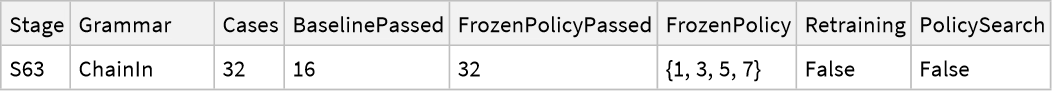

In [85]:
resultChain63=<|
"Stage"->"S63",
"Grammar"->"ChainIn",
"Cases"->Length[chain63],
"BaselinePassed"->Total[
Run62[#,{}]&/@chain63
],
"FrozenPolicyPassed"->Total[
Run62[#, best62]&/@chain63
],
"FrozenPolicy"->best62,
"Retraining"->False,
"PolicySearch"->False
|>;
Dataset[{resultChain63}]

In [87]:
chainByDepth63=Table[
Module[{idx, z},
idx=Flatten@Position[
spec63,
{x_,_,_} /; x===d
];
z=chain63[[idx]];
<|
"Depth"->d,
"Cases"->Length[z],
"BaselinePassed"->Total[
Run62[#,{}]&/@z
],
"FrozenPassed"->Total[
Run62[#, best62]&/@z
]
|>
],
{d,{2, 5, 9, 15}}
];
Dataset[chainByDepth63]

Dataset[{<|Depth -> 2, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>, 
 
>    <|Depth -> 5, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>, 
 
>    <|Depth -> 9, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>, 
 
>    <|Depth -> 15, Cases -> 8, BaselinePassed -> 4, FrozenPassed -> 8|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Cases, BaselinePassed, FrozenPassed}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 4], <||>]

In [89]:
merge63=
(Prep62[
Case63[
"SharedMerge",
#[[1]],
#[[2]],
#[[3]]
]
]&) /@spec63;
{
Length[merge63],
And@@ (Length[#]==2 &/@merge63)
}

{32, True}

Dataset[{<|Stage -> S63, Grammar -> SharedMerge, Cases -> 32, BaselinePassed -> 16, 
 
>     FrozenPolicyPassed -> 16, FrozenPolicy -> {1, 3, 5, 7}, Retraining -> False, 
 
>     PolicySearch -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Grammar, 
 
>      Cases, BaselinePassed, FrozenPolicyPassed, FrozenPolicy, Retraining, PolicySearch}
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
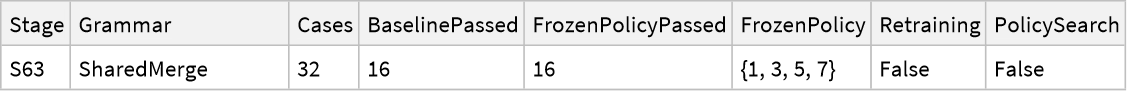

In [91]:
resultMerge63=<|
"Stage"->"S63",
"Grammar"->"SharedMerge",
"Cases"->Length[merge63],
"BaselinePassed"->Total[
Run62[#,{}]&/@merge63
],
"FrozenPolicyPassed"->Total[
Run62[#, best62]&/@merge63
],
"FrozenPolicy"->best62,
"Retraining"->False,
"PolicySearch"->False
|>;
Dataset[{resultMerge63}]

In [93]:
mergeDetail63=Flatten[
Table[
Module[{idx, z},
idx=Flatten@Position[
spec63,
{x_,_, y_ } /; x===d && y===t
];
z=merge63[[idx]];
<|
"Depth"->d,
"Target"->t,
"Cases"->Length[z],
"BaselinePassed"->Total[
Run62[#,{}]&/@z
],
"FrozenPassed"->Total[
Run62[#, best62]&/@z
]
|>
],
{d,{2, 5, 9, 15}},
{t,{"Continue", "Stop"}}
],
1
];
Dataset[mergeDetail63]

Dataset[{<|Depth -> 2, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 2, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>, 
 
>    <|Depth -> 5, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 5, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>, 
 
>    <|Depth -> 9, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 9, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>, 
 
>    <|Depth -> 15, Target -> Continue, Cases -> 4, BaselinePassed -> 4, 
 
>     FrozenPassed -> 4|>, <|Depth -> 15, Target -> Stop, Cases -> 4, 
 
>     BaselinePassed -> 0, FrozenPassed -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Target, Cases, BaselinePassed, 
 
>      FrozenPassed}, {TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 8]
 
>    , <||>]

Dataset[{<|Stage -> S63, FrozenPolicy -> {1, 3, 5, 7}, ChainInCases -> 32, 
 
>     ChainInBaseline -> 16, ChainInFrozen -> 32, SharedMergeCases -> 32, 
 
>     SharedMergeBaseline -> 16, SharedMergeFrozen -> 16, Retraining -> False, 
 
>     PolicySearch -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, 
 
>      FrozenPolicy, ChainInCases, ChainInBaseline, ChainInFrozen, SharedMergeCases, 
 
>      SharedMergeBaseline, SharedMergeFrozen, Retraining, PolicySearch}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
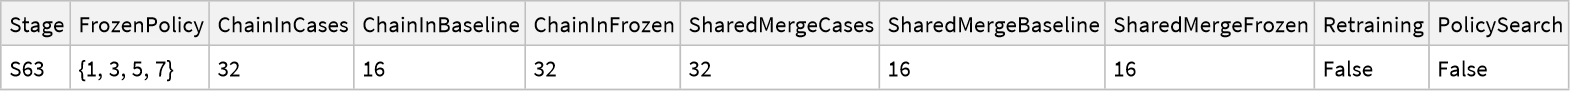

In [95]:
cert63=<|
"Stage"->"S63",
"FrozenPolicy"->best62,
"ChainInCases"->Length[chain63],
"ChainInBaseline"->Total[
Run62[#,{}]&/@chain63
],
"ChainInFrozen"->Total[
Run62[#, best62]&/@chain63
],
"SharedMergeCases"->Length[merge63],
"SharedMergeBaseline"->Total[
Run62[#,{}]&/@merge63
],
"SharedMergeFrozen"->Total[
Run62[#, best62]&/@merge63
],
"Retraining"->False,
"PolicySearch"->False
|>;
Dataset[{cert63}]

In [97]:
ClearAll[RawPair64];
RawPair64[d_Integer, a_Integer]:=Module[
{cs, ss},
cs=DecisionStates64[
Case63["SharedMerge", d, a, "Continue"],
2
];
ss=DecisionStates64[
Case63["SharedMerge", d, a, "Stop"],
2
];
<|
"Depth"->d,
"Answer"->a,
"ContinueStates"->cs,
"StopStates"->ss,
"Same"->SameQ[
Sort[cs],
Sort[ss]
]
|>
];

<|Depth -> 2, Answer -> 1, ContinueStates -> 
 
>    {{{{4, 1}, {{0, 1}, {0, 4}, {1, 1}, {1, 1}}, {{1, 0}}}, 
 
>      {{{0, 1}, {}, {{4, 1}}}, {{0, 4}, {}, {{4, 1}, {4, 1}, {4, 1}, {4, 1}}}, 
 
>       {{1, 1}, {{1, 1}}, {{4, 1}}}, {{1, 1}, {{3, 1}}, {{4, 1}}}}, 
 
>      {{{1, 0}, {{4, 1}}, {}}}}}, StopStates -> 
 
>    {{{{4, 1}, {{0, 4}, {1, 1}, {1, 1}, {1, 1}}, {{1, 0}}}, 
 
>      {{{0, 4}, {}, {{4, 1}, {4, 1}, {4, 1}, {4, 1}}}, {{1, 1}, {{1, 1}}, {{4, 1}}}, 
 
>       {{1, 1}, {{1, 1}}, {{4, 1}}}, {{1, 1}, {{3, 1}}, {{4, 1}}}}, 
 
>      {{{1, 0}, {{4, 1}}, {}}}}, {{{4, 1}, {{0, 4}, {1, 1}, {1, 1}, {1, 1}}, {{1, 0}}}, 
 
>      {{{0, 4}, {}, {{4, 1}, {4, 1}, {4, 1}, {4, 1}}}, {{1, 1}, {{1, 1}}, {{4, 1}}}, 
 
>       {{1, 1}, {{2, 1}}, {{4, 1}}}, {{1, 1}, {{3, 1}}, {{4, 1}}}}, 
 
>      {{{1, 0}, {{4, 1}}, {}}}}}, Same -> False|>
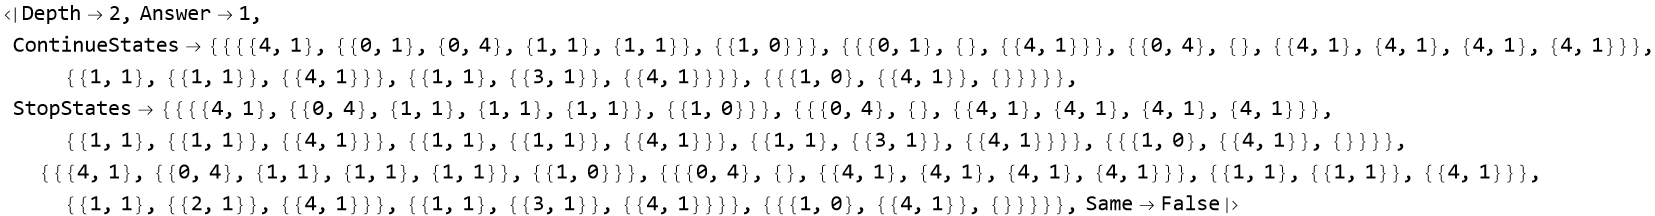

In [99]:
RawPair64[2, 1]

In [100]:
pairs64=Flatten[
Table[
RawPair64[d, a],
{d,{2, 5, 9, 15}},
{a, 1, 4}
],
1
];
{
Length[pairs64],
Count[Lookup[pairs64, "Same"], True],
Count[Lookup[pairs64, "Same"], False]
}

{16, 0, 16}

In [102]:
cStates64=Join@@Lookup[
pairs64,
"ContinueStates"
];
sStates64=Join@@Lookup[
pairs64,
"StopStates"
];
states64=DeleteDuplicates[
Join[
cStates64,
sStates64
]
];
{
Length[cStates64],
Length[sStates64],
Length[states64]
}

{16, 32, 8}

Dataset[{<|StateID -> 1, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 2, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 3, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 4, ContinueCases -> 4, StopCases -> 0, Conflict -> False|>, 
 
>    <|StateID -> 5, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>, 
 
>    <|StateID -> 6, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>, 
 
>    <|StateID -> 7, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>, 
 
>    <|StateID -> 8, ContinueCases -> 0, StopCases -> 8, Conflict -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{StateID, ContinueCases, StopCases, Conflict}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 8], <||>]
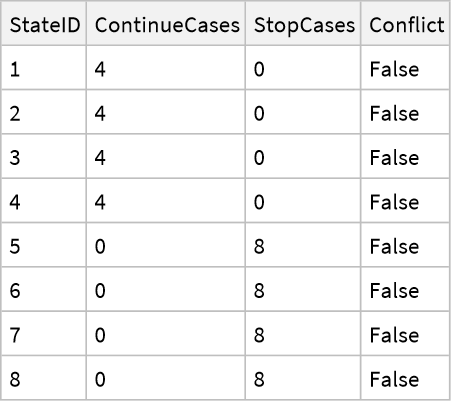

In [106]:
auditStates64=Table[
Module[{cc, ss},
cc=Count[
pairs64,
x_ /; MemberQ[
x["ContinueStates"],
st
]
];
ss=Count[
pairs64,
x_ /; MemberQ[
x["StopStates"],
st
]
];
<|
"StateID"->i,
"ContinueCases"->cc,
"StopCases"->ss,
"Conflict"->TrueQ[
cc>0 && ss>0
]
|>
],
{i, Length[states64]},
{st,{states64[[i]]}}
];
auditStates64=Flatten[
auditStates64
];
Dataset[auditStates64]

In [109]:
cert64=<|
"Stage"->"S64",
"Grammar"->"SharedMerge",
"Radius"->2,
"Pairs"->Length[pairs64],
"PairDifferent"->Count[
Lookup[pairs64, "Same"],
False
],
"PairSame"->Count[
Lookup[pairs64, "Same"],
True
],
"StateTypes"->Length[states64],
"ConflictingStates"->Count[
Lookup[auditStates64, "Conflict"],
True
],
"PureContinueStates"->Count[
auditStates64,
x_ /;
x["ContinueCases"]>0 &&
x["StopCases"]==0
],
"PureStopStates"->Count[
auditStates64,
x_ /;
x["StopCases"] >0 &&
x["ContinueCases"] ==0
]
|>;
Dataset[{cert64}]

Dataset[{<|Stage -> S64, Grammar -> SharedMerge, Radius -> 2, Pairs -> 16, 
 
>     PairDifferent -> 16, PairSame -> 0, StateTypes -> 8, ConflictingStates -> 0, 
 
>     PureContinueStates -> 4, PureStopStates -> 4|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Grammar, Radius, Pairs, PairDifferent, 
 
>      PairSame, StateTypes, ConflictingStates, PureContinueStates, PureStopStates}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 1], <||>]

In [111]:
ClearAll[Rows69];
Rows69[g_String , ds_List]:=Flatten[
Table[
Module[{c},
c=If[
g==="S59",
Case59[d, a, t],
Case63[g, d, a, t]
];
<|
"Grammar"->g,
"Depth"->d,
"Answer"->a,
"Target"->t,
"States"->DecisionStates64[c, 2]
|>
],
{d, ds},
{a, 1, 4},
{t,{"Continue", "Stop"}}
],
2
];

In [113]:
rtest69=Rows69["S59",{2}];
{
Length[rtest69],
AssociationQ[First[rtest69]],
Keys[First[rtest69]]
}

{8, True, {Grammar, Depth, Answer, Target, States}}

In [115]:
trainS5969=Rows69[
"S59",
{2, 5}
];
trainChain69=Rows69[
"ChainIn",
{2, 5}
];
train69=Join[
trainS5969,
trainChain69
];
heldS5969=Rows69[
"S59",
{9, 15}
];
heldChain69=Rows69[
"ChainIn",
{9, 15}
];
merge69=Rows69[
"SharedMerge",
{2, 5, 9, 15}
];
{
Length[trainS5969],
Length[trainChain69],
Length[train69],
Length[heldS5969],
Length[heldChain69],
Length[merge69]
}

{16, 16, 32, 16, 16, 32}

In [122]:
ClearAll[EncodeRows69];
EncodeRows69[
data_List,
p_List ,
k_Integer
]:=Module[{rec},
rec[s_]:=rec[s] =If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[
s[[1]]+2 s[[2]],
k
],
Module[{z, ps, cs},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
1+Mod[
p[[1]]+
p[[2]](z-1) +
p[[3]] * Total[ps-1] +
p[[4]] * Total[cs-1] +
p[[5]] * Total[(ps-1)^ 2] +
p[[6]] * Total[(cs-1)^ 2],
k
]
]
];
Map[
Function[row,
<|
"Grammar"->row["Grammar"],
"Depth"->row["Depth"],
"Answer"->row["Answer"],
"Target"->row["Target"],
"Codes"->DeleteDuplicates[
rec/@row["States"]
]
|>
],
data
]
];

In [124]:
e69=EncodeRows69[
train69,
{0, 0,-1,-1,-1, 0},
5
];
{
Length[e69],
And@@(
ListQ[#]&/@Lookup[e69, "Codes"]
),
Min[
Flatten[Lookup[e69, "Codes"]]
],
Max[
Flatten[Lookup[e69, "Codes"]]
]
}

{32, True, 1, 4}

In [126]:
ClearAll[BestStatic69];
BestStatic69[
p_List ,
k_Integer
]:=Module[
{rows, truth, pols, scores, pred, mx, bp},
rows=EncodeRows69[
train69,
p,
k
];
truth=
Boole[# ==="Continue"]&/@
Lookup[rows, "Target"];
pols=Subsets[
Range[k]
];
scores=Table[
pred=Map[
Function[row,
Boole[
AnyTrue[
row["Codes"],
Function[z,
MemberQ[pol, z]
]
]
]
],
rows
];
Total[
MapThread[
Function[{a, b},
Boole[SameQ[a, b]]
],
{pred, truth}
]
],
{pol, pols}
];
mx=Max[scores];
bp=First@SortBy[
Pick[
pols,
scores,
mx
],
Length
];
<|
"K"->k,
"Params"->p,
"BestPassed"->mx,
"Policy"->bp
|>
];

In [128]:
q69=BestStatic69[
{0, 0,-1,-1,-1, 0},
5
];
q69

<|K -> 5, Params -> {0, 0, -1, -1, -1, 0}, BestPassed -> 32, Policy -> {1, 3}|>

In [130]:
pars69=Tuples[
{-1, 0, 1},
6
];
chunks69=Partition[
pars69,
UpTo[81]
];
{
Length[pars69],
Length[chunks69],
Length/@chunks69
}

{729, 9, {81, 81, 81, 81, 81, 81, 81, 81, 81}}

KeyDrop::invrl: The argument SearchChunk69[{{-1, -1, -1, -1, -1, -1}, {-1, -1, -1, -1, -1, 0}, {-1, -1, -1, -1, -1, 1}, {-1, -1, -1, -1, 0, -1}, {-1, -1, -1, -1, 0, 0}, {-1, -1, -1, -1, 0, 1}, {-1, -1, -1, -1, 1, -1}, {-1, -1, -1, -1, 1, 0}, {-1, -1, -1, -1, 1, 1}, {-1, -1, -1, 0, -1, -1}, {-1, -1, -1, 0, -1, 0}, {-1, -1, -1, 0, -1, 1}, {-1, -1, -1, 0, 0, -1}, {-1, -1, -1, 0, 0, 0}, {-1, -1, -1, 0, 0, 1}, {-1, -1, -1, 0, 1, -1}, {-1, -1, -1, 0, 1, 0}, {-1, -1, -1, 0, 1, 1}, {-1, -1, -1, 1, -1, -1}, {-1, -1, -1, 1, -1, 0}, {-1, -1, -1, 1, -1, 1}, {-1, -1, -1, 1, 0, -1}, {-1, -1, -1, 1, 0, 0}, {-1, -1, -1, 1, 0, 1}, {-1, -1, -1, 1, 1, -1}, {-1, -1, -1, 1, 1, 0}, {-1, -1, -1, 1, 1, 1}, {-1, -1, 0, -1, -1, -1}, {-1, -1, 0, -1, -1, 0}, {-1, -1, 0, -1, -1, 1}, {-1, -1, 0, -1, 0, -1}, {-1, -1, 0, -1, 0, 0}, {-1, -1, 0, -1, 0, 1}, {-1, -1, 0, -1, 1, -1}, {-1, -1, 0, -1, 1, 0}, {-1, -1, 0, -1, 1, 1}, {-1, -1, 0, 0, -1, -1}, {-1, -1, 0, 0, -1, 0}, {-1, -1, 0, 0, -1, 1}, {-1, -1, 0, 0, 0, -1}, {-1, -1, 0, 0, 0, 0}, {-1, -1, 0, 0, 0, 1}, {-1, -1, 0, 0, 1, -1}, {-1, -1, 0, 0, 1, 0}, {-1, -1, 0, 0, 1, 1}, {-1, -1, 0, 1, -1, -1}, {-1, -1, 0, 1, -1, 0}, {-1, -1, 0, 1, -1, 1}, {-1, -1, 0, 1, 0, -1}, {-1, -1, 0, 1, 0, 0}, {-1, -1, 0, 1, 0, 1}, {-1, -1, 0, 1, 1, -1}, {-1, -1, 0, 1, 1, 0}, {-1, -1, 0, 1, 1, 1}, {-1, -1, 1, -1, -1, -1}, {-1, -1, 1, -1, -1, 0}, {-1, -1, 1, -1, -1, 1}, {-1, -1, 1, -1, 0, -1}, {-1, -1, 1, -1, 0, 0}, {-1, -1, 1, -1, 0, 1}, {-1, -1, 1, -1, 1, -1}, {-1, -1, 1, -1, 1, 0}, {-1, -1, 1, -1, 1, 1}, {-1, -1, 1, 0, -1, -1}, {-1, -1, 1, 0, -1, 0}, {-1, -1, 1, 0, -1, 1}, {-1, -1, 1, 0, 0, -1}, {-1, -1, 1, 0, 0, 0}, {-1, -1, 1, 0, 0, 1}, {-1, -1, 1, 0, 1, -1}, {-1, -1, 1, 0, 1, 0}, {-1, -1, 1, 0, 1, 1}, {-1, -1, 1, 1, -1, -1}, {-1, -1, 1, 1, -1, 0}, {-1, -1, 1, 1, -1, 1}, {-1, -1, 1, 1, 0, -1}, {-1, -1, 1, 1, 0, 0}, {-1, -1, 1, 1, 0, 1}, {-1, -1, 1, 1, 1, -1}, {-1, -1, 1, 1, 1, 0}, {-1, -1, 1, 1, 1, 1}}, 5] is not a valid Association or a list of rules.

KeyDrop[SearchChunk69[{{-1, -1, -1, -1, -1, -1}, {-1, -1, -1, -1, -1, 0}, 
 
>     {-1, -1, -1, -1, -1, 1}, {-1, -1, -1, -1, 0, -1}, {-1, -1, -1, -1, 0, 0}, 
 
>     {-1, -1, -1, -1, 0, 1}, {-1, -1, -1, -1, 1, -1}, {-1, -1, -1, -1, 1, 0}, 
 
>     {-1, -1, -1, -1, 1, 1}, {-1, -1, -1, 0, -1, -1}, {-1, -1, -1, 0, -1, 0}, 
 
>     {-1, -1, -1, 0, -1, 1}, {-1, -1, -1, 0, 0, -1}, {-1, -1, -1, 0, 0, 0}, 
 
>     {-1, -1, -1, 0, 0, 1}, {-1, -1, -1, 0, 1, -1}, {-1, -1, -1, 0, 1, 0}, 
 
>     {-1, -1, -1, 0, 1, 1}, {-1, -1, -1, 1, -1, -1}, {-1, -1, -1, 1, -1, 0}, 
 
>     {-1, -1, -1, 1, -1, 1}, {-1, -1, -1, 1, 0, -1}, {-1, -1, -1, 1, 0, 0}, 
 
>     {-1, -1, -1, 1, 0, 1}, {-1, -1, -1, 1, 1, -1}, {-1, -1, -1, 1, 1, 0}, 
 
>     {-1, -1, -1, 1, 1, 1}, {-1, -1, 0, -1, -1, -1}, {-1, -1, 0, -1, -1, 0}, 
 
>     {-1, -1, 0, -1, -1, 1}, {-1, -1, 0, -1, 0, -1}, {-1, -1, 0, -1, 0, 0}, 
 
>     {-1, -1, 0, -1, 0, 1}, {-1, -1, 0, -1, 1, -1}, {-1, -1, 0, -1, 1, 0}, 
 
>     {-1, -1, 0, -1, 1, 1}, {-1, -1, 0, 0, -1, -1}, {-1, -1, 0, 0, -1, 0}, 
 
>     {-1, -1, 0, 0, -1, 1}, {-1, -1, 0, 0, 0, -1}, {-1, -1, 0, 0, 0, 0}, 
 
>     {-1, -1, 0, 0, 0, 1}, {-1, -1, 0, 0, 1, -1}, {-1, -1, 0, 0, 1, 0}, 
 
>     {-1, -1, 0, 0, 1, 1}, {-1, -1, 0, 1, -1, -1}, {-1, -1, 0, 1, -1, 0}, 
 
>     {-1, -1, 0, 1, -1, 1}, {-1, -1, 0, 1, 0, -1}, {-1, -1, 0, 1, 0, 0}, 
 
>     {-1, -1, 0, 1, 0, 1}, {-1, -1, 0, 1, 1, -1}, {-1, -1, 0, 1, 1, 0}, 
 
>     {-1, -1, 0, 1, 1, 1}, {-1, -1, 1, -1, -1, -1}, {-1, -1, 1, -1, -1, 0}, 
 
>     {-1, -1, 1, -1, -1, 1}, {-1, -1, 1, -1, 0, -1}, {-1, -1, 1, -1, 0, 0}, 
 
>     {-1, -1, 1, -1, 0, 1}, {-1, -1, 1, -1, 1, -1}, {-1, -1, 1, -1, 1, 0}, 
 
>     {-1, -1, 1, -1, 1, 1}, {-1, -1, 1, 0, -1, -1}, {-1, -1, 1, 0, -1, 0}, 
 
>     {-1, -1, 1, 0, -1, 1}, {-1, -1, 1, 0, 0, -1}, {-1, -1, 1, 0, 0, 0}, 
 
>     {-1, -1, 1, 0, 0, 1}, {-1, -1, 1, 0, 1, -1}, {-1, -1, 1, 0, 1, 0}, 
 
>     {-1, -1, 1, 0, 1, 1}, {-1, -1, 1, 1, -1, -1}, {-1, -1, 1, 1, -1, 0}, 
 
>     {-1, -1, 1, 1, -1, 1}, {-1, -1, 1, 1, 0, -1}, {-1, -1, 1, 1, 0, 0}, 
 
>     {-1, -1, 1, 1, 0, 1}, {-1, -1, 1, 1, 1, -1}, {-1, -1, 1, 1, 1, 0}, 
 
>     {-1, -1, 1, 1, 1, 1}}, 5], Results]
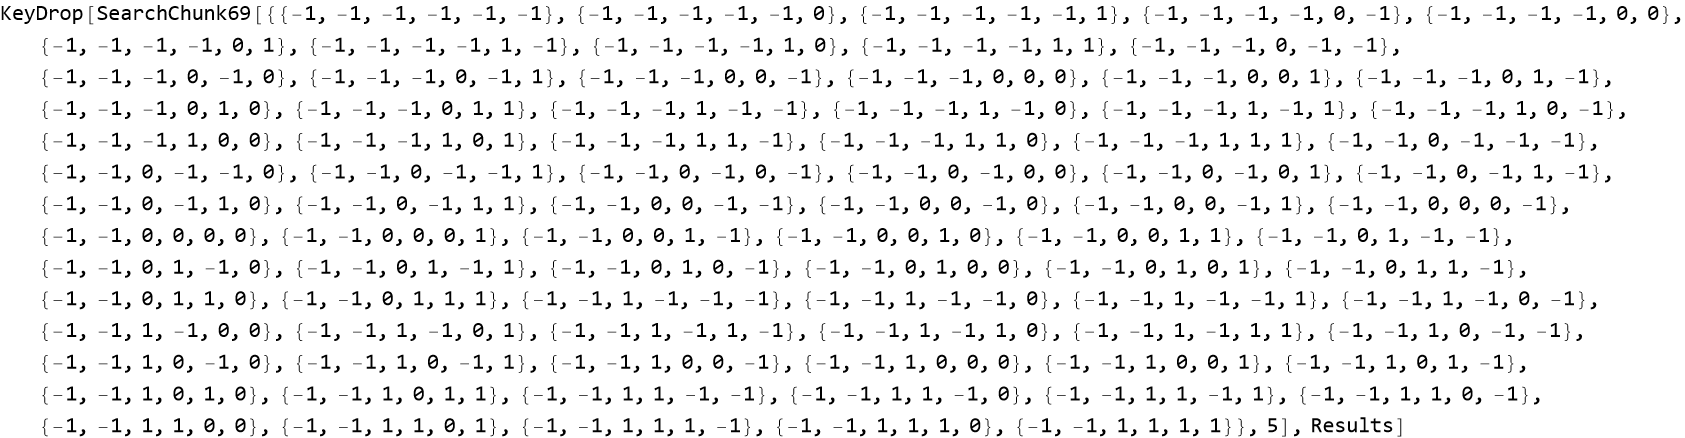

In [133]:
r69A=SearchChunk69[
chunks69[[1]],
5
];
KeyDrop[
r69A,
"Results"
]

In [135]:
{
Length[DownValues[SearchChunk69]],
Head[r69A]
}

{0, SearchChunk69}

In [136]:
ClearAll[SearchChunk69];
SearchChunk69[pp_List , k_Integer]:=Module[
{r, best, perfect},
r=Map[
Function[p,
BestStatic69[p, k]
],
pp
];
best=Max[
Lookup[r, "BestPassed"]
];
perfect=Count[
r,
x_ /; x["BestPassed"]==32
];
<|
"Encoders"->Length[r],
"BestPassed"->best,
"Perfect"->perfect,
"Results"->r
|>
];

In [138]:
testChunk69=SearchChunk69[
Take[pars69, 2],
5
];
{
AssociationQ[testChunk69],
testChunk69["Encoders"],
IntegerQ[testChunk69["BestPassed"]],
IntegerQ[testChunk69["Perfect"]],
Length[testChunk69["Results"]]
}

{True, 2, True, True, 2}

In [140]:
Length[DownValues[SearchChunk69]]

1

In [141]:
r69A=SearchChunk69[
chunks69[[1]],
5
];

In [142]:
{
AssociationQ[r69A],
r69A["Encoders"],
r69A["BestPassed"],
r69A["Perfect"]
}

{True, 81, 32, 16}

In [143]:
KeyDrop[r69A, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 16|>

In [144]:
r69B=SearchChunk69[chunks69[[2]], 5];
KeyDrop[r69B,"Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 12|>

In [146]:
r69C=SearchChunk69[chunks69[[3]], 5];
KeyDrop[r69C, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 9|>

In [148]:
r69D=SearchChunk69[chunks69[[4]], 5];
KeyDrop[r69D, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 11|>

In [150]:
r69E=SearchChunk69[chunks69[[5]], 5];
KeyDrop[r69E, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 13|>

In [152]:
r69F=SearchChunk69[chunks69[[6]], 5];
KeyDrop[r69F, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 9|>

In [154]:
r69G=SearchChunk69[chunks69[[7]], 5];
KeyDrop[r69G, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 12|>

In [156]:
r69H=SearchChunk69[chunks69[[8]], 5];
KeyDrop[r69H, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 14|>

In [158]:
r69I=SearchChunk69[chunks69[[9]], 5];
KeyDrop[r69I, "Results"]

<|Encoders -> 81, BestPassed -> 32, Perfect -> 12|>

In [160]:
{
r69A["Encoders"],
r69A["BestPassed"],
r69A["Perfect"]
}

{81, 32, 16}

In [161]:
blocks69= {
r69A, r69B, r69C,
r69D, r69E, r69F,
r69G, r69H, r69I
};
all69=Join@@Lookup[
blocks69,
"Results"
];
bestScore69=Max[
Lookup[
all69,
"BestPassed"
]
];
perfect69=Select[
all69,
#["BestPassed"]==32 &
];
cert69A=<|
"Stage"->"S69A",
"EncodersTested"->Length[all69],
"BestPassed"->bestScore69,
"PerfectEncoders"->Length[perfect69],
"ScoreDistribution"->Counts[
Lookup[
all69,
"BestPassed"
]
]
|>;
Dataset[{cert69A}]

Dataset[{<|Stage -> S69A, EncodersTested -> 729, BestPassed -> 32, 
 
>     PerfectEncoders -> 108, ScoreDistribution -> 
 
>      <|28 -> 82, 32 -> 108, 26 -> 160, 16 -> 362, 30 -> 17|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, EncodersTested, BestPassed, 
 
>      PerfectEncoders, ScoreDistribution}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 5]}], 1], <||>]

In [167]:
ClearAll[StaticScore69];
StaticScore69[
m_Association ,
data_List
]:=Module[
{rows, truth, pred},
rows=EncodeRows69[
data,
m["Params"],
m["K"]
];
truth=
Boole[# ==="Continue"]&/@
Lookup[rows, "Target"];
pred=Map[
Function[row,
Boole[
AnyTrue[
row["Codes"],
Function[z,
MemberQ[m["Policy"], z]
]
]
]
],
rows
];
Total[
MapThread[
Function[{a, b},
Boole[SameQ[a, b]]
],
{pred, truth}
]
]
];

In [169]:
{
StaticScore69[q69, train69],
StaticScore69[q69, heldS5969],
StaticScore69[q69, heldChain69],
StaticScore69[q69, merge69]
}

{32, 16, 16, 24}

In [170]:
perfectChunks69C=Partition[
perfect69,
UpTo[18]
];
Length/@perfectChunks69C

{18, 18, 18, 18, 18, 18}

In [172]:
s69C1=StaticScore69[#, merge69]&/@perfectChunks69C[[1]];
{
Length[s69C1],
Min[s69C1],
Max[s69C1]
}

{18, 4, 32}

In [174]:
s69C2=StaticScore69[#, merge69]&/@perfectChunks69C[[2]];
{
Length[s69C2],
Min[s69C2],
Max[s69C2]
}

{18, 0, 28}

In [176]:
s69C3=StaticScore69[#, merge69]&/@perfectChunks69C[[3]];
{
Length[s69C3],
Min[s69C3],
Max[s69C3]
}

{18, 4, 32}

In [178]:
s69C4=StaticScore69[#, merge69]&/@perfectChunks69C[[4]];
{
Length[s69C4],
Min[s69C4],
Max[s69C4]
}

{18, 4, 24}

In [180]:
s69C5=StaticScore69[#, merge69]&/@perfectChunks69C[[5]];
{
Length[s69C5],
Min[s69C5],
Max[s69C5]
}

{18, 0, 24}

In [182]:
s69C6=StaticScore69[#, merge69]&/@perfectChunks69C[[6]];
{
Length[s69C6],
Min[s69C6],
Max[s69C6]
}

{18, 4, 32}

In [184]:
scores69C=Join[
s69C1, s69C2, s69C3,
s69C4, s69C5, s69C6
];
cert69C=<|
"Stage"->"S69C",
"TrainingPerfectEncoders"->Length[perfect69],
"SharedMergeBest"->Max[scores69C],
"SharedMergeWorst"->Min[scores69C],
"SharedMergeMean"->N[Mean[scores69C]],
"SharedMergeDistribution"->Counts[scores69C],
"PerfectTransferEncoders"->Count[
scores69C,
32
],
"AboveChanceEncoders"->Count[
scores69C,
x_ /; x>16
],
"AtChanceEncoders"->Count[
scores69C,
16
]
|>;
Dataset[{cert69C}]

Dataset[{<|Stage -> S69C, TrainingPerfectEncoders -> 108, SharedMergeBest -> 32, 
 
>     SharedMergeWorst -> 0, SharedMergeMean -> 15.1111, 
 
>     SharedMergeDistribution -> 
 
>      <|32 -> 5, 4 -> 11, 8 -> 9, 12 -> 31, 24 -> 17, 16 -> 27, 20 -> 3, 28 -> 3, 
 
>       0 -> 2|>, PerfectTransferEncoders -> 5, AboveChanceEncoders -> 28, 
 
>     AtChanceEncoders -> 27|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, 
 
>      TrainingPerfectEncoders, SharedMergeBest, SharedMergeWorst, SharedMergeMean, 
 
>      SharedMergeDistribution, PerfectTransferEncoders, AboveChanceEncoders, 
 
>      AtChanceEncoders}, {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 9], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 1]
 
>    , <||>]

In [187]:
idxPerfectTransfer69=Flatten@
Position[scores69C, 32];
transferPerfect69=
perfect69[[idxPerfectTransfer69]];
{
Length[transferPerfect69],
Lookup[transferPerfect69, "Params"],
Lookup[transferPerfect69, "Policy"]
}

{5, {{-1, -1, -1, -1, -1, 0}, {0, -1, 1, -1, -1, 0}, {0, -1, 1, 0, -1, -1}, 
 
>    {1, 1, 1, -1, 1, 1}, {1, 1, 1, 1, 1, -1}}, {{1, 4}, {1, 4}, {2, 4}, {2, 5}, {1, 3}}}

In [190]:
Dataset[
MapIndexed[
Function[{m, idx},
<|
"ID"->First[idx],
"Params"->m["Params"],
"Policy"->m["Policy"],
"TrainPassed"->m["BestPassed"],
"SharedMergePassed"->32
|>
],
transferPerfect69
]
]

Dataset[{<|ID -> 1, Params -> {-1, -1, -1, -1, -1, 0}, Policy -> {1, 4}, 
 
>     TrainPassed -> 32, SharedMergePassed -> 32|>, 
 
>    <|ID -> 2, Params -> {0, -1, 1, -1, -1, 0}, Policy -> {1, 4}, TrainPassed -> 32, 
 
>     SharedMergePassed -> 32|>, <|ID -> 3, Params -> {0, -1, 1, 0, -1, -1}, 
 
>     Policy -> {2, 4}, TrainPassed -> 32, SharedMergePassed -> 32|>, 
 
>    <|ID -> 4, Params -> {1, 1, 1, -1, 1, 1}, Policy -> {2, 5}, TrainPassed -> 32, 
 
>     SharedMergePassed -> 32|>, <|ID -> 5, Params -> {1, 1, 1, 1, 1, -1}, 
 
>     Policy -> {1, 3}, TrainPassed -> 32, SharedMergePassed -> 32|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{ID, Params, Policy, TrainPassed, 
 
>      SharedMergePassed}, {TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 5], <||>]

In [191]:
paramsTP69=Lookup[
transferPerfect69,
"Params"
];
Table[
<|
"Position"->j,
"Values"->paramsTP69[[All, j]],
"Counts"->Counts[
paramsTP69[[All, j]]
]
|>,
{j, 6}
]//Dataset

Dataset[{<|Position -> 1, Values -> {-1, 0, 0, 1, 1}, 
 
>     Counts -> <|-1 -> 1, 0 -> 2, 1 -> 2|>|>, 
 
>    <|Position -> 2, Values -> {-1, -1, -1, 1, 1}, Counts -> <|-1 -> 3, 1 -> 2|>|>, 
 
>    <|Position -> 3, Values -> {-1, 1, 1, 1, 1}, Counts -> <|-1 -> 1, 1 -> 4|>|>, 
 
>    <|Position -> 4, Values -> {-1, -1, 0, -1, 1}, 
 
>     Counts -> <|-1 -> 3, 0 -> 1, 1 -> 1|>|>, 
 
>    <|Position -> 5, Values -> {-1, -1, -1, 1, 1}, Counts -> <|-1 -> 3, 1 -> 2|>|>, 
 
>    <|Position -> 6, Values -> {0, 0, -1, 1, -1}, 
 
>     Counts -> <|0 -> 2, -1 -> 2, 1 -> 1|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Position, Values, Counts}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 5], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>       TypeSystem`AnyLength]}], 6], <||>]

In [193]:
Counts[
Lookup[
transferPerfect69,
"Policy"
]
]

<|{1, 4} -> 2, {2, 4} -> 1, {2, 5} -> 1, {1, 3} -> 1|>

In [194]:
ClearAll[Jaccard70];
Jaccard70[a_List, b_List]:=Module[
{u},
u=Union[a, b];
If[
Length[u]==0,
1.,
N[
Length[Intersection[a, b]] /
Length[u]
]
]
];

In [196]:
{
Jaccard70[{1, 2},{1, 2}],
Jaccard70[{1},{2}],
Jaccard70[{1, 2},{2, 3}]
}

{1., 0., 0.333333}

In [197]:
ClearAll[Consistency70];
Consistency70[m_Association]:=Module[
{s59, ch, pairs, exact, jac, selExact, selJac, pol},
s59=EncodeRows69[
trainS5969,
m["Params"],
m["K"]
];
ch=EncodeRows69[
trainChain69,
m["Params"],
m["K"]
];
pol=m["Policy"];
pairs=MapThread[
Function[{x, y},
<|
"Exact"->SameQ[
Sort[x["Codes"]],
Sort[y["Codes"]]
],
"Jaccard"->Jaccard70[
x["Codes"],
y["Codes"]
],
"SelectedExact"->SameQ[
Sort[Intersection[x["Codes"], pol]],
Sort[Intersection[y["Codes"], pol]]
],
"SelectedJaccard"->Jaccard70[
Intersection[x["Codes"], pol],
Intersection[y["Codes"], pol]
]
|>
],
{s59, ch}
];
<|
"ExactPairs"->Count[
Lookup[pairs, "Exact"],
True
],
"MeanJaccard"->Mean[
Lookup[pairs, "Jaccard"]
],
"SelectedExactPairs"->Count[
Lookup[pairs, "SelectedExact"],
True
],
"SelectedMeanJaccard"->Mean[
Lookup[pairs, "SelectedJaccard"]
]
|>
];

In [199]:
test70=Consistency70[
First[perfect69]
];
test70

<|ExactPairs -> 8, MeanJaccard -> 0.5, SelectedExactPairs -> 12, 
 
>   SelectedMeanJaccard -> 0.75|>

In [201]:
cons70=Consistency70/@perfect69;
Length[cons70]

108

In [203]:
rows70=MapThread[
Function[{m, c, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"ExactPairs"->c["ExactPairs"],
"MeanJaccard"->c["MeanJaccard"],
"SelectedExactPairs"->
c["SelectedExactPairs"],
"SelectedMeanJaccard"->
c["SelectedMeanJaccard"],
"SharedMergeScore"->s,
"TransferPerfect"->Boole[
s==32
]
|>
],
{perfect69, cons70, scores69C}
];
Length[rows70]

108

In [205]:
corr70=<|
"ExactCorrelation"->
Correlation[
N[Lookup[rows70, "ExactPairs"]],
N[Lookup[rows70, "SharedMergeScore"]]
],
"JaccardCorrelation"->
Correlation[
N[Lookup[rows70, "MeanJaccard"]],
N[Lookup[rows70, "SharedMergeScore"]]
],
"SelectedExactCorrelation"->
Correlation[
N[Lookup[rows70, "SelectedExactPairs"]],
N[Lookup[rows70, "SharedMergeScore"]]
],
"SelectedJaccardCorrelation"->
Correlation[
N[Lookup[rows70, "SelectedMeanJaccard"]],
N[Lookup[rows70, "SharedMergeScore"]]
]
|>;
corr70

<|ExactCorrelation -> -0.0492993, JaccardCorrelation -> -0.0492993, 
 
>   SelectedExactCorrelation -> -0.0492993, SelectedJaccardCorrelation -> -0.0492993|>

In [207]:
good70=Select[
rows70,
#["TransferPerfect"]==1 &
];
bad70=Select[
rows70,
#["TransferPerfect"]==0 &
];
summary70=<|
"PerfectTransferCount"->
Length[good70],
"OtherCount"->
Length[bad70],
"PerfectMeanExact"->
N@Mean[
Lookup[good70, "ExactPairs"]
],
"OtherMeanExact"->
N@Mean[
Lookup[bad70, "ExactPairs"]
],
"PerfectMeanJaccard"->
N@Mean[
Lookup[good70, "MeanJaccard"]
],
"OtherMeanJaccard"->
N@Mean[
Lookup[bad70, "MeanJaccard"]
],
"PerfectSelectedExact"->
N@Mean[
Lookup[good70, "SelectedExactPairs"]
],
"OtherSelectedExact"->
N@Mean[
Lookup[bad70, "SelectedExactPairs"]
],
"PerfectSelectedJaccard"->
N@Mean[
Lookup[good70, "SelectedMeanJaccard"]
],
"OtherSelectedJaccard"->
N@Mean[
Lookup[bad70, "SelectedMeanJaccard"]
]
|>;
Dataset[{summary70}]

Dataset[{<|PerfectTransferCount -> 5, OtherCount -> 103, PerfectMeanExact -> 8., 
 
>     OtherMeanExact -> 10.4078, PerfectMeanJaccard -> 0.5, 
 
>     OtherMeanJaccard -> 0.650485, PerfectSelectedExact -> 12., 
 
>     OtherSelectedExact -> 13.2039, PerfectSelectedJaccard -> 0.75, 
 
>     OtherSelectedJaccard -> 0.825243|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{PerfectTransferCount, OtherCount, 
 
>      PerfectMeanExact, OtherMeanExact, PerfectMeanJaccard, OtherMeanJaccard, 
 
>      PerfectSelectedExact, OtherSelectedExact, PerfectSelectedJaccard, 
 
>      OtherSelectedJaccard}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real]}], 1], <||>]

In [211]:
rank70=Reverse@SortBy[
Range[Length[perfect69]],
Function[i,
{
cons70[[i, "SelectedMeanJaccard"]],
cons70[[i, "MeanJaccard"]],
cons70[[i, "SelectedExactPairs"]],
cons70[[i, "ExactPairs"]]
}
]
];
topIdx70=First[rank70];
selected70=perfect69[[topIdx70]];
<|
"Index"->topIdx70,
"Params"->selected70["Params"],
"Policy"->selected70["Policy"],
"Consistency"->cons70[[topIdx70]]
|>

<|Index -> 96, Params -> {1, 0, 1, 1, 1, 1}, Policy -> {5}, 
 
>   Consistency -> 
 
>    <|ExactPairs -> 16, MeanJaccard -> 1., SelectedExactPairs -> 16, 
 
>     SelectedMeanJaccard -> 1.|>|>

In [215]:
<|
"SelectedIndex"->topIdx70,
"SharedMergeScore"->
scores69C[[topIdx70]],
"WasPerfectTransfer"->
TrueQ[
scores69C[[topIdx70]] ==32
]
|>

<|SelectedIndex -> 96, SharedMergeScore -> 24, WasPerfectTransfer -> False|>

In [216]:
ClearAll[AllowedPerms70B];
AllowedPerms70B[
pol_List ,
k_Integer
]:=Select[
Permutations[Range[k]],
Function[pm,
And@@Table[
SameQ[
MemberQ[pol, z],
MemberQ[pol, pm[[z]]]
],
{z, k}
]
]
];

In [218]:
{
Length[AllowedPerms70B[{1, 3}, 5]],
Length[AllowedPerms70B[{5}, 5]]
}

{12, 24}

In [219]:
ClearAll[ApplyPerm70B];
ApplyPerm70B[
codes_List,
pm_List
]:=Sort[
pm[[#]]&/@codes
];

In [221]:
ApplyPerm70B[
{1, 3, 5},
{3, 2, 1, 5, 4}
]

{1, 3, 4}

In [222]:
ClearAll[AlignConsistency70B];
AlignConsistency70B[
m_Association
]:=Module[
{s59, ch, pol, k, perms, res, best,
pm, a, b, sa, sb, ex, jac, sex, sjac},
s59=EncodeRows69[
trainS5969,
m["Params"],
m["K"]
];
ch=EncodeRows69[
trainChain69,
m["Params"],
m["K"]
];
pol=m["Policy"];
k=m["K"];
perms=AllowedPerms70B[
pol,
k
];
res=Table[
ex=0;
jac=0.;
sex=0;
sjac=0.;
Do[
a=Sort[
Lookup[
s59[[i]],
"Codes"
]
];
b=ApplyPerm70B[
Lookup[
ch[[i]],
"Codes"
],
pm
];
sa=Intersection[
a,
pol
];
sb=Intersection[
b,
pol
];
If[
SameQ[a, b],
ex++
];
jac+=Jaccard70[a, b];
If[
SameQ[sa, sb],
sex++
];
sjac+=Jaccard70[sa, sb],
{i, Length[s59]}
];
<|
"Permutation"->pm,
"ExactPairs"->ex,
"MeanJaccard"->N[
jac/Length[s59]
],
"SelectedExactPairs"->sex,
"SelectedMeanJaccard"->N[
sjac/Length[s59]
]
|>,
{pm, perms}
];
best=Last@SortBy[
res,
Function[r,
{
r["ExactPairs"],
r["MeanJaccard"],
r["SelectedExactPairs"],
r["SelectedMeanJaccard"]
}
]
];
Join[
<|
"AllowedPermutations"->
Length[perms]
|>,
best
]
];

In [224]:
test70B=AlignConsistency70B[
First[perfect69]
];
test70B

<|AllowedPermutations -> 12, Permutation -> {4, 5, 3, 1, 2}, ExactPairs -> 8, 
 
>   MeanJaccard -> 0.5, SelectedExactPairs -> 12, SelectedMeanJaccard -> 0.75|>

In [226]:
align70B=
AlignConsistency70B/@perfect69;
Length[align70B]

108

In [228]:
<|
"ExactDistribution"->
Counts[
Lookup[
align70B,
"ExactPairs"
]
],
"SelectedExactDistribution"->
Counts[
Lookup[
align70B,
"SelectedExactPairs"
]
],
"PerfectAligned"->
Count[
align70B,
x_ /;
x["ExactPairs"] ==16
]
|>

<|ExactDistribution -> <|8 -> 59, 12 -> 22, 16 -> 27|>, 
 
>   SelectedExactDistribution -> <|12 -> 59, 14 -> 22, 16 -> 27|>, PerfectAligned -> 27|>

In [229]:
rows70B=MapThread[
Function[{m, c, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"AlignedExact"->
c["ExactPairs"],
"AlignedJaccard"->
c["MeanJaccard"],
"AlignedSelectedExact"->
c["SelectedExactPairs"],
"AlignedSelectedJaccard"->
c["SelectedMeanJaccard"],
"SharedMergeScore"->s,
"TransferPerfect"->
Boole[s==32]
|>
],
{
perfect69,
align70B,
scores69C
}
];
corr70B=<|
"AlignedExactCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedExact"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
],
"AlignedJaccardCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedJaccard"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
],
"AlignedSelectedExactCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedSelectedExact"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
],
"AlignedSelectedJaccardCorrelation"->
Correlation[
N[
Lookup[
rows70B,
"AlignedSelectedJaccard"
]
],
N[
Lookup[
rows70B,
"SharedMergeScore"
]
]
]
|>;
corr70Bcorr70C=<|
"PerfectNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"PerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"NearPerfectCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"NearPerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MeanNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MeanNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MinNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MinNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
]
|>;
corr70C

Lookup::invrl: The argument rows70C is not a valid Association or a list of rules.

Lookup::invrl: The argument rows70C is not a valid Association or a list of rules.

Correlation::vctmat: The arguments to Correlation are not a pair of vectors or a pair of matrices of equal length.

Lookup::invrl: The argument rows70C is not a valid Association or a list of rules.

General::stop: Further output of Lookup::invrl will be suppressed during this calculation.

Correlation::vctmat: The arguments to Correlation are not a pair of vectors or a pair of matrices of equal length.

Correlation::vctmat: The arguments to Correlation are not a pair of vectors or a pair of matrices of equal length.

General::stop: Further output of Correlation::vctmat will be suppressed during this calculation.

corr70C

In [233]:
good70B=Select[
rows70B,
#["TransferPerfect"]==1 &
];
bad70B=Select[
rows70B,
#["TransferPerfect"]==0 &
];
summary70B=<|
"PerfectCount"->
Length[good70B],
"OtherCount"->
Length[bad70B],
"PerfectAlignedExact"->
N@Mean[
Lookup[
good70B,
"AlignedExact"
]
],
"OtherAlignedExact"->
N@Mean[
Lookup[
bad70B,
"AlignedExact"
]
],
"PerfectAlignedJaccard"->
N@Mean[
Lookup[
good70B,
"AlignedJaccard"
]
],
"OtherAlignedJaccard"->
N@Mean[
Lookup[
bad70B,
"AlignedJaccard"
]
],
"PerfectSelectedAligned"->
N@Mean[
Lookup[
good70B,
"AlignedSelectedExact"
]
],
"OtherSelectedAligned"->
N@Mean[
Lookup[
bad70B,
"AlignedSelectedExact"
]
]
|>;
Dataset[{summary70B}]

Dataset[{<|PerfectCount -> 5, OtherCount -> 103, PerfectAlignedExact -> 8., 
 
>     OtherAlignedExact -> 10.9515, PerfectAlignedJaccard -> 0.5, 
 
>     OtherAlignedJaccard -> 0.684466, PerfectSelectedAligned -> 12., 
 
>     OtherSelectedAligned -> 13.4757|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{PerfectCount, OtherCount, PerfectAlignedExact, 
 
>      OtherAlignedExact, PerfectAlignedJaccard, OtherAlignedJaccard, 
 
>      PerfectSelectedAligned, OtherSelectedAligned}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real]}], 1], <||>]

In [237]:
rank70B=Reverse@SortBy[
Range[
Length[perfect69]
],
Function[i,
{
align70B[[i, "SelectedExactPairs"]],
align70B[[i, "SelectedMeanJaccard"]],
align70B[[i, "ExactPairs"]],
align70B[[i, "MeanJaccard"]]
}
]
];
topIdx70B=First[
rank70B
];
selected70B=
perfect69[[topIdx70B]];
<|
"Index"->topIdx70B,
"Params"->
selected70B["Params"],
"Policy"->
selected70B["Policy"],
"Alignment"->
align70B[[topIdx70B]]
|>

<|Index -> 96, Params -> {1, 0, 1, 1, 1, 1}, Policy -> {5}, 
 
>   Alignment -> <|AllowedPermutations -> 24, Permutation -> {4, 2, 3, 1, 5}, 
 
>     ExactPairs -> 16, MeanJaccard -> 1., SelectedExactPairs -> 16, 
 
>     SelectedMeanJaccard -> 1.|>|>

In [241]:
<|
"SelectedIndex"->topIdx70B,
"SharedMergeScore"->
scores69C[[topIdx70B]],
"PerfectTransfer"->
TrueQ[
scores69C[[topIdx70B]] ==32
]
|>

<|SelectedIndex -> 96, SharedMergeScore -> 24, PerfectTransfer -> False|>

In [242]:
ClearAll[Key70C];
Key70C[p_List]:=
ToString[p, InputForm];
scoreMap70C=AssociationThread[
Key70C/@Lookup[all69, "Params"],
Lookup[all69, "BestPassed"]
];
{
Length[scoreMap70C],
Min[Values[scoreMap70C]],
Max[Values[scoreMap70C]]
}

{729, 16, 32}

In [246]:
ClearAll[Neighbors70C];
Neighbors70C[p_List]:=
DeleteDuplicates[
Flatten[
Table[
ReplacePart[
p,
j->v
],
{j, Length[p]},
{v, DeleteCases[
{-1, 0, 1},
p[[j]]
]}
],
1
]
];

In [248]:
n70=Neighbors70C[
{0, 0,-1,-1,-1, 0}
];
{
Length[n70],
Length/@n70,
MemberQ[
n70,
{0, 0,-1,-1,-1, 0}
]
}

{12, {6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6}, False}

In [250]:
ClearAll[Flatness70C];
Flatness70C[m_Association]:=Module[
{p, ns, sc},
p=m["Params"];
ns=Neighbors70C[p];
sc=Lookup[
scoreMap70C,
Key70C/@ns
];
<|
"PerfectNeighbors"->Count[
sc,
32
],
"NearPerfectNeighbors"->Count[
sc,
x_ /; x>=30
],
"MeanNeighborScore"->N[
Mean[sc]
],
"MinNeighborScore"->Min[sc],
"MaxNeighborScore"->Max[sc],
"NeighborScores"->sc
|>
];

In [252]:
Flatness70C[
First[perfect69]
]

<|PerfectNeighbors -> 4, NearPerfectNeighbors -> 4, MeanNeighborScore -> 27.1667, 
 
>   MinNeighborScore -> 16, MaxNeighborScore -> 32, 
 
>   NeighborScores -> {28, 32, 28, 28, 16, 32, 16, 32, 26, 28, 28, 32}|>

In [253]:
flat70C=
Flatness70C/@perfect69;
Length[flat70C]

108

In [255]:
<|
"PerfectNeighborDistribution"->
Counts[
Lookup[
flat70C,
"PerfectNeighbors"
]
],
"NearPerfectDistribution"->
Counts[
Lookup[
flat70C,
"NearPerfectNeighbors"
]
],
"MeanScoreRange"-> {
Min[
Lookup[
flat70C,
"MeanNeighborScore"
]
],
Max[
Lookup[
flat70C,
"MeanNeighborScore"
]
]
}
|>

<|PerfectNeighborDistribution -> 
 
>    <|4 -> 18, 3 -> 23, 6 -> 12, 5 -> 18, 7 -> 4, 2 -> 25, 1 -> 7, 0 -> 1|>, 
 
>   NearPerfectDistribution -> 
 
>    <|4 -> 19, 6 -> 10, 7 -> 9, 5 -> 27, 2 -> 22, 3 -> 17, 1 -> 3, 9 -> 1|>, 
 
>   MeanScoreRange -> {22.1667, 29.1667}|>

In [256]:
rows70C=MapThread[
Function[{m, f, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"PerfectNeighbors"->
f["PerfectNeighbors"],
"NearPerfectNeighbors"->
f["NearPerfectNeighbors"],
"MeanNeighborScore"->
f["MeanNeighborScore"],
"MinNeighborScore"->
f["MinNeighborScore"],
"SharedMergeScore"->s,
"TransferPerfect"->
Boole[s==32]
|>
],
{
perfect69,
flat70C,
scores69C
}
];

Correlation::zerosd: The standard deviation for one or more vectors or matrix columns is zero.

<|PerfectNeighborCorrelation -> 0.016037, NearPerfectCorrelation -> -0.0178667, 
 
>   MeanNeighborCorrelation -> -0.0769909, 
 
>   MinNeighborCorrelation -> 
 
>    Correlation[{16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 
 
>      16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16.}, 
 
>     {32., 4., 8., 12., 4., 8., 24., 24., 16., 16., 16., 12., 12., 16., 4., 4., 12., 
 
>      8., 24., 20., 16., 24., 24., 8., 4., 12., 12., 16., 16., 4., 20., 12., 28., 0., 
 
>      28., 12., 12., 12., 8., 12., 12., 32., 4., 32., 16., 12., 28., 24., 16., 24., 
 
>      12., 8., 12., 8., 16., 24., 24., 12., 16., 24., 16., 16., 4., 16., 12., 12., 24., 
 
>      12., 12., 4., 12., 24., 16., 4., 12., 0., 16., 24., 12., 12., 12., 12., 20., 24., 
 
>      12., 16., 16., 12., 16., 16., 16., 12., 16., 16., 16., 24., 16., 16., 8., 16., 
 
>      24., 8., 4., 12., 32., 12., 32., 24.}]|>
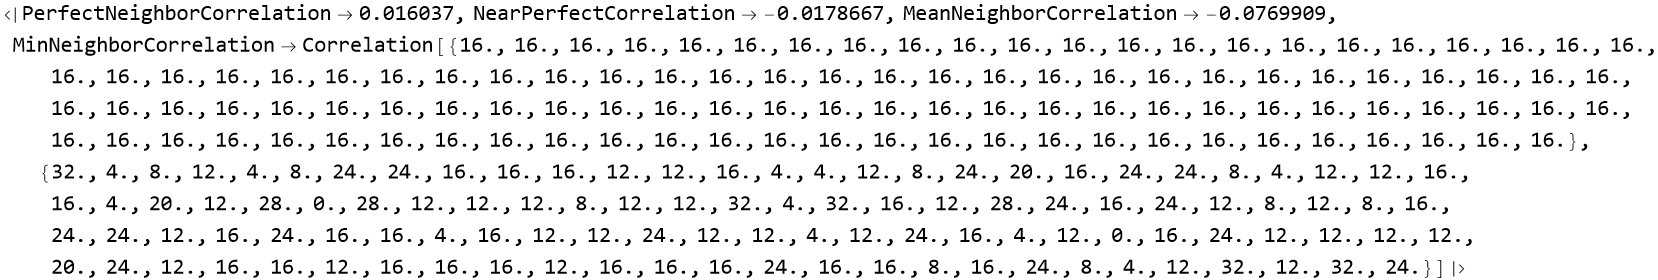

In [257]:
corr70C=<|
"PerfectNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"PerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"NearPerfectCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"NearPerfectNeighbors"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MeanNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MeanNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
],
"MinNeighborCorrelation"->
Correlation[
N[
Lookup[
rows70C,
"MinNeighborScore"
]
],
N[
Lookup[
rows70C,
"SharedMergeScore"
]
]
]
|>;
corr70C

In [259]:
ClearAll[SafeCorr70]; SafeCorr70[a_List, b_List]:=
Module[{x=N[a], y=N[b]}, If[StandardDeviation[x]==0||StandardDeviation[y]==0,
Missing["ConstantVector"], Correlation[x, y]]];

Dataset[{<|Stage -> S70C, PerfectNeighborCorrelation -> 0.016037, 
 
>     NearPerfectCorrelation -> -0.0178667, MeanNeighborCorrelation -> -0.0769909, 
 
>     MinNeighborCorrelation -> Missing[ConstantVector], 
 
>     MinNeighborDistribution -> <|16 -> 108|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, PerfectNeighborCorrelation, 
 
>      NearPerfectCorrelation, MeanNeighborCorrelation, MinNeighborCorrelation, 
 
>      MinNeighborDistribution}, {TypeSystem`Atom[String], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[Real], TypeSystem`UnknownType, 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 1]}], 1], 
 
>   <||>]
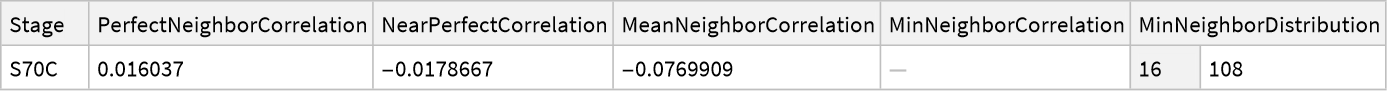

In [260]:
cert70C=<|
"Stage"->"S70C",
"PerfectNeighborCorrelation"->
SafeCorr70[
Lookup[rows70C, "PerfectNeighbors"],
Lookup[rows70C, "SharedMergeScore"]
],
"NearPerfectCorrelation"->
SafeCorr70[
Lookup[rows70C, "NearPerfectNeighbors"],
Lookup[rows70C, "SharedMergeScore"]
],
"MeanNeighborCorrelation"->
SafeCorr70[
Lookup[rows70C, "MeanNeighborScore"],
Lookup[rows70C, "SharedMergeScore"]
],
"MinNeighborCorrelation"->
SafeCorr70[
Lookup[rows70C, "MinNeighborScore"],
Lookup[rows70C, "SharedMergeScore"]
],
"MinNeighborDistribution"->
Counts[
Lookup[rows70C, "MinNeighborScore"]
]
|>;
Dataset[{cert70C}]

In [262]:
ClearAll[CodeState70D];
CodeState70D[
s_,
p_List ,
k_Integer
]:=Module[{rec},
rec[x_ ]:=rec[x] =If[
MatchQ[x,{_Integer,_Integer}],
1+Mod[
x[[1]]+2 x[[2]],
k
],
Module[{z, ps, cs},
z=rec[x[[1]]];
ps=rec/@x[[2]];
cs=rec/@x[[3]];
1+Mod[
p[[1]]+
p[[2]](z-1) +
p[[3]] * Total[ps-1] +
p[[4]] * Total[cs-1] +
p[[5]] * Total[(ps-1)^ 2] +
p[[6]] * Total[(cs-1)^ 2],
k
]
]
];
rec[s]
];

In [264]:
{
Length[states64],
CodeState70D[
states64[[1]],
perfect69[[1, "Params"]],
5
]
}

{8, 4}

In [265]:
stateRows70D=MapThread[
Function[{st, a},
<|
"StateID"->a["StateID"],
"State"->st,
"Target"->
If[
a["ContinueCases"]>0,
"Continue",
"Stop"
]
|>
],
{
states64,
auditStates64
}
];
Dataset[
KeyDrop[
stateRows70D,
"State"
]
]

Dataset[{<|StateID -> 1, Target -> Continue|>, <|StateID -> 2, Target -> Continue|>, 
 
>    <|StateID -> 3, Target -> Continue|>, <|StateID -> 4, Target -> Continue|>, 
 
>    <|StateID -> 5, Target -> Stop|>, <|StateID -> 6, Target -> Stop|>, 
 
>    <|StateID -> 7, Target -> Stop|>, <|StateID -> 8, Target -> Stop|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{StateID, Target}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Enumeration[Continue, 
 
>        Stop]]}], 8], <||>]

In [267]:
ClearAll[Collision70D];
Collision70D[m_Association]:=Module[
{codes, cCodes, sCodes, shared,
pol, cGood, sGood},
codes=
CodeState70D[
#,
m["Params"],
m["K"]
]&/@states64;
cCodes=DeleteDuplicates[
Pick[
codes,
Lookup[stateRows70D, "Target"],
"Continue"
]
];
sCodes=DeleteDuplicates[
Pick[
codes,
Lookup[stateRows70D, "Target"],
"Stop"
]
];
shared=Intersection[
cCodes,
sCodes
];
pol=m["Policy"];
cGood=Count[
Take[codes, 4],
z_ /; MemberQ[pol, z]
];
sGood=Count[
Drop[codes, 4],
z_ /;!MemberQ[pol, z]
];
<|
"Codes"->codes,
"ContinueCodes"->cCodes,
"StopCodes"->sCodes,
"SharedCodes"->shared,
"SemanticCollisions"->Length[shared],
"ContinueCorrectStates"->cGood,
"StopCorrectStates"->sGood,
"StateCorrect"->cGood+sGood
|>
];

In [269]:
Collision70D[
perfect69[[96]]
]

<|Codes -> {3, 5, 5, 3, 1, 3, 3, 1}, ContinueCodes -> {3, 5}, StopCodes -> {1, 3}, 
 
>   SharedCodes -> {3}, SemanticCollisions -> 1, ContinueCorrectStates -> 2, 
 
>   StopCorrectStates -> 4, StateCorrect -> 6|>

In [270]:
goodCollision70D=
Collision70D/@transferPerfect69;
goodTable70D=MapIndexed[
Function[{x, i},
Join[
<|"ID"->First[i]|>,
KeyDrop[x, "Codes"]
]
],
goodCollision70D
];
Dataset[goodTable70D]

Dataset[{<|ID -> 1, ContinueCodes -> {4, 1}, StopCodes -> {5, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 2, ContinueCodes -> {1, 4}, StopCodes -> {2, 5}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 3, ContinueCodes -> {4, 2}, StopCodes -> {5, 3}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 4, ContinueCodes -> {2, 5}, StopCodes -> {3, 1}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 5, ContinueCodes -> {3, 1}, StopCodes -> {4, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>}, TypeSystem`Vector[TypeSystem`Struct[{ID, ContinueCodes, 
 
>      StopCodes, SharedCodes, SemanticCollisions, ContinueCorrectStates, 
 
>      StopCorrectStates, StateCorrect}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`UnknownType, TypeSystem`AnyLength], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 5], <||>]

In [273]:
ClearAll[Collision70D];
Collision70D[m_Association]:=Module[
{codes, labels, ci, si, cCodes, sCodes,
shared, pol, cGood, sGood},
codes=
CodeState70D[
#,
m["Params"],
m["K"]
]&/@states64;
labels=Lookup[
stateRows70D,
"Target"
];
ci=Flatten@Position[
labels,
"Continue"
];
si=Flatten@Position[
labels,
"Stop"
];
cCodes=DeleteDuplicates[
codes[[ci]]
];
sCodes=DeleteDuplicates[
codes[[si]]
];
shared=Intersection[
cCodes,
sCodes
];
pol=m["Policy"];
cGood=Count[
codes[[ci]],
z_ /; MemberQ[pol, z]
];
sGood=Count[
codes[[si]],
z_ /;!MemberQ[pol, z]
];
<|
"Codes"->codes,
"ContinueCodes"->cCodes,
"StopCodes"->sCodes,
"SharedCodes"->shared,
"SemanticCollisions"->Length[shared],
"ContinueCorrectStates"->cGood,
"StopCorrectStates"->sGood,
"StateCorrect"->cGood+sGood
|>
];

In [275]:
Collision70D[
perfect69[[96]]
]

<|Codes -> {3, 5, 5, 3, 1, 3, 3, 1}, ContinueCodes -> {3, 5}, StopCodes -> {1, 3}, 
 
>   SharedCodes -> {3}, SemanticCollisions -> 1, ContinueCorrectStates -> 2, 
 
>   StopCorrectStates -> 4, StateCorrect -> 6|>

In [276]:
goodCollision70D=
Collision70D/@transferPerfect69;
goodTable70D=MapIndexed[
Function[{x, i},
Join[
<|"ID"->First[i]|>,
KeyDrop[x, "Codes"]
]
],
goodCollision70D
];
Dataset[goodTable70D]

Dataset[{<|ID -> 1, ContinueCodes -> {4, 1}, StopCodes -> {5, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 2, ContinueCodes -> {1, 4}, StopCodes -> {2, 5}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 3, ContinueCodes -> {4, 2}, StopCodes -> {5, 3}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>, <|ID -> 4, ContinueCodes -> {2, 5}, StopCodes -> {3, 1}, 
 
>     SharedCodes -> {}, SemanticCollisions -> 0, ContinueCorrectStates -> 4, 
 
>     StopCorrectStates -> 4, StateCorrect -> 8|>, 
 
>    <|ID -> 5, ContinueCodes -> {3, 1}, StopCodes -> {4, 2}, SharedCodes -> {}, 
 
>     SemanticCollisions -> 0, ContinueCorrectStates -> 4, StopCorrectStates -> 4, 
 
>     StateCorrect -> 8|>}, TypeSystem`Vector[TypeSystem`Struct[{ID, ContinueCodes, 
 
>      StopCodes, SharedCodes, SemanticCollisions, ContinueCorrectStates, 
 
>      StopCorrectStates, StateCorrect}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`UnknownType, TypeSystem`AnyLength], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 5], <||>]

In [279]:
collision70D=
Collision70D/@perfect69;
rows70D=MapThread[
Function[{m, c, s},
<|
"Params"->m["Params"],
"Policy"->m["Policy"],
"SemanticCollisions"->
c["SemanticCollisions"],
"StateCorrect"->
c["StateCorrect"],
"ContinueCorrect"->
c["ContinueCorrectStates"],
"StopCorrect"->
c["StopCorrectStates"],
"SharedMergeScore"->s,
"TransferPerfect"->
Boole[s==32]
|>
],
{
perfect69,
collision70D,
scores69C
}
];
Length[rows70D]

108

In [282]:
goodRows70D=Select[
rows70D,
#["TransferPerfect"]==1 &
];
otherRows70D=Select[
rows70D,
#["TransferPerfect"]==0 &
];
summary70D=<|
"Cases"->Length[rows70D],
"CollisionDistribution"->
Counts[
Lookup[
rows70D,
"SemanticCollisions"
]
],
"StateCorrectDistribution"->
Counts[
Lookup[
rows70D,
"StateCorrect"
]
],
"PerfectTransferCount"->
Length[goodRows70D],
"PerfectTransferCollisions"->
Counts[
Lookup[
goodRows70D,
"SemanticCollisions"
]
],
"PerfectTransferStateCorrect"->
Counts[
Lookup[
goodRows70D,
"StateCorrect"
]
],
"OtherCollisionDistribution"->
Counts[
Lookup[
otherRows70D,
"SemanticCollisions"
]
]
|>;
Dataset[{summary70D}]

Dataset[{<|Cases -> 108, CollisionDistribution -> <|0 -> 34, 1 -> 48, 2 -> 26|>, 
 
>     StateCorrectDistribution -> 
 
>      <|8 -> 5, 2 -> 16, 4 -> 54, 3 -> 4, 6 -> 20, 7 -> 3, 0 -> 2, 5 -> 4|>, 
 
>     PerfectTransferCount -> 5, PerfectTransferCollisions -> <|0 -> 5|>, 
 
>     PerfectTransferStateCorrect -> <|8 -> 5|>, 
 
>     OtherCollisionDistribution -> <|1 -> 48, 0 -> 29, 2 -> 26|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Cases, CollisionDistribution, 
 
>      StateCorrectDistribution, PerfectTransferCount, PerfectTransferCollisions, 
 
>      PerfectTransferStateCorrect, OtherCollisionDistribution}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 8], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 3]}], 1], 
 
>   <||>]

In [286]:
collisionScore70D=Counts[
Map[
Function[x,
{
x["SemanticCollisions"],
x["SharedMergeScore"]
}
],
rows70D
]
];
collisionScore70D

<|{0, 32} -> 5, {1, 4} -> 3, {1, 8} -> 7, {0, 12} -> 7, {0, 4} -> 7, {0, 24} -> 7, 
 
>   {1, 16} -> 18, {2, 16} -> 6, {0, 16} -> 3, {2, 12} -> 17, {1, 24} -> 10, 
 
>   {1, 20} -> 3, {1, 12} -> 7, {0, 28} -> 3, {0, 0} -> 2, {2, 8} -> 2, {2, 4} -> 1|>

In [288]:
correctScore70D=Counts[
Map[
Function[x,
{
x["StateCorrect"],
x["SharedMergeScore"]
}
],
rows70D
]
];
correctScore70D

<|{8, 32} -> 5, {2, 4} -> 11, {2, 8} -> 5, {4, 12} -> 31, {3, 8} -> 4, {6, 24} -> 17, 
 
>   {4, 16} -> 23, {6, 20} -> 3, {7, 28} -> 3, {0, 0} -> 2, {5, 16} -> 4|>

In [290]:
cert70D=<|
"Stage"->"S70D",
"Encoders"->Length[rows70D],
"TransferPerfect"->
Count[
rows70D,
x_ /; x["SharedMergeScore"]==32
],
"StateCorrect8"->
Count[
rows70D,
x_ /; x["StateCorrect"]==8
],
"StateCorrect8AndPerfect"->
Count[
rows70D,
x_ /;
x["StateCorrect"]==8 &&
x["SharedMergeScore"]==32
],
"PerfectWithStateError"->
Count[
rows70D,
x_ /;
x["StateCorrect"] <8 &&
x["SharedMergeScore"]==32
],
"CollisionFree"->
Count[
rows70D,
x_ /; x["SemanticCollisions"] ==0
],
"CollisionFreeButNotPerfect"->
Count[
rows70D,
x_ /;
x["SemanticCollisions"] ==0 &&
x["SharedMergeScore"] <32
],
"StateCorrectCorrelation"->
SafeCorr70[
Lookup[rows70D, "StateCorrect"],
Lookup[rows70D, "SharedMergeScore"]
],
"CollisionCorrelation"->
SafeCorr70[
Lookup[rows70D, "SemanticCollisions"],
Lookup[rows70D, "SharedMergeScore"]
]
|>;
Dataset[{cert70D}]

Dataset[{<|Stage -> S70D, Encoders -> 108, TransferPerfect -> 5, StateCorrect8 -> 5, 
 
>     StateCorrect8AndPerfect -> 5, PerfectWithStateError -> 0, CollisionFree -> 34, 
 
>     CollisionFreeButNotPerfect -> 29, StateCorrectCorrelation -> 0.967414, 
 
>     CollisionCorrelation -> -0.220886|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Encoders, TransferPerfect, 
 
>      StateCorrect8, StateCorrect8AndPerfect, PerfectWithStateError, CollisionFree, 
 
>      CollisionFreeButNotPerfect, StateCorrectCorrelation, CollisionCorrelation}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]

In [292]:
ClearAll[TrainRobustness71];
TrainRobustness71[m_Association]:=Module[
{data, pol, rows, cont, stop},
data=Join[
trainS5969,
trainChain69
];
pol=m["Policy"];
rows=Map[
Function[row,
Module[{codes, n, sel},
codes=
CodeState70D[
#,
m["Params"],
m["K"]
]&/@row["States"];
n=Length[codes];
sel=Count[
codes,
z_ /; MemberQ[pol, z]
];
<|
"Target"->row["Target"],
"States"->n,
"Selected"->sel,
"Fraction"->
If[n==0, 0., N[sel/n]]
|>
]
],
data
];
cont=Select[
rows,
#["Target"] ==="Continue" &
];
stop=Select[
rows,
#["Target"] ==="Stop" &
];
<|
"ContinueMinSelected"->
Min[Lookup[cont, "Selected"]],
"ContinueMeanSelected"->
N@Mean[Lookup[cont, "Selected"]],
"ContinueMinFraction"->
Min[Lookup[cont, "Fraction"]],
"ContinueMeanFraction"->
N@Mean[Lookup[cont, "Fraction"]],
"ContinueAllSelectedCases"->
Count[
cont,
x_ /; x["Selected"]==x["States"]
],
"StopSelectedTotal"->
Total[Lookup[stop, "Selected"]]
|>
];

In [294]:
test71=TrainRobustness71[
First[perfect69]
];
test71

<|ContinueMinSelected -> 1, ContinueMeanSelected -> 1., ContinueMinFraction -> 1., 
 
>   ContinueMeanFraction -> 1., ContinueAllSelectedCases -> 16, StopSelectedTotal -> 0|>

In [296]:
rob71=
TrainRobustness71/@perfect69;
Length[rob71]

108

In [298]:
<|
"MinSelectedDistribution"->
Counts[
Lookup[
rob71,
"ContinueMinSelected"
]
],
"MeanSelectedDistribution"->
Counts[
Lookup[
rob71,
"ContinueMeanSelected"
]
],
"MinFractionDistribution"->
Counts[
Lookup[
rob71,
"ContinueMinFraction"
]
],
"AllSelectedDistribution"->
Counts[
Lookup[
rob71,
"ContinueAllSelectedCases"
]
],
"StopSelectedDistribution"->
Counts[
Lookup[
rob71,
"StopSelectedTotal"
]
]
|>

<|MinSelectedDistribution -> <|1 -> 108|>, MeanSelectedDistribution -> <|1. -> 108|>, 
 
>   MinFractionDistribution -> <|1. -> 108|>, AllSelectedDistribution -> <|16 -> 108|>, 
 
>   StopSelectedDistribution -> <|0 -> 108|>|>

In [299]:
selected71=First@SortBy[
transferPerfect69,
Function[m,
{
Total[Abs[m["Params"]]],
Length[m["Policy"]],
m["Params"],
m["Policy"]
}
]
];
frozen71=<|
"Params"->selected71["Params"],
"K"->selected71["K"],
"Policy"->selected71["Policy"]
|>;
frozen71

<|Params -> {0, -1, 1, -1, -1, 0}, K -> 5, Policy -> {1, 4}|>

In [302]:
ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

In [304]:
p71=ParallelIn71[
Case59[2, 1, "Continue"]
];
{
Head[p71],
Length[p71],
Length[p71[[1]]],
Length[p71[[1, 1]]] >
Length[Case59[2, 1, "Continue"][[1, 1]]]
}

{List, 2, 6, True}

In [306]:
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

In [308]:
testRows71=Flatten[
Table[
<|
"Grammar"->"ParallelIn",
"Depth"->d,
"Answer"->a,
"Target"->t,
"States"->DecisionStates64[
Case71[d, a, t],
2
]
|>,
{d,{2, 5, 9, 15}},
{a, 1, 4},
{t,{"Continue", "Stop"}}
],
2
];
{
Length[testRows71],
Counts[
Lookup[testRows71, "Target"]
]
}

{32, <|Continue -> 16, Stop -> 16|>}

Dataset[{<|Stage -> S71, Topology -> ParallelIn, Cases -> 32, 
 
>     ModelFrozenBeforeTest -> True, SharedMergeUsedAsValidation -> True, 
 
>     ParallelInUsedForSelection -> False, Params -> {0, -1, 1, -1, -1, 0}, 
 
>     Policy -> {1, 4}, Passed -> 32, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Topology, Cases, ModelFrozenBeforeTest, 
 
>      SharedMergeUsedAsValidation, ParallelInUsedForSelection, Params, Policy, Passed, 
 
>      Accuracy}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]
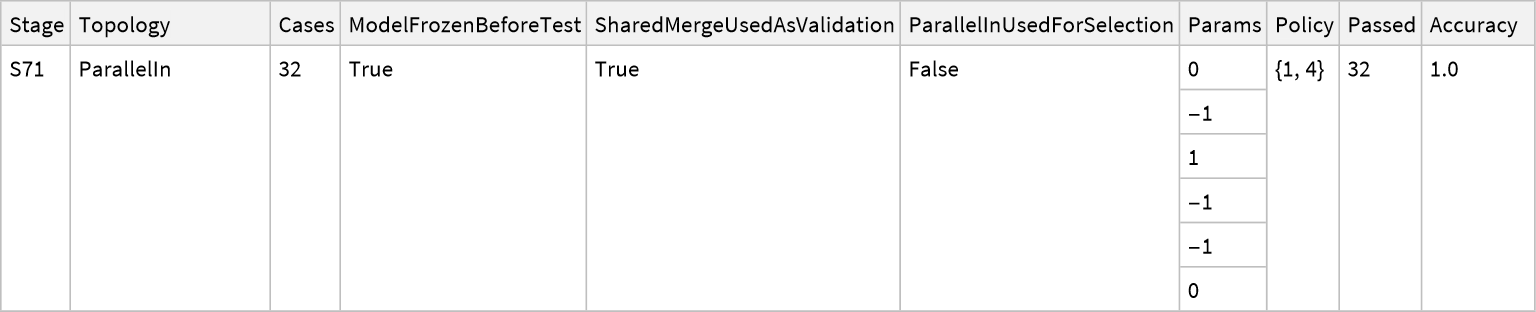

In [310]:
score71=
StaticScore69[
selected71,
testRows71
];
blindCert71=<|
"Stage"->"S71",
"Topology"->"ParallelIn",
"Cases"->32,
"ModelFrozenBeforeTest"->True,
"SharedMergeUsedAsValidation"->True,
"ParallelInUsedForSelection"->False,
"Params"->selected71["Params"],
"Policy"->selected71["Policy"],
"Passed"->score71,
"Accuracy"->N[score71/32]
|>;
Dataset[{blindCert71}]

In [313]:
candidateScores71=
StaticScore69[
#,
testRows71
]&/@transferPerfect69;
<|
"CandidateCount"->Length[candidateScores71],
"Scores"->candidateScores71,
"Distribution"->Counts[candidateScores71],
"PerfectCandidates"->Count[
candidateScores71,
32
]
|>

<|CandidateCount -> 5, Scores -> {24, 32, 32, 16, 16}, 
 
>   Distribution -> <|24 -> 1, 32 -> 2, 16 -> 2|>, PerfectCandidates -> 2|>

## S71 visual summary

Dataset[{<|Stage -> S71, Topology -> ParallelIn, Cases -> 32, 
 
>     ModelFrozenBeforeTest -> True, SharedMergeUsedAsValidation -> True, 
 
>     ParallelInUsedForSelection -> False, Params -> {0, -1, 1, -1, -1, 0}, 
 
>     Policy -> {1, 4}, Passed -> 32, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Topology, Cases, ModelFrozenBeforeTest, 
 
>      SharedMergeUsedAsValidation, ParallelInUsedForSelection, Params, Policy, Passed, 
 
>      Accuracy}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]
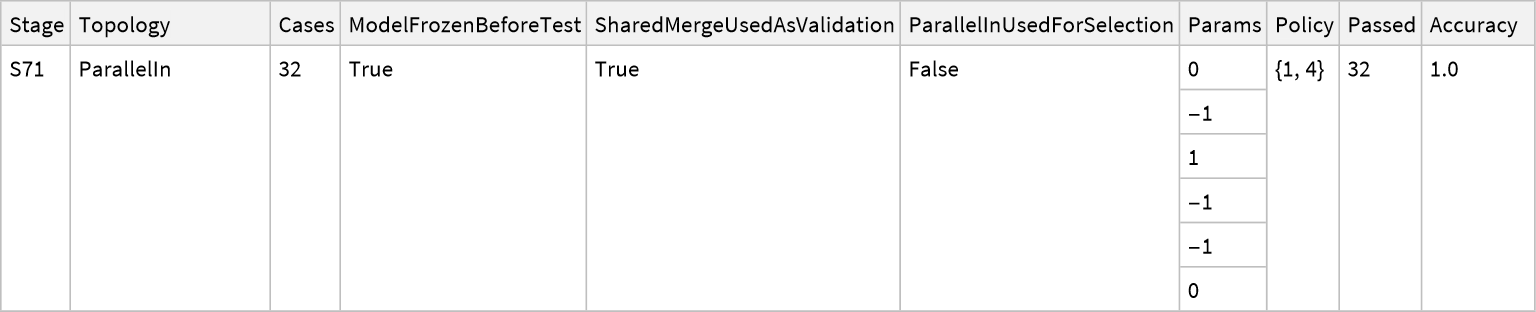

In [319]:
Dataset[{blindCert71}]

-Graphics-
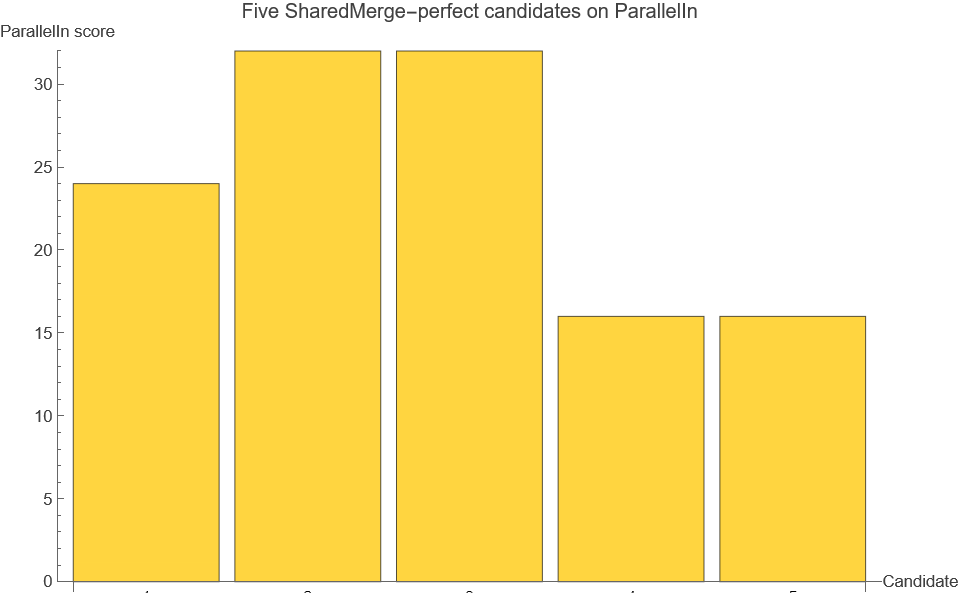

In [320]:
BarChart[
 candidateScores71,
 ChartLabels -> Placed[Range[Length[candidateScores71]], Below],
 PlotRange -> {0, 32},
 AxesLabel -> {"Candidate", "ParallelIn score"},
 PlotLabel -> "Five SharedMerge-perfect candidates on ParallelIn",
 ImageSize -> Large
]

S59 base              ParallelIn blind topology

Graph[<101>, <104>]   Graph[<125>, <140>]
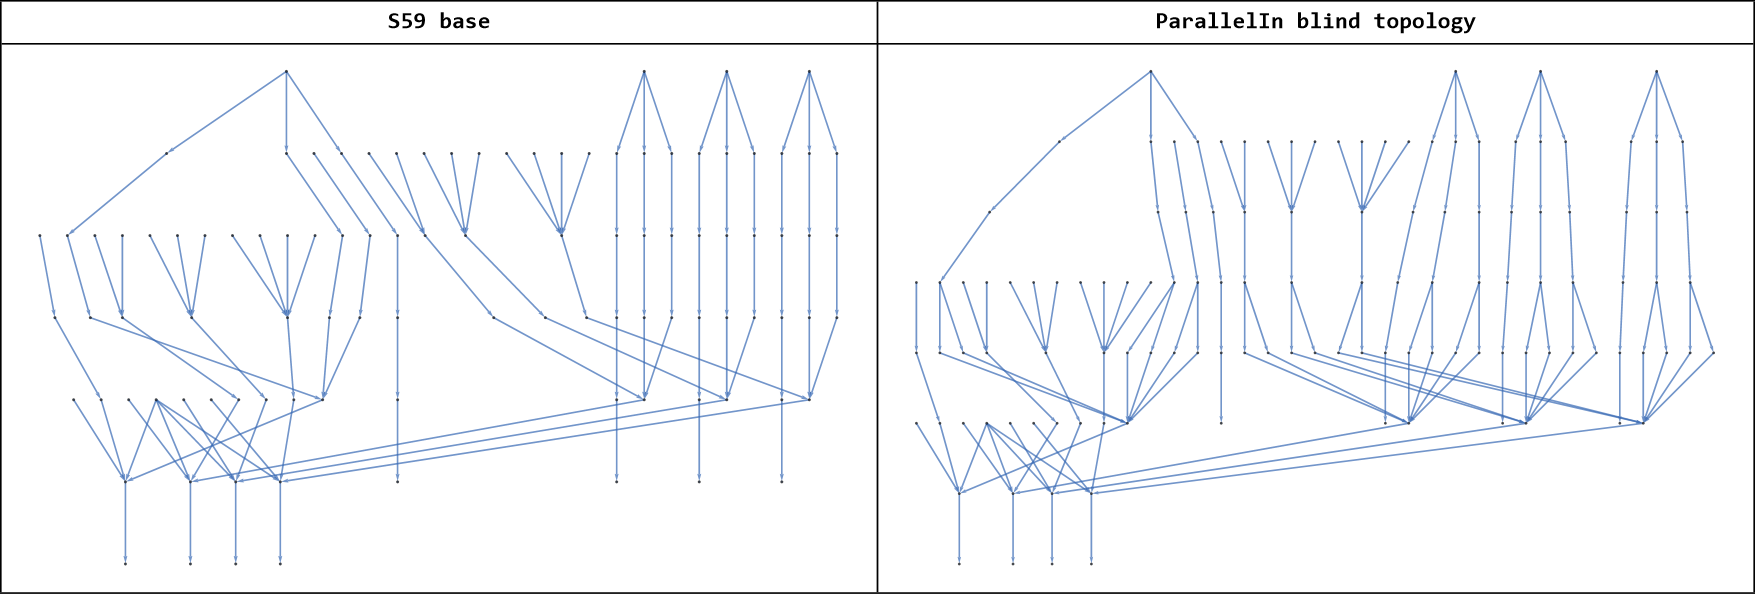

In [321]:
With[{base = Case59[2, 1, "Continue"], parallel = Case71[2, 1, "Continue"]},
 Grid[{
   {Style["S59 base", Bold, 14], Style["ParallelIn blind topology", Bold, 14]},
   {Graph[base[[1, 1]], GraphLayout -> "LayeredDigraphEmbedding", VertexLabels -> None, VertexSize -> Tiny, ImageSize -> 500],
    Graph[parallel[[1, 1]], GraphLayout -> "LayeredDigraphEmbedding", VertexLabels -> None, VertexSize -> Tiny, ImageSize -> 500]}
 }, Frame -> All, Spacings -> {2, 1}]
]

## Frozen model

Do not retune this model inside the S71 checkpoint. Create a separate notebook for S72.

In [326]:
<|"K" -> 5, "Params" -> {0, -1, 1, -1, -1, 0}, "Policy" -> {1, 4}|>

<|K -> 5, Params -> {0, -1, 1, -1, -1, 0}, Policy -> {1, 4}|>

# S72 — Frozen Topology Battery

This protocol was written and frozen before any S72 score was evaluated. The S71 model remains fixed. Run all S71 cells first, then execute the S72 cells in order. Do not edit the topology definitions after viewing scores.

## Pre-registered blind families

- `ParallelOut`: parallel expansion on decision-node outputs.
- `DiamondIn`: each incoming edge splits and reconverges before the decision node.
- `SharedParallelIn`: all parents feed two shared gates before the decision node.

The battery contains 32 cases per family and 96 cases total.

Dataset[{<|Stage -> S72, Name -> FrozenTopologyBattery, 
 
>     ProtocolFrozenBeforeEvaluation -> True, ModelFrozenBeforeEvaluation -> True, 
 
>     Topologies -> {ParallelOut, DiamondIn, SharedParallelIn}, Depths -> {2, 5, 9, 15}, 
 
>     Answers -> {1, 2, 3, 4}, Targets -> {Continue, Stop}, Radius -> 2, 
 
>     CasesPerTopology -> 32, TotalCases -> 96, S72UsedForSelection -> False, 
 
>     RetuningAllowed -> False, ProtocolHash -> 
 
>      9655a29d19e0069fd40b340f33cdf72bc729a712aa2e485423f640a3d6335feb, 
 
>     ModelMatchesS71 -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, 
 
>      ProtocolFrozenBeforeEvaluation, ModelFrozenBeforeEvaluation, Topologies, Depths, 
 
>      Answers, Targets, Radius, CasesPerTopology, TotalCases, S72UsedForSelection, 
 
>      RetuningAllowed, ProtocolHash, ModelMatchesS71}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 4], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
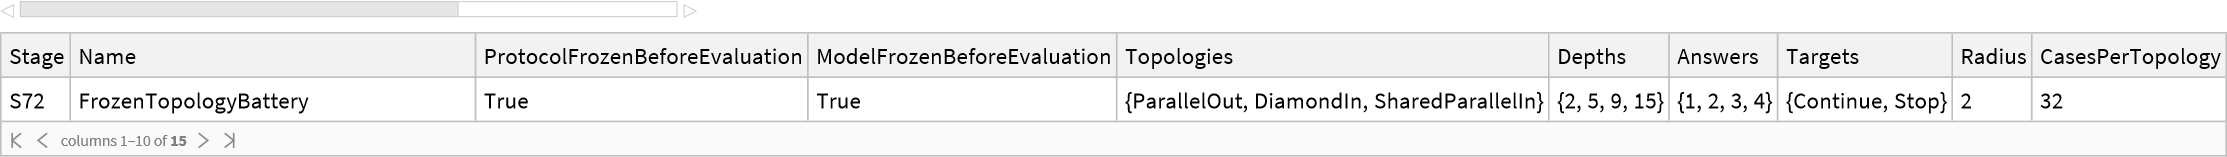

In [335]:
ClearAll["Global`*72"];

frozenModel72=<|
"Params"->{0,-1,1,-1,-1,0},
"K"->5,
"Policy"->{1,4}
|>;

topologies72={
"ParallelOut",
"DiamondIn",
"SharedParallelIn"
};

depths72={2,5,9,15};
answers72=Range[4];
targets72={"Continue","Stop"};

protocol72=<|
"Stage"->"S72",
"Name"->"FrozenTopologyBattery",
"ProtocolFrozenBeforeEvaluation"->True,
"ModelFrozenBeforeEvaluation"->True,
"Model"->frozenModel72,
"Topologies"->topologies72,
"Depths"->depths72,
"Answers"->answers72,
"Targets"->targets72,
"Radius"->2,
"CasesPerTopology"->32,
"TotalCases"->96,
"S72UsedForSelection"->False,
"RetuningAllowed"->False
|>;

protocolHash72=Hash[
Normal[protocol72],
"SHA256",
"HexString"
];

modelLock72=SameQ[
frozenModel72,
frozen71
];

Dataset[{
Join[
KeyDrop[protocol72,"Model"],
<|
"ProtocolHash"->protocolHash72,
"ModelMatchesS71"->modelLock72
|>
]
}]

In [345]:
ClearAll[
ParallelOut72,
DiamondIn72,
SharedParallelIn72,
Case72
];

ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72[
topology_String,
d_Integer,
a_Integer,
t_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[d,a,t]],
"DiamondIn",
DiamondIn72[Case59[d,a,t]],
"SharedParallelIn",
SharedParallelIn72[Case59[d,a,t]],
_,
$Failed
];

Dataset[{<|Topology -> ParallelOut, ShapeOK -> True, MetadataPreserved -> True, 
 
>     AnswerPreserved -> True, DirectedEdgesOnly -> True, EdgeCountBefore -> 104, 
 
>     EdgeCountAfter -> 116, EdgeCountIncreased -> True|>, 
 
>    <|Topology -> DiamondIn, ShapeOK -> True, MetadataPreserved -> True, 
 
>     AnswerPreserved -> True, DirectedEdgesOnly -> True, EdgeCountBefore -> 104, 
 
>     EdgeCountAfter -> 152, EdgeCountIncreased -> True|>, 
 
>    <|Topology -> SharedParallelIn, ShapeOK -> True, MetadataPreserved -> True, 
 
>     AnswerPreserved -> True, DirectedEdgesOnly -> True, EdgeCountBefore -> 104, 
 
>     EdgeCountAfter -> 124, EdgeCountIncreased -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, ShapeOK, MetadataPreserved, 
 
>      AnswerPreserved, DirectedEdgesOnly, EdgeCountBefore, EdgeCountAfter, 
 
>      EdgeCountIncreased}, {TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 3], <||>]
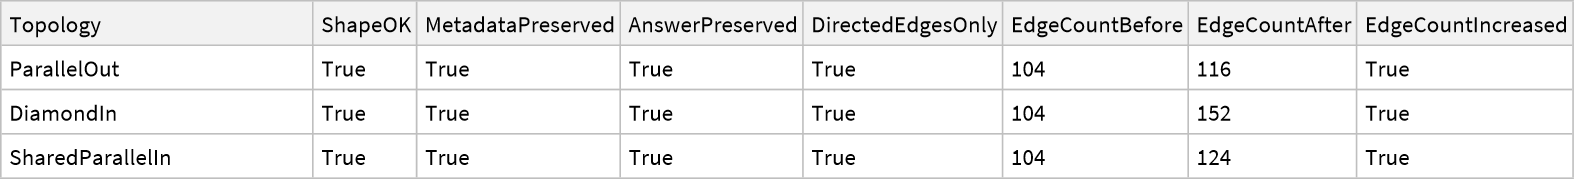

In [350]:
ClearAll[TopologyAudit72];

TopologyAudit72[topology_String]:=Module[
{base,changed,baseEdges,newEdges},
base=Case59[2,1,"Continue"];
changed=Case72[topology,2,1,"Continue"];
baseEdges=base[[1,1]];
newEdges=changed[[1,1]];
<|
"Topology"->topology,
"ShapeOK"->MatchQ[changed,{{_List,_List,_Integer,_List,_List,_List},_Integer}],
"MetadataPreserved"->SameQ[
changed[[1,2;;6]],
base[[1,2;;6]]
],
"AnswerPreserved"->SameQ[changed[[2]],base[[2]]],
"DirectedEdgesOnly"->AllTrue[
newEdges,
MatchQ[#,DirectedEdge[_,_]]&
],
"EdgeCountBefore"->Length[baseEdges],
"EdgeCountAfter"->Length[newEdges],
"EdgeCountIncreased"->Length[newEdges]>Length[baseEdges]
|>
];

audit72=TopologyAudit72/@topologies72;

auditPass72=And@@Flatten[
Lookup[
audit72,
{
"ShapeOK",
"MetadataPreserved",
"AnswerPreserved",
"DirectedEdgesOnly",
"EdgeCountIncreased"
}
]
];

Dataset[audit72]

Dataset[{<|ExpectedCases -> 96, BuiltCases -> 96, 
 
>     CasesByTopology -> <|ParallelOut -> 32, DiamondIn -> 32, SharedParallelIn -> 32|>, 
 
>     CasesByTarget -> <|Continue -> 48, Stop -> 48|>, AuditPassed -> True, 
 
>     ModelLockPassed -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{ExpectedCases, 
 
>      BuiltCases, CasesByTopology, CasesByTarget, AuditPassed, ModelLockPassed}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>         SharedParallelIn]], TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>       TypeSystem`Atom[Integer], 2], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
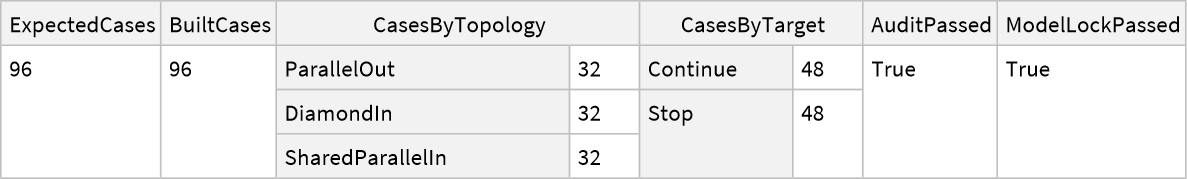

In [355]:
spec72=Tuples[{
topologies72,
depths72,
answers72,
targets72
}];

testRows72=Map[
Function[spec,
<|
"Grammar"->spec[[1]],
"Depth"->spec[[2]],
"Answer"->spec[[3]],
"Target"->spec[[4]],
"States"->DecisionStates64[
Case72@@spec,
protocol72["Radius"]
]
|>
],
spec72
];

caseBuildCert72=<|
"ExpectedCases"->protocol72["TotalCases"],
"BuiltCases"->Length[testRows72],
"CasesByTopology"->Counts[Lookup[testRows72,"Grammar"]],
"CasesByTarget"->Counts[Lookup[testRows72,"Target"]],
"AuditPassed"->auditPass72,
"ModelLockPassed"->modelLock72
|>;

Dataset[{caseBuildCert72}]

In [359]:
encodedRows72=If[
TrueQ[modelLock72]&&TrueQ[auditPass72],
EncodeRows69[
testRows72,
frozenModel72["Params"],
frozenModel72["K"]
],
$Failed
];

caseResults72=If[
ListQ[encodedRows72],
Map[
Function[row,
Module[{prediction},
prediction=If[
AnyTrue[
row["Codes"],
MemberQ[frozenModel72["Policy"],#]&
],
"Continue",
"Stop"
];
Join[
row,
<|
"Prediction"->prediction,
"Passed"->Boole[prediction===row["Target"]]
|>
]
]
],
encodedRows72
],
{}
];

scoresByTopology72=GroupBy[
caseResults72,
# ["Grammar"]&,
Total[Lookup[#,"Passed"]]&
];

scoresByTopologyTarget72=GroupBy[
caseResults72,
{# ["Grammar"],# ["Target"]}&,
Total[Lookup[#,"Passed"]]&
];

scoresByTopologyDepth72=GroupBy[
caseResults72,
{# ["Grammar"],# ["Depth"]}&,
Total[Lookup[#,"Passed"]]&
];

Dataset[{<|Stage -> S72, Name -> FrozenTopologyBattery, 
 
>     ProtocolHash -> 9655a29d19e0069fd40b340f33cdf72bc729a712aa2e485423f640a3d6335feb, 
 
>     ProtocolFrozenBeforeEvaluation -> True, ModelFrozenBeforeEvaluation -> True, 
 
>     S72UsedForSelection -> False, RetuningAllowed -> False, 
 
>     Model -> <|Params -> {0, -1, 1, -1, -1, 0}, K -> 5, Policy -> {1, 4}|>, 
 
>     Topologies -> {ParallelOut, DiamondIn, SharedParallelIn}, Cases -> 96, 
 
>     ScoresByTopology -> <|ParallelOut -> 8, DiamondIn -> 16, SharedParallelIn -> 28|>, 
 
>     ScoresByTopologyTarget -> 
 
>      <|{ParallelOut, Continue} -> 8, {ParallelOut, Stop} -> 0, 
 
>       {DiamondIn, Continue} -> 0, {DiamondIn, Stop} -> 16, 
 
>       {SharedParallelIn, Continue} -> 16, {SharedParallelIn, Stop} -> 12|>, 
 
>     AllTopologiesPerfect -> False, TotalPassed -> 52, Accuracy -> 0.541667|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, ProtocolHash, 
 
>      ProtocolFrozenBeforeEvaluation, ModelFrozenBeforeEvaluation, S72UsedForSelection, 
 
>      RetuningAllowed, Model, Topologies, Cases, ScoresByTopology, 
 
>      ScoresByTopologyTarget, AllTopologiesPerfect, TotalPassed, Accuracy}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Struct[{Params, K, Policy}, 
 
>       {TypeSystem`Vector[TypeSystem`Atom[Integer], 6], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Vector[TypeSystem`Atom[Integer], 2]}], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>         SharedParallelIn]], TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Tuple[{TypeSystem`Atom[TypeSystem`Enumeration[
 
>           DiamondIn, ParallelOut, SharedParallelIn]], 
 
>         TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]]}], 
 
>       TypeSystem`Atom[Integer], 6], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Real]}], 1], <||>]
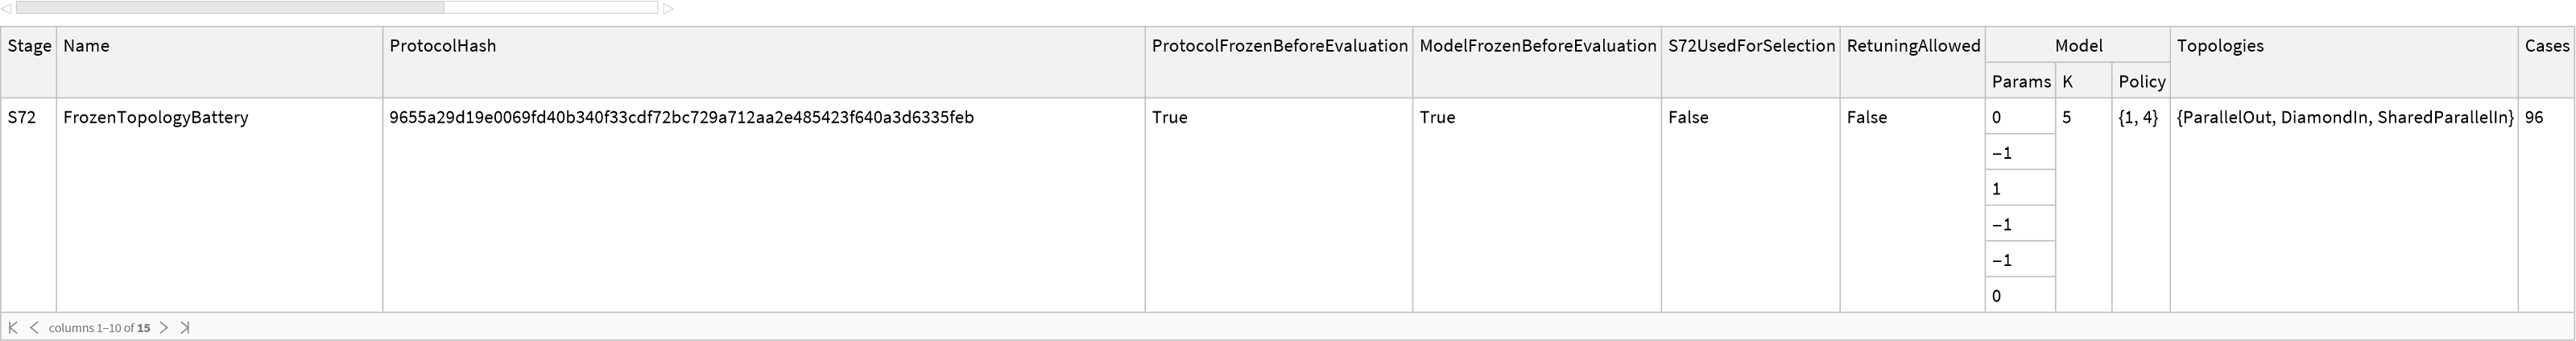

In [364]:
cert72=<|
"Stage"->"S72",
"Name"->"FrozenTopologyBattery",
"ProtocolHash"->protocolHash72,
"ProtocolFrozenBeforeEvaluation"->True,
"ModelFrozenBeforeEvaluation"->True,
"S72UsedForSelection"->False,
"RetuningAllowed"->False,
"Model"->frozenModel72,
"Topologies"->topologies72,
"Cases"->Length[caseResults72],
"ScoresByTopology"->scoresByTopology72,
"ScoresByTopologyTarget"->scoresByTopologyTarget72,
"AllTopologiesPerfect"->And@@MapThread[
SameQ,
{
Lookup[scoresByTopology72,topologies72],
ConstantArray[protocol72["CasesPerTopology"],Length[topologies72]]
}
],
"TotalPassed"->Total[Lookup[caseResults72,"Passed"]],
"Accuracy"->N[Mean[Lookup[caseResults72,"Passed"]]]
|>;

Dataset[{cert72}]

In [366]:
Dataset[
Map[
Function[row,
KeyTake[
row,
{
"Grammar",
"Depth",
"Answer",
"Target",
"Prediction",
"Passed"
}
]
],
Select[caseResults72,# ["Passed"]==0&]
]
]

Dataset[{<|Grammar -> ParallelOut, Depth -> 2, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 5, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 9, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 15, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 3, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 4, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 3, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 5, Answer -> 4, Target -> Continue, 
 
>     Prediction -> Stop, Passed -> 0|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 9, Answer -> 1, Target -> Contin

-Graphics-
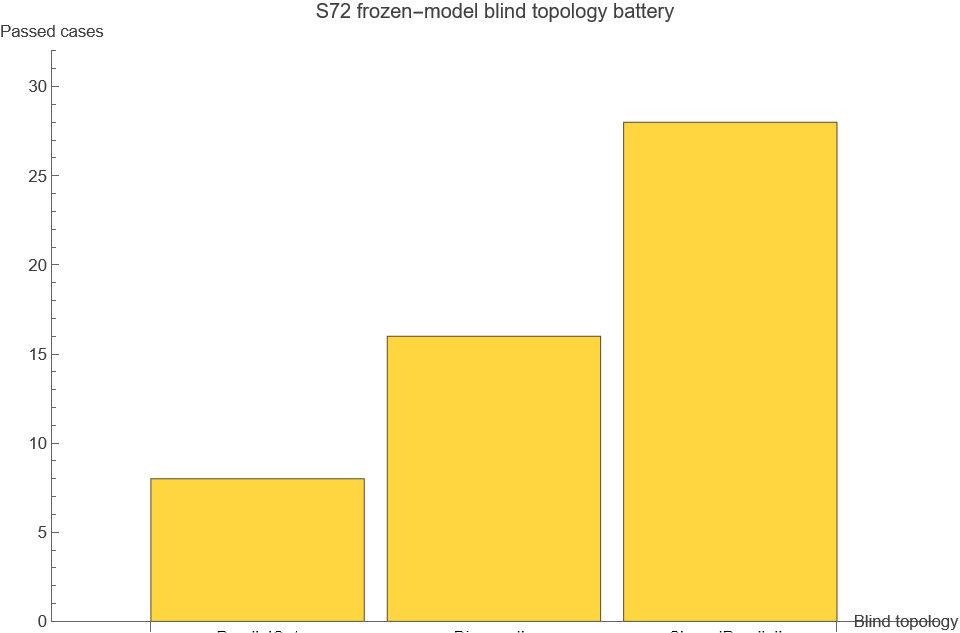

In [367]:
BarChart[
Lookup[scoresByTopology72,topologies72],
ChartLabels->Placed[topologies72,Below],
PlotRange->{0,protocol72["CasesPerTopology"]},
AxesLabel->{"Blind topology","Passed cases"},
PlotLabel->"S72 frozen-model blind topology battery",
ImageSize->Large
]

# S73 — Topology Failure Mechanism Audit

This stage is diagnostic only. It does not change TCCT, the encoder, the frozen parameters, K, or the policy. It reads the frozen S72 result and traces latent-code selection and semantic collisions.

## Audit questions

1. Which Continue cases lose every selected latent code?
2. Which Stop cases acquire a selected latent code?
3. Are failures invariant across depth?
4. Do new raw relation states appear, or do known states collide after encoding?

No search or retuning is permitted in this notebook.

Dataset[{<|Stage -> S73, Name -> TopologyFailureMechanismAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, ModelChanged -> False, RetuningAllowed -> False, 
 
>     NewModelSearch -> False, ModelMatchesS71AndS72 -> True, 
 
>     S72ProtocolHashMatches -> True, S72ResultMatches -> True, PreflightPassed -> True|>
 
>     }, TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, CoreTCCTChanged, 
 
>      ModelChanged, RetuningAllowed, NewModelSearch, ModelMatchesS71AndS72, 
 
>      S72ProtocolHashMatches, S72ResultMatches, PreflightPassed}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
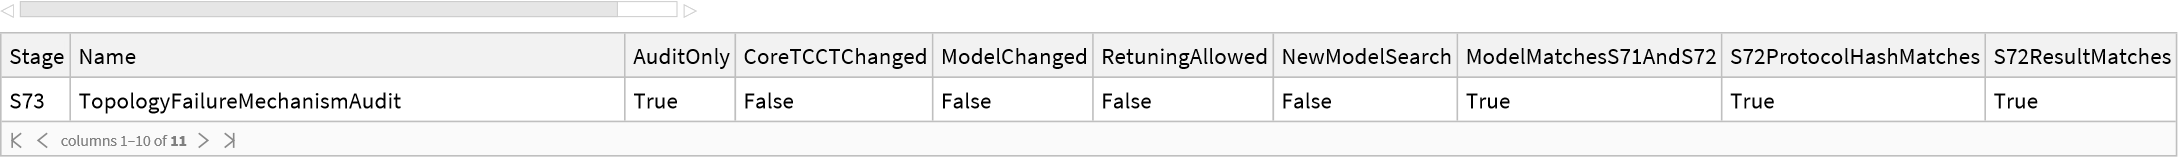

In [376]:
ClearAll["Global`*73"];

frozenModel73=<|
"Params"->{0,-1,1,-1,-1,0},
"K"->5,
"Policy"->{1,4}
|>;

expectedS72ProtocolHash73=
"9655a29d19e0069fd40b340f33cdf72bc729a712aa2e485423f640a3d6335feb";

expectedS72Scores73=<|
"ParallelOut"->8,
"DiamondIn"->16,
"SharedParallelIn"->28
|>;

modelLock73=SameQ[
frozenModel73,
frozenModel72,
frozen71
];

protocolLock73=SameQ[
protocolHash72,
expectedS72ProtocolHash73
];

resultLock73=And[
SameQ[scoresByTopology72,expectedS72Scores73],
SameQ[Total[Lookup[caseResults72,"Passed"]],52],
SameQ[Length[caseResults72],96]
];

preflightPass73=And[
modelLock73,
protocolLock73,
resultLock73
];

preflight73=<|
"Stage"->"S73",
"Name"->"TopologyFailureMechanismAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"ModelChanged"->False,
"RetuningAllowed"->False,
"NewModelSearch"->False,
"ModelMatchesS71AndS72"->modelLock73,
"S72ProtocolHashMatches"->protocolLock73,
"S72ResultMatches"->resultLock73,
"PreflightPassed"->preflightPass73
|>;

Dataset[{preflight73}]

Dataset[{<|Topology -> ParallelOut, Answer -> 1, Cases -> 8, Passed -> 0, 
 
>     Accuracy -> 0., ContinuePassed -> 0, StopPassed -> 0, 
 
>     FailureTypes -> <|ContinueFalseNegative -> 4, StopFalsePositive -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{4} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> ParallelOut, Answer -> 2, Cases -> 8, Passed -> 0, Accuracy -> 0., 
 
>     ContinuePassed -> 0, StopPassed -> 0, 
 
>     FailureTypes -> <|ContinueFalseNegative -> 4, StopFalsePositive -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{1} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> ParallelOut, Answer -> 3, Cases -> 8, Passed -> 4, Accuracy -> 0.5, 
 
>     ContinuePassed -> 4, StopPassed -> 0, 
 
>     FailureTypes -> <|Correct -> 4, StopFalsePositive -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{4} -> 4|>, StopSelectedPatterns -> <|{1} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> ParallelOut, Answer -> 4, Cases -> 8, Passed -> 4, Accuracy -> 0.5, 
 
>     ContinuePassed -> 4, StopPassed -> 0, 
 
>     FailureTypes -> <|Correct -> 4, StopFalsePositive -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{4} -> 4|>, StopSelectedPatterns -> <|{1, 4} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> DiamondIn, Answer -> 1, Cases -> 8, Passed -> 4, Accuracy -> 0.5, 
 
>     ContinuePassed -> 0, StopPassed -> 4, 
 
>     FailureTypes -> <|ContinueFalseNegative -> 4, Correct -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> DiamondIn, Answer -> 2, Cases -> 8, Passed -> 4, Accuracy -> 0.5, 
 
>     ContinuePassed -> 0, StopPassed -> 4, 
 
>     FailureTypes -> <|ContinueFalseNegative -> 4, Correct -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> DiamondIn, Answer -> 3, Cases -> 8, Passed -> 4, Accuracy -> 0.5, 
 
>     ContinuePassed -> 0, StopPassed -> 4, 
 
>     FailureTypes -> <|ContinueFalseNegative -> 4, Correct -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> DiamondIn, Answer -> 4, Cases -> 8, Passed -> 4, Accuracy -> 0.5, 
 
>     ContinuePassed -> 0, StopPassed -> 4, 
 
>     FailureTypes -> <|ContinueFalseNegative -> 4, Correct -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 1, Cases -> 8, Passed -> 8, 
 
>     Accuracy -> 1., ContinuePassed -> 4, StopPassed -> 4, 
 
>     FailureTypes -> <|Correct -> 8|>, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{} -> 4|>, DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 2, Cases -> 8, Passed -> 4, 
 
>     Accuracy -> 0.5, ContinuePassed -> 4, StopPassed -> 0, 
 
>     FailureTypes -> <|Correct -> 4, StopFalsePositive -> 4|>, 
 
>     ContinueSelectedPatterns -> <|{4} -> 4|>, StopSelectedPatterns -> <|{1} -> 4|>, 
 
>     DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 3, Cases -> 8, Passed -> 8, 
 
>     Accuracy -> 1., ContinuePassed -> 4, StopPassed -> 4, 
 
>     FailureTypes -> <|Correct -> 8|>, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{} -> 4|>, DepthInvariantPrediction -> True|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 4, Cases -> 8, Passed -> 8, 
 
>     Accuracy -> 1., ContinuePassed -> 4, StopPassed -> 4, 
 
>     FailureTypes -> <|Correct -> 8|>, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{} -> 4|>, DepthInvariantPrediction -> True|>}, 
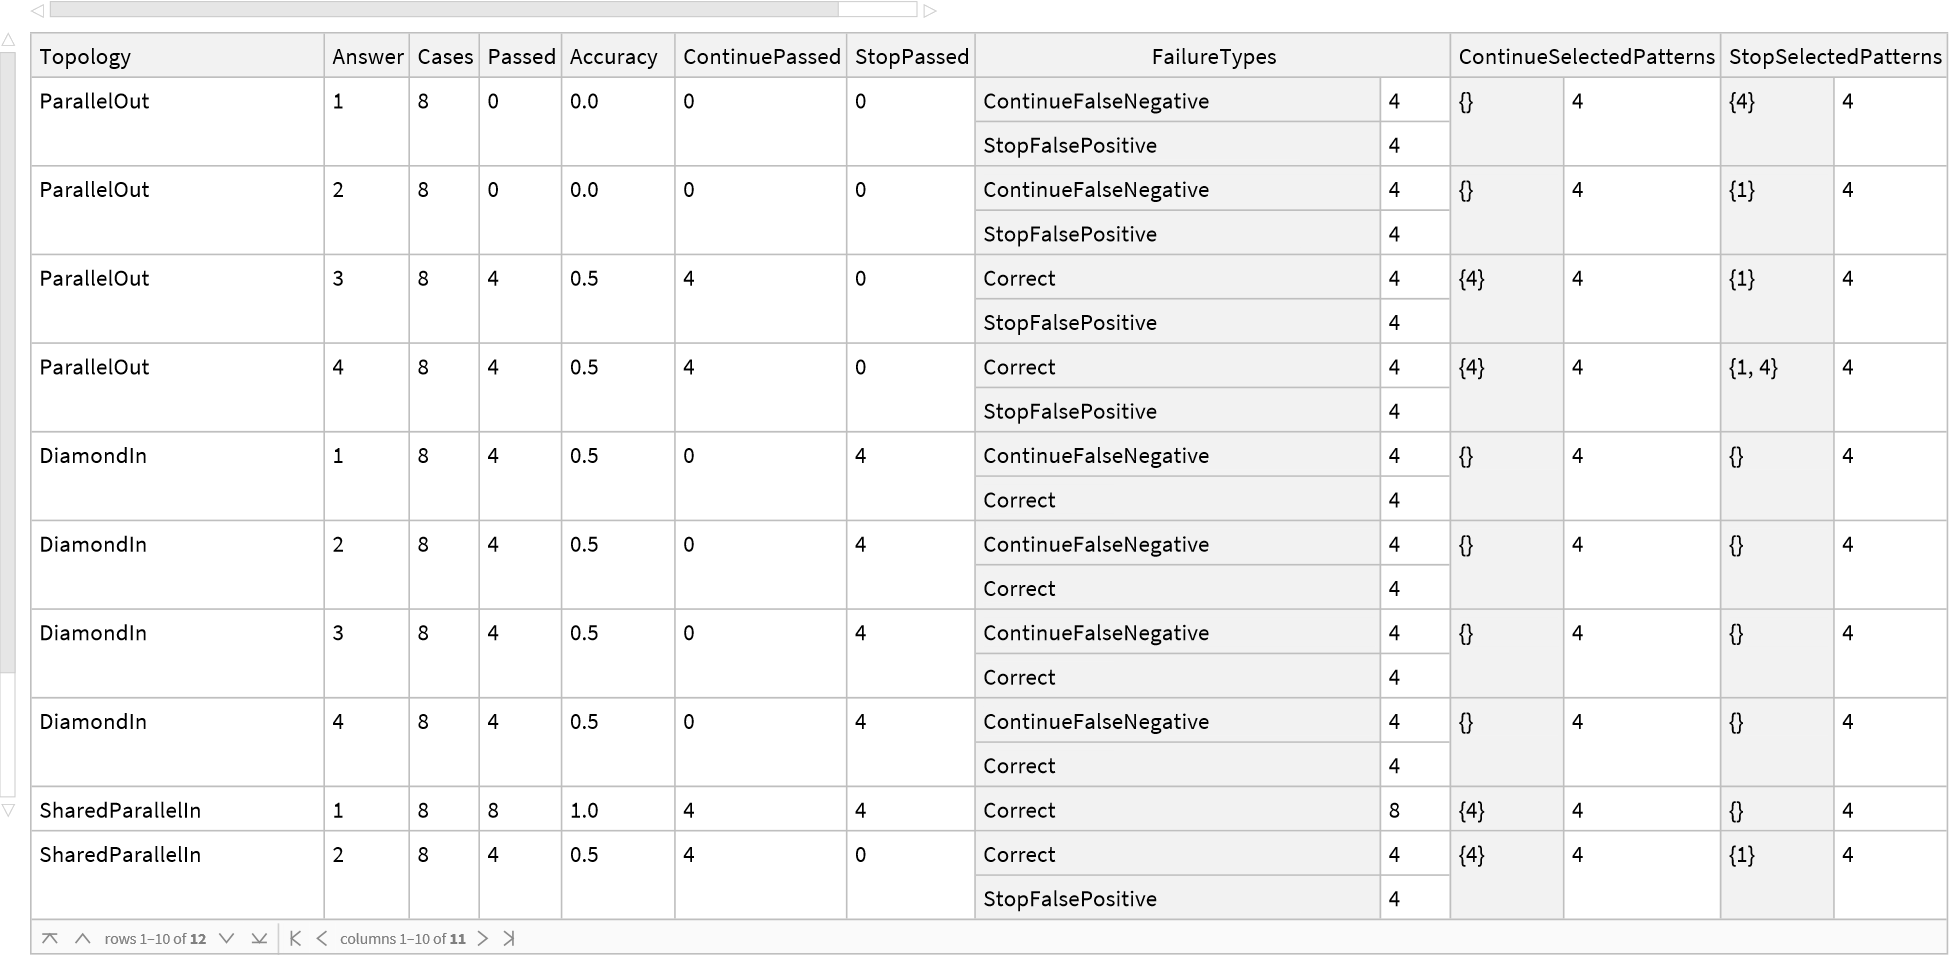

In [386]:
ClearAll[SelectedCodes73,CaseAudit73];

SelectedCodes73[codes_List]:=Select[
Sort@DeleteDuplicates[codes],
MemberQ[frozenModel73["Policy"],#]&
];

CaseAudit73[row_Association]:=Module[
{selected,failureType},
selected=SelectedCodes73[row["Codes"]];
failureType=Which[
row["Passed"]==1,
"Correct",
row["Target"]==="Continue",
"ContinueFalseNegative",
True,
"StopFalsePositive"
];
Join[
row,
<|
"SelectedCodes"->selected,
"SelectedCount"->Length[selected],
"CodeSignature"->Sort[row["Codes"]],
"FailureType"->failureType
|>
]
];

caseAudit73=If[
TrueQ[preflightPass73],
CaseAudit73/@caseResults72,
{}
];

answerSummary73=Flatten[
Table[
Module[{sub,continueRows,stopRows},
sub=Select[
caseAudit73,
# ["Grammar"]===topology&&# ["Answer"]===answer&
];
continueRows=Select[sub,# ["Target"]==="Continue"&];
stopRows=Select[sub,# ["Target"]==="Stop"&];
<|
"Topology"->topology,
"Answer"->answer,
"Cases"->Length[sub],
"Passed"->Total[Lookup[sub,"Passed"]],
"Accuracy"->N[Mean[Lookup[sub,"Passed"]]],
"ContinuePassed"->Total[Lookup[continueRows,"Passed"]],
"StopPassed"->Total[Lookup[stopRows,"Passed"]],
"FailureTypes"->Counts[Lookup[sub,"FailureType"]],
"ContinueSelectedPatterns"->Counts[
Lookup[continueRows,"SelectedCodes"]
],
"StopSelectedPatterns"->Counts[
Lookup[stopRows,"SelectedCodes"]
],
"DepthInvariantPrediction"->And[
Length[DeleteDuplicates[Lookup[continueRows,"Prediction"]]]==1,
Length[DeleteDuplicates[Lookup[stopRows,"Prediction"]]]==1
]
|>
],
{topology,topologies72},
{answer,answers72}
],
1
];

Dataset[answerSummary73]

Dataset[{<|Topology -> ParallelOut, Answer -> 1, DepthPairs -> 4, 
 
>     PerfectDepthPairs -> 0, PolicySeparableDepths -> 0, 
 
>     DepthInvariantCodePair -> True, ContinueSelectedPatterns -> <|{} -> 4|>, 
 
>     StopSelectedPatterns -> <|{4} -> 4|>, SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> ParallelOut, Answer -> 2, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{1} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> ParallelOut, Answer -> 3, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{4} -> 4|>, StopSelectedPatterns -> <|{1} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> ParallelOut, Answer -> 4, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{4} -> 4|>, StopSelectedPatterns -> <|{1, 4} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{4} -> 4|>|>, 
 
>    <|Topology -> DiamondIn, Answer -> 1, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> DiamondIn, Answer -> 2, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> DiamondIn, Answer -> 3, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> DiamondIn, Answer -> 4, DepthPairs -> 4, PerfectDepthPairs -> 0, 
 
>     PolicySeparableDepths -> 0, DepthInvariantCodePair -> True, 
 
>     ContinueSelectedPatterns -> <|{} -> 4|>, StopSelectedPatterns -> <|{} -> 4|>, 
 
>     SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 1, DepthPairs -> 4, 
 
>     PerfectDepthPairs -> 4, PolicySeparableDepths -> 4, 
 
>     DepthInvariantCodePair -> True, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{} -> 4|>, SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 2, DepthPairs -> 4, 
 
>     PerfectDepthPairs -> 0, PolicySeparableDepths -> 0, 
 
>     DepthInvariantCodePair -> True, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{1} -> 4|>, SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 3, DepthPairs -> 4, 
 
>     PerfectDepthPairs -> 4, PolicySeparableDepths -> 4, 
 
>     DepthInvariantCodePair -> True, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{} -> 4|>, SharedSelectedPatterns -> <|{} -> 4|>|>, 
 
>    <|Topology -> SharedParallelIn, Answer -> 4, DepthPairs -> 4, 
 
>     PerfectDepthPairs -> 4, PolicySeparableDepths -> 4, 
 
>     DepthInvariantCodePair -> True, ContinueSelectedPatterns -> <|{4} -> 4|>, 
 
>     StopSelectedPatterns -> <|{} -> 4|>, SharedSelectedPatterns -> <|{} -> 4|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, Answer, DepthPairs, 
 
>      PerfectDepthPairs, PolicySeparableDepths, DepthInvariantCodePair, 
 
>      ContinueSelectedPatterns, StopSelectedPatterns, SharedSelectedPatterns}, 
 
>     {TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>        SharedParallelIn]], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeS
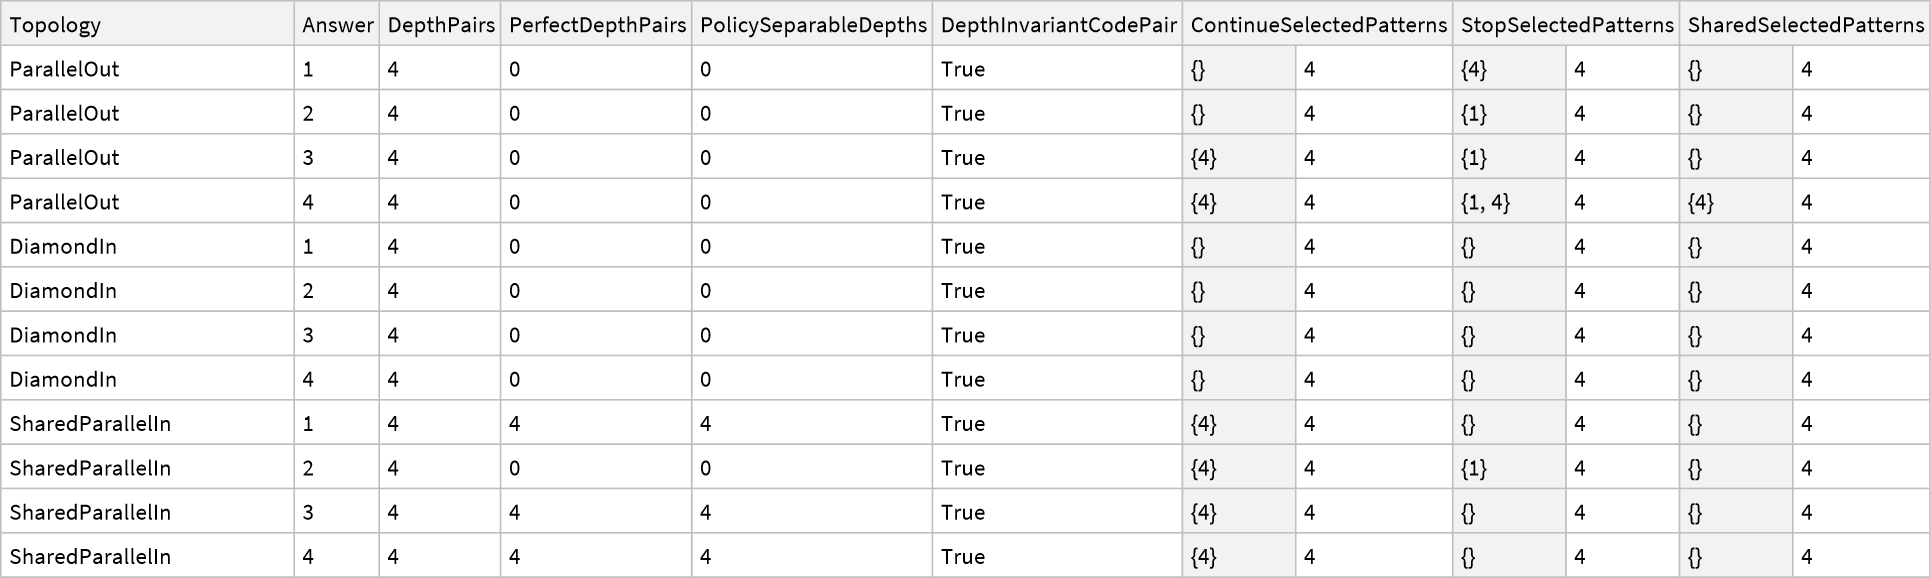

In [392]:
pairRows73=Flatten[
Table[
Module[{continueRow,stopRow,continueSelected,stopSelected},
continueRow=SelectFirst[
caseAudit73,
# ["Grammar"]===topology&&
# ["Depth"]===depth&&
# ["Answer"]===answer&&
# ["Target"]==="Continue"&
];
stopRow=SelectFirst[
caseAudit73,
# ["Grammar"]===topology&&
# ["Depth"]===depth&&
# ["Answer"]===answer&&
# ["Target"]==="Stop"&
];
continueSelected=continueRow["SelectedCodes"];
stopSelected=stopRow["SelectedCodes"];
<|
"Topology"->topology,
"Depth"->depth,
"Answer"->answer,
"ContinueCodes"->continueRow["CodeSignature"],
"StopCodes"->stopRow["CodeSignature"],
"ContinueSelected"->continueSelected,
"StopSelected"->stopSelected,
"SharedCodes"->Intersection[
continueRow["CodeSignature"],
stopRow["CodeSignature"]
],
"SharedSelectedCodes"->Intersection[
continueSelected,
stopSelected
],
"PolicySeparable"->And[
Length[continueSelected]>0,
Length[stopSelected]==0
],
"PairPassed"->Boole[
continueRow["Passed"]==1&&stopRow["Passed"]==1
],
"PairSignature"->{
continueRow["CodeSignature"],
stopRow["CodeSignature"]
}
|>
],
{topology,topologies72},
{depth,depths72},
{answer,answers72}
],
2
];

pairSummary73=Flatten[
Table[
Module[{sub},
sub=Select[
pairRows73,
# ["Topology"]===topology&&# ["Answer"]===answer&
];
<|
"Topology"->topology,
"Answer"->answer,
"DepthPairs"->Length[sub],
"PerfectDepthPairs"->Total[Lookup[sub,"PairPassed"]],
"PolicySeparableDepths"->Count[
Lookup[sub,"PolicySeparable"],
True
],
"DepthInvariantCodePair"->Apply[
SameQ,
Lookup[sub,"PairSignature"]
],
"ContinueSelectedPatterns"->Counts[
Lookup[sub,"ContinueSelected"]
],
"StopSelectedPatterns"->Counts[
Lookup[sub,"StopSelected"]
],
"SharedSelectedPatterns"->Counts[
Lookup[sub,"SharedSelectedCodes"]
]
|>
],
{topology,topologies72},
{answer,answers72}
],
1
];

Dataset[pairSummary73]

Dataset[{<|Topology -> ParallelOut, Code -> 1, SelectedCode -> True, 
 
>     ContinueOccurrences -> 0, StopOccurrences -> 16, SemanticCollision -> False, 
 
>     StopRisk -> True, ContinueSupport -> False|>, 
 
>    <|Topology -> ParallelOut, Code -> 2, SelectedCode -> False, 
 
>     ContinueOccurrences -> 4, StopOccurrences -> 0, SemanticCollision -> False, 
 
>     StopRisk -> False, ContinueSupport -> False|>, 
 
>    <|Topology -> ParallelOut, Code -> 3, SelectedCode -> False, 
 
>     ContinueOccurrences -> 4, StopOccurrences -> 0, SemanticCollision -> False, 
 
>     StopRisk -> False, ContinueSupport -> False|>, 
 
>    <|Topology -> ParallelOut, Code -> 4, SelectedCode -> True, 
 
>     ContinueOccurrences -> 8, StopOccurrences -> 8, SemanticCollision -> True, 
 
>     StopRisk -> True, ContinueSupport -> True|>, 
 
>    <|Topology -> ParallelOut, Code -> 5, SelectedCode -> False, 
 
>     ContinueOccurrences -> 0, StopOccurrences -> 8, SemanticCollision -> False, 
 
>     StopRisk -> False, ContinueSupport -> False|>, 
 
>    <|Topology -> DiamondIn, Code -> 2, SelectedCode -> False, 
 
>     ContinueOccurrences -> 16, StopOccurrences -> 16, SemanticCollision -> True, 
 
>     StopRisk -> False, ContinueSupport -> False|>, 
 
>    <|Topology -> SharedParallelIn, Code -> 1, SelectedCode -> True, 
 
>     ContinueOccurrences -> 0, StopOccurrences -> 4, SemanticCollision -> False, 
 
>     StopRisk -> True, ContinueSupport -> False|>, 
 
>    <|Topology -> SharedParallelIn, Code -> 3, SelectedCode -> False, 
 
>     ContinueOccurrences -> 0, StopOccurrences -> 28, SemanticCollision -> False, 
 
>     StopRisk -> False, ContinueSupport -> False|>, 
 
>    <|Topology -> SharedParallelIn, Code -> 4, SelectedCode -> True, 
 
>     ContinueOccurrences -> 16, StopOccurrences -> 0, SemanticCollision -> False, 
 
>     StopRisk -> False, ContinueSupport -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, Code, SelectedCode, 
 
>      ContinueOccurrences, StopOccurrences, SemanticCollision, StopRisk, 
 
>      ContinueSupport}, {TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>        SharedParallelIn]], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 9], 
 
>   <||>]
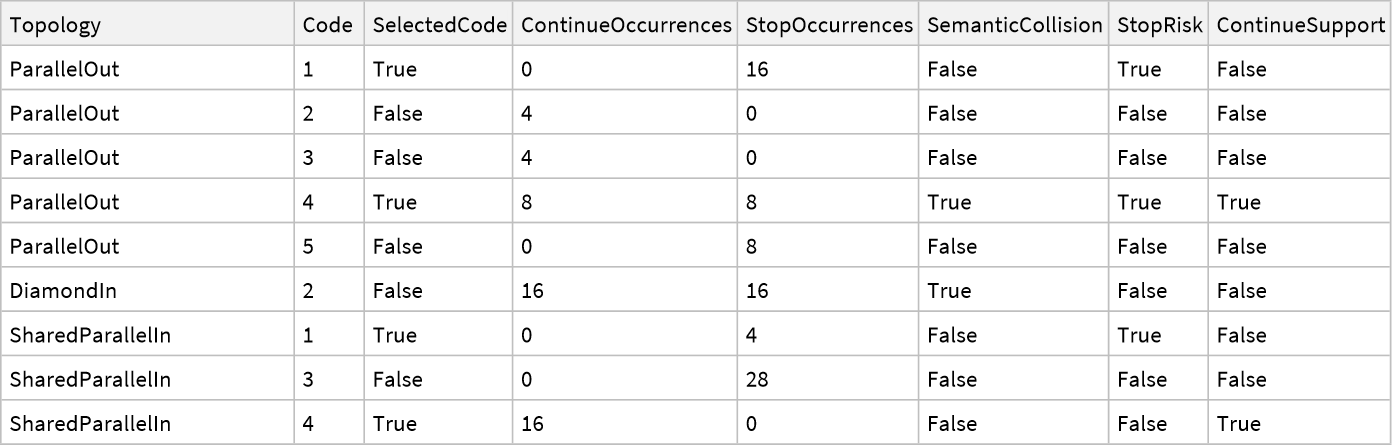

In [395]:
rawStateRows73=If[
TrueQ[preflightPass73],
Flatten[
Map[
Function[row,
Map[
Function[state,
Module[{knownPosition,knownID,knownTarget,code},
knownPosition=FirstPosition[
states64,
state,
Missing["Novel"]
];
knownID=If[
MissingQ[knownPosition],
Missing["Novel"],
First[knownPosition]
];
knownTarget=If[
IntegerQ[knownID],
stateRows70D[[knownID]]["Target"],
Missing["Novel"]
];
code=CodeState70D[
state,
frozenModel73["Params"],
frozenModel73["K"]
];
<|
"Topology"->row["Grammar"],
"Depth"->row["Depth"],
"Answer"->row["Answer"],
"Target"->row["Target"],
"StateHash"->Hash[state,"SHA256","HexString"],
"KnownStateID"->knownID,
"KnownTarget"->knownTarget,
"Code"->code,
"SelectedCode"->MemberQ[
frozenModel73["Policy"],
code
]
|>
]
],
row["States"]
]
],
testRows72
],
1
],
{}
];

codeAudit73=Flatten[
Table[
Module[{topologyRows,codes},
topologyRows=Select[
rawStateRows73,
# ["Topology"]===topology&
];
codes=Sort@DeleteDuplicates[Lookup[topologyRows,"Code"]];
Map[
Function[code,
Module[{sub,targets,continueCount,stopCount},
sub=Select[topologyRows,# ["Code"]===code&];
targets=DeleteDuplicates[Lookup[sub,"Target"]];
continueCount=Count[Lookup[sub,"Target"],"Continue"];
stopCount=Count[Lookup[sub,"Target"],"Stop"];
<|
"Topology"->topology,
"Code"->code,
"SelectedCode"->MemberQ[frozenModel73["Policy"],code],
"ContinueOccurrences"->continueCount,
"StopOccurrences"->stopCount,
"SemanticCollision"->And[
MemberQ[targets,"Continue"],
MemberQ[targets,"Stop"]
],
"StopRisk"->And[
MemberQ[frozenModel73["Policy"],code],
stopCount>0
],
"ContinueSupport"->And[
MemberQ[frozenModel73["Policy"],code],
continueCount>0
]
|>
]
],
codes
]
],
{topology,topologies72}
],
1
];

Dataset[codeAudit73]

In [398]:
stateSummary73=Map[
Function[topology,
Module[{stateSub,codeSub,knownCount,novelCount},
stateSub=Select[
rawStateRows73,
# ["Topology"]===topology&
];
codeSub=Select[
codeAudit73,
# ["Topology"]===topology&
];
knownCount=Count[Lookup[stateSub,"KnownStateID"],_Integer];
novelCount=Length[stateSub]-knownCount;
<|
"Topology"->topology,
"StateOccurrences"->Length[stateSub],
"DistinctRawStates"->Length@DeleteDuplicates[
Lookup[stateSub,"StateHash"]
],
"KnownStateOccurrences"->knownCount,
"NovelStateOccurrences"->novelCount,
"NovelStateFraction"->If[
Length[stateSub]>0,
N[novelCount/Length[stateSub]],
0.
],
"DistinctCodes"->Length[codeSub],
"SemanticCollisionCodes"->Count[
Lookup[codeSub,"SemanticCollision"],
True
],
"SelectedCollisionCodes"->Count[
codeSub,
x_/;TrueQ[x["SemanticCollision"]]&&TrueQ[x["SelectedCode"]]
],
"SelectedCodesAppearingInStop"->Count[
Lookup[codeSub,"StopRisk"],
True
],
"SelectedCodesSupportingContinue"->Count[
Lookup[codeSub,"ContinueSupport"],
True
]
|>
]
],
topologies72
];

Dataset[stateSummary73]

Dataset[{<|Topology -> ParallelOut, StateOccurrences -> 48, DistinctRawStates -> 8, 
 
>     KnownStateOccurrences -> 0, NovelStateOccurrences -> 48, NovelStateFraction -> 1., 
 
>     DistinctCodes -> 5, SemanticCollisionCodes -> 1, SelectedCollisionCodes -> 1, 
 
>     SelectedCodesAppearingInStop -> 2, SelectedCodesSupportingContinue -> 1|>, 
 
>    <|Topology -> DiamondIn, StateOccurrences -> 32, DistinctRawStates -> 1, 
 
>     KnownStateOccurrences -> 0, NovelStateOccurrences -> 32, NovelStateFraction -> 1., 
 
>     DistinctCodes -> 1, SemanticCollisionCodes -> 1, SelectedCollisionCodes -> 0, 
 
>     SelectedCodesAppearingInStop -> 0, SelectedCodesSupportingContinue -> 0|>, 
 
>    <|Topology -> SharedParallelIn, StateOccurrences -> 48, DistinctRawStates -> 6, 
 
>     KnownStateOccurrences -> 0, NovelStateOccurrences -> 48, NovelStateFraction -> 1., 
 
>     DistinctCodes -> 3, SemanticCollisionCodes -> 0, SelectedCollisionCodes -> 0, 
 
>     SelectedCodesAppearingInStop -> 1, SelectedCodesSupportingContinue -> 1|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, StateOccurrences, DistinctRawStates, 
 
>      KnownStateOccurrences, NovelStateOccurrences, NovelStateFraction, DistinctCodes, 
 
>      SemanticCollisionCodes, SelectedCollisionCodes, SelectedCodesAppearingInStop, 
 
>      SelectedCodesSupportingContinue}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 3], <||>]

In [400]:
failureExamples73=Map[
Function[row,
KeyTake[
row,
{
"Grammar",
"Depth",
"Answer",
"Target",
"Prediction",
"Codes",
"SelectedCodes",
"FailureType"
}
]
],
DeleteDuplicatesBy[
Select[caseAudit73,# ["Passed"]==0&],
{
# ["Grammar"],
# ["Answer"],
# ["Target"],
# ["FailureType"]
}&
]
];

Dataset[failureExamples73]

Dataset[{<|Grammar -> ParallelOut, Depth -> 2, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Codes -> {2}, SelectedCodes -> {}, 
 
>     FailureType -> ContinueFalseNegative|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 1, Target -> Stop, 
 
>     Prediction -> Continue, Codes -> {4, 5}, SelectedCodes -> {4}, 
 
>     FailureType -> StopFalsePositive|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Codes -> {3}, SelectedCodes -> {}, 
 
>     FailureType -> ContinueFalseNegative|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Codes -> {5, 1}, SelectedCodes -> {1}, 
 
>     FailureType -> StopFalsePositive|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 3, Target -> Stop, 
 
>     Prediction -> Continue, Codes -> {1}, SelectedCodes -> {1}, 
 
>     FailureType -> StopFalsePositive|>, 
 
>    <|Grammar -> ParallelOut, Depth -> 2, Answer -> 4, Target -> Stop, 
 
>     Prediction -> Continue, Codes -> {1, 4}, SelectedCodes -> {1, 4}, 
 
>     FailureType -> StopFalsePositive|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 1, Target -> Continue, 
 
>     Prediction -> Stop, Codes -> {2}, SelectedCodes -> {}, 
 
>     FailureType -> ContinueFalseNegative|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 2, Target -> Continue, 
 
>     Prediction -> Stop, Codes -> {2}, SelectedCodes -> {}, 
 
>     FailureType -> ContinueFalseNegative|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 3, Target -> Continue, 
 
>     Prediction -> Stop, Codes -> {2}, SelectedCodes -> {}, 
 
>     FailureType -> ContinueFalseNegative|>, 
 
>    <|Grammar -> DiamondIn, Depth -> 2, Answer -> 4, Target -> Continue, 
 
>     Prediction -> Stop, Codes -> {2}, SelectedCodes -> {}, 
 
>     FailureType -> ContinueFalseNegative|>, 
 
>    <|Grammar -> SharedParallelIn, Depth -> 2, Answer -> 2, Target -> Stop, 
 
>     Prediction -> Continue, Codes -> {1, 3}, SelectedCodes -> {1}, 
 
>     FailureType -> StopFalsePositive|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Grammar, Depth, Answer, Target, Prediction, 
 
>      Codes, SelectedCodes, FailureType}, 
 
>     {TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>        SharedParallelIn]], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>      TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], TypeSystem`AnyLength], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], TypeSystem`AnyLength], 
 
>      TypeSystem`Atom[TypeSystem`Enumeration[ContinueFalseNegative, StopFalsePositive]]}
 
>      ], 11], <||>]

Dataset[{<|Stage -> S73, Name -> TopologyFailureMechanismAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, ModelChanged -> False, RetuningAllowed -> False, 
 
>     PreflightPassed -> True, FrozenModel -> 
 
>      <|Params -> {0, -1, 1, -1, -1, 0}, K -> 5, Policy -> {1, 4}|>, 
 
>     S72ProtocolHash -> 
 
>      9655a29d19e0069fd40b340f33cdf72bc729a712aa2e485423f640a3d6335feb, 
 
>     CasesAudited -> 96, AccuracyByTopology -> 
 
>      <|ParallelOut -> 0.25, DiamondIn -> 0.5, SharedParallelIn -> 0.875|>, 
 
>     FailureCountsByTopology -> 
 
>      <|ParallelOut -> 
 
>        <|ContinueFalseNegative -> 8, StopFalsePositive -> 16, Correct -> 8|>, 
 
>       DiamondIn -> <|ContinueFalseNegative -> 16, Correct -> 16|>, 
 
>       SharedParallelIn -> <|Correct -> 28, StopFalsePositive -> 4|>|>, 
 
>     StateMechanismSummary -> 
 
>      <|ParallelOut -> 
 
>        <|StateOccurrences -> 48, DistinctRawStates -> 8, KnownStateOccurrences -> 0, 
 
>         NovelStateOccurrences -> 48, NovelStateFraction -> 1., DistinctCodes -> 5, 
 
>         SemanticCollisionCodes -> 1, SelectedCollisionCodes -> 1, 
 
>         SelectedCodesAppearingInStop -> 2, SelectedCodesSupportingContinue -> 1|>, 
 
>       DiamondIn -> 
 
>        <|StateOccurrences -> 32, DistinctRawStates -> 1, KnownStateOccurrences -> 0, 
 
>         NovelStateOccurrences -> 32, NovelStateFraction -> 1., DistinctCodes -> 1, 
 
>         SemanticCollisionCodes -> 1, SelectedCollisionCodes -> 0, 
 
>         SelectedCodesAppearingInStop -> 0, SelectedCodesSupportingContinue -> 0|>, 
 
>       SharedParallelIn -> 
 
>        <|StateOccurrences -> 48, DistinctRawStates -> 6, KnownStateOccurrences -> 0, 
 
>         NovelStateOccurrences -> 48, NovelStateFraction -> 1., DistinctCodes -> 3, 
 
>         SemanticCollisionCodes -> 0, SelectedCollisionCodes -> 0, 
 
>         SelectedCodesAppearingInStop -> 1, SelectedCodesSupportingContinue -> 1|>|>|>}\
 
>    , TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, CoreTCCTChanged, 
 
>      ModelChanged, RetuningAllowed, PreflightPassed, FrozenModel, S72ProtocolHash, 
 
>      CasesAudited, AccuracyByTopology, FailureCountsByTopology, StateMechanismSummary}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Struct[{Params, K, Policy}, 
 
>       {TypeSystem`Vector[TypeSystem`Atom[Integer], 6], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Vector[TypeSystem`Atom[Integer], 2]}], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>         DiamondIn, ParallelOut, SharedParallelIn]], TypeSystem`Atom[Real], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], 
 
>       TypeSystem`Assoc[TypeSystem`AnyType, TypeSystem`Atom[Integer], 
 
>        TypeSystem`AnyLength], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], 
 
>       TypeSystem`Struct[{StateOccurrences, DistinctRawStates, KnownStateOccurrences, 
 
>         NovelStateOccurrences, NovelStateFraction, DistinctCodes, 
 
>         SemanticCollisionCodes, SelectedCollisionCodes, SelectedCodesAppearingInStop, 
 
>         SelectedCodesSupportingContinue}, 
 
>        {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[Integer], TypeSystem`Atom[Real], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[Integer]}], 3]}], 1], <||>]
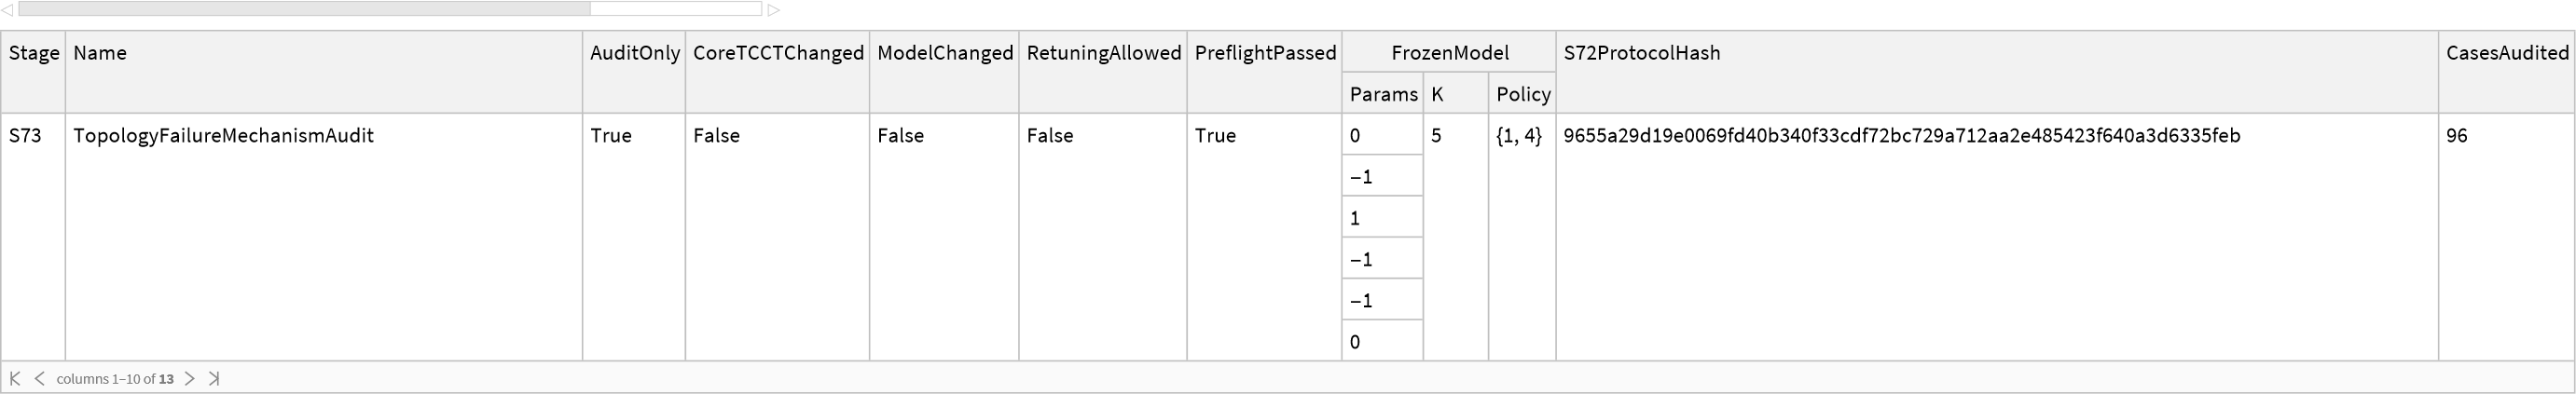

In [402]:
failureCounts73=AssociationMap[
Function[topology,
Counts[
Lookup[
Select[caseAudit73,# ["Grammar"]===topology&],
"FailureType"
]
]
],
topologies72
];

accuracyByTopology73=AssociationMap[
Function[topology,
N@Mean[
Lookup[
Select[caseAudit73,# ["Grammar"]===topology&],
"Passed"
]
]
],
topologies72
];

auditCert73=<|
"Stage"->"S73",
"Name"->"TopologyFailureMechanismAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"ModelChanged"->False,
"RetuningAllowed"->False,
"PreflightPassed"->preflightPass73,
"FrozenModel"->frozenModel73,
"S72ProtocolHash"->protocolHash72,
"CasesAudited"->Length[caseAudit73],
"AccuracyByTopology"->accuracyByTopology73,
"FailureCountsByTopology"->failureCounts73,
"StateMechanismSummary"->AssociationThread[
topologies72,
KeyDrop[stateSummary73,"Topology"]
]
|>;

Dataset[{auditCert73}]

Legended[-Graphics-, Placed[BarLegend[{Blend[{{0., RGBColor[0.260487, 0.356, 0.891569]}, 
 
>         {0.166667, RGBColor[0.230198, 0.499962, 0.848188]}, 
 
>         {0.333333, RGBColor[0.392401, 0.658762, 0.797589]}, 
 
>         {0.499999, RGBColor[0.964837, 0.982332, 0.98988]}, 
 
>         {0.5, RGBColor[1., 1., 1.]}, 
 
>         {0.500001, RGBColor[0.95735, 0.957281, 0.896269]}, 
 
>         {0.666667, RGBColor[0.913252, 0.790646, 0.462837]}, 
 
>         {0.833333, RGBColor[0.860243, 0.558831, 0.00695811]}, 
 
                                                  1
>         {1., RGBColor[1., 0.42, 0.]}}, #1] & , {-, 1}}, LabelStyle -> {}, 
                                                  2
 
                                                      576
>     LegendLayout -> Column, LegendMarkerSize -> -----------, 
                                                  GoldenRatio
 
>     Ticks -> {{0.625, 2.}, {0.75, 4.}, {0.875, 6.}, {0.5, 0.}, {1., 8.}}, 
 
>     PinningPoint -> 0.5, SmoothRange -> False, Charting`TickSide -> Right, 
 
>     ColorFunctionScaling -> False], After, Identity]]
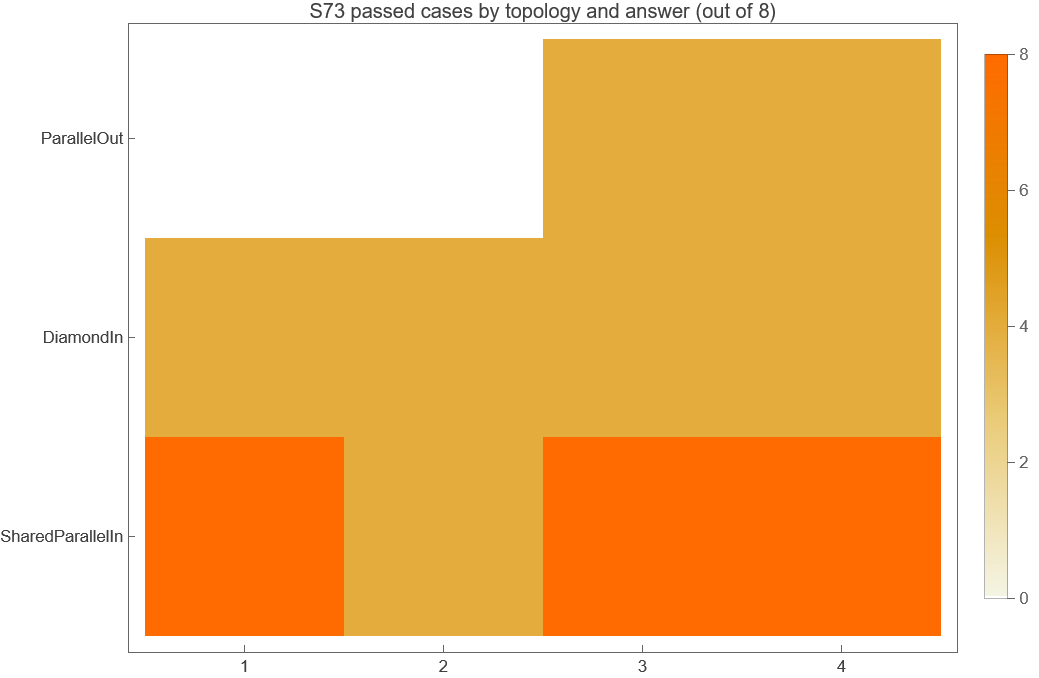

In [406]:
scoreMatrix73=Table[
Total[
Lookup[
Select[
caseAudit73,
# ["Grammar"]===topology&&# ["Answer"]===answer&
],
"Passed"
]
],
{topology,topologies72},
{answer,answers72}
];

MatrixPlot[
scoreMatrix73,
PlotLegends->Automatic,
PlotLabel->"S73 passed cases by topology and answer (out of 8)",
FrameTicks -> {
  {
    MapIndexed[{First[#2], #1} &, topologies72],
    None
  },
  {
    MapIndexed[{First[#2], #1} &, answers72],
    None
  }
},
ImageSize->Large
]

# S74 — Layer Attribution Audit

This audit keeps the frozen model unchanged and separates three possible failure layers: raw radius-limited representation, latent compression, and frozen-policy semantic alignment.

## Interpretation

For each topology and radius 2–4, the notebook computes: 

- a label-informed raw-state oracle ceiling;
- a label-informed latent-code oracle ceiling;
- the actual score of the unchanged frozen policy.

The oracle scores are diagnostic ceilings only and are never used for selection or retuning.

Dataset[{<|Stage -> S74, Name -> LayerAttributionAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, ModelChanged -> False, RetuningAllowed -> False, 
 
>     NewModelSearch -> False, ModelMatchesS71S72S73 -> True, S73ResultMatches -> True, 
 
>     RadiiAudited -> {2, 3, 4}, HigherRadiusScoresAreDiagnosticOnly -> True, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, 
 
>      AuditOnly, CoreTCCTChanged, ModelChanged, RetuningAllowed, NewModelSearch, 
 
>      ModelMatchesS71S72S73, S73ResultMatches, RadiiAudited, 
 
>      HigherRadiusScoresAreDiagnosticOnly, PreflightPassed}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
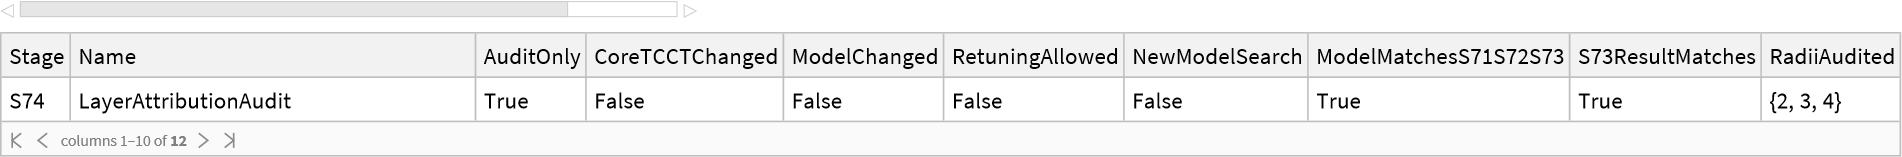

In [416]:
ClearAll["Global`*74"];

frozenModel74=<|
"Params"->{0,-1,1,-1,-1,0},
"K"->5,
"Policy"->{1,4}
|>;

radii74={2,3,4};

expectedAccuracy73=<|
"ParallelOut"->0.25,
"DiamondIn"->0.5,
"SharedParallelIn"->0.875
|>;

modelLock74=SameQ[
frozenModel74,
frozenModel73,
frozenModel72,
frozen71
];

s73ResultLock74=And[
TrueQ[preflightPass73],
SameQ[auditCert73["CasesAudited"],96],
And@@MapThread[
Abs[#1-#2]<10^-12&,
{
Lookup[auditCert73["AccuracyByTopology"],topologies72],
Lookup[expectedAccuracy73,topologies72]
}
]
];

preflightPass74=And[
modelLock74,
s73ResultLock74
];

preflight74=<|
"Stage"->"S74",
"Name"->"LayerAttributionAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"ModelChanged"->False,
"RetuningAllowed"->False,
"NewModelSearch"->False,
"ModelMatchesS71S72S73"->modelLock74,
"S73ResultMatches"->s73ResultLock74,
"RadiiAudited"->radii74,
"HigherRadiusScoresAreDiagnosticOnly"->True,
"PreflightPassed"->preflightPass74
|>;

Dataset[{preflight74}]

In [425]:
ClearAll[
StateKey74,
BuildRadiusRows74,
LayerMetrics74,
FrozenPolicyScore74,
LayerAudit74
];

StateKey74[state_]:=Hash[
state,
"SHA256",
"HexString"
];

BuildRadiusRows74[
topology_String,
radius_Integer
]:=Flatten[
Table[
Module[{states,rawKeys,codes},
states=DecisionStates64[
Case72[topology,depth,answer,target],
radius
];
rawKeys=DeleteDuplicates[StateKey74/@states];
codes=DeleteDuplicates[
CodeState70D[
#,
frozenModel74["Params"],
frozenModel74["K"]
]&/@states
];
<|
"Topology"->topology,
"Radius"->radius,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"RawKeys"->rawKeys,
"Codes"->codes
|>
],
{depth,depths72},
{answer,answers72},
{target,targets72}
],
2
];

LayerMetrics74[
rows_List,
field_String
]:=Module[
{continueRows,stopRows,continueUniverse,stopUniverse,
shared,oracleSelected,score},
continueRows=Select[rows,# ["Target"]==="Continue"&];
stopRows=Select[rows,# ["Target"]==="Stop"&];
continueUniverse=Union@@Lookup[continueRows,field];
stopUniverse=Union@@Lookup[stopRows,field];
shared=Intersection[
continueUniverse,
stopUniverse
];
oracleSelected=Complement[
continueUniverse,
stopUniverse
];
score=Total[
Map[
Function[row,
Module[{prediction,truth},
prediction=AnyTrue[
row[field],
MemberQ[oracleSelected,#]&
];
truth=row["Target"]==="Continue";
Boole[SameQ[prediction,truth]]
]
],
rows
]
];
<|
"ContinueUniverse"->continueUniverse,
"StopUniverse"->stopUniverse,
"SharedSymbols"->shared,
"OracleSelected"->oracleSelected,
"DistinctSymbols"->Length@Union[
continueUniverse,
stopUniverse
],
"SharedCount"->Length[shared],
"OracleSelectedCount"->Length[oracleSelected],
"OracleScore"->score
|>
];

FrozenPolicyScore74[rows_List]:=Total[
Map[
Function[row,
Module[{prediction,truth},
prediction=AnyTrue[
row["Codes"],
MemberQ[frozenModel74["Policy"],#]&
];
truth=row["Target"]==="Continue";
Boole[SameQ[prediction,truth]]
]
],
rows
]
];

LayerAudit74[
topology_String,
radius_Integer
]:=Module[
{rows,rawMetrics,latentMetrics,frozenScore,failureLayer},
rows=BuildRadiusRows74[topology,radius];
rawMetrics=LayerMetrics74[rows,"RawKeys"];
latentMetrics=LayerMetrics74[rows,"Codes"];
frozenScore=FrozenPolicyScore74[rows];
failureLayer=Which[
rawMetrics["OracleScore"]<32,
"OuterRawRepresentation",
latentMetrics["OracleScore"]<32,
"LatentEncoderCompression",
frozenScore<32,
"FrozenPolicySemanticAlignment",
True,
"None"
];
<|
"Topology"->topology,
"Radius"->radius,
"Cases"->Length[rows],
"RawDistinctStates"->rawMetrics["DistinctSymbols"],
"RawSharedStates"->rawMetrics["SharedCount"],
"RawOracleSelectedStates"->rawMetrics["OracleSelectedCount"],
"RawOracleScore"->rawMetrics["OracleScore"],
"LatentDistinctCodes"->latentMetrics["DistinctSymbols"],
"LatentSharedCodes"->latentMetrics["SharedCount"],
"LatentOracleSelectedCodes"->latentMetrics["OracleSelectedCount"],
"LatentOracleScore"->latentMetrics["OracleScore"],
"FrozenPolicyScore"->frozenScore,
"FirstFailureLayer"->failureLayer
|>
];

In [431]:
layerAuditRows74=If[
TrueQ[preflightPass74],
Flatten[
Table[
LayerAudit74[topology,radius],
{topology,topologies72},
{radius,radii74}
],
1
],
{}
];

Dataset[layerAuditRows74]

Dataset[{<|Topology -> ParallelOut, Radius -> 2, Cases -> 32, RawDistinctStates -> 8, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 4, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 5, LatentSharedCodes -> 1, LatentOracleSelectedCodes -> 2, 
 
>     LatentOracleScore -> 24, FrozenPolicyScore -> 8, 
 
>     FirstFailureLayer -> LatentEncoderCompression|>, 
 
>    <|Topology -> ParallelOut, Radius -> 3, Cases -> 32, RawDistinctStates -> 8, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 4, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 4, LatentSharedCodes -> 2, LatentOracleSelectedCodes -> 1, 
 
>     LatentOracleScore -> 24, FrozenPolicyScore -> 8, 
 
>     FirstFailureLayer -> LatentEncoderCompression|>, 
 
>    <|Topology -> ParallelOut, Radius -> 4, Cases -> 32, RawDistinctStates -> 8, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 4, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 5, LatentSharedCodes -> 3, LatentOracleSelectedCodes -> 1, 
 
>     LatentOracleScore -> 20, FrozenPolicyScore -> 8, 
 
>     FirstFailureLayer -> LatentEncoderCompression|>, 
 
>    <|Topology -> DiamondIn, Radius -> 2, Cases -> 32, RawDistinctStates -> 1, 
 
>     RawSharedStates -> 1, RawOracleSelectedStates -> 0, RawOracleScore -> 16, 
 
>     LatentDistinctCodes -> 1, LatentSharedCodes -> 1, LatentOracleSelectedCodes -> 0, 
 
>     LatentOracleScore -> 16, FrozenPolicyScore -> 16, 
 
>     FirstFailureLayer -> OuterRawRepresentation|>, 
 
>    <|Topology -> DiamondIn, Radius -> 3, Cases -> 32, RawDistinctStates -> 2, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 1, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 2, LatentSharedCodes -> 0, LatentOracleSelectedCodes -> 1, 
 
>     LatentOracleScore -> 32, FrozenPolicyScore -> 32, FirstFailureLayer -> None|>, 
 
>    <|Topology -> DiamondIn, Radius -> 4, Cases -> 32, RawDistinctStates -> 8, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 4, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 4, LatentSharedCodes -> 0, LatentOracleSelectedCodes -> 2, 
 
>     LatentOracleScore -> 32, FrozenPolicyScore -> 24, 
 
>     FirstFailureLayer -> FrozenPolicySemanticAlignment|>, 
 
>    <|Topology -> SharedParallelIn, Radius -> 2, Cases -> 32, RawDistinctStates -> 6, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 1, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 3, LatentSharedCodes -> 0, LatentOracleSelectedCodes -> 1, 
 
>     LatentOracleScore -> 32, FrozenPolicyScore -> 28, 
 
>     FirstFailureLayer -> FrozenPolicySemanticAlignment|>, 
 
>    <|Topology -> SharedParallelIn, Radius -> 3, Cases -> 32, RawDistinctStates -> 12, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 4, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 4, LatentSharedCodes -> 1, LatentOracleSelectedCodes -> 1, 
 
>     LatentOracleScore -> 24, FrozenPolicyScore -> 12, 
 
>     FirstFailureLayer -> LatentEncoderCompression|>, 
 
>    <|Topology -> SharedParallelIn, Radius -> 4, Cases -> 32, RawDistinctStates -> 12, 
 
>     RawSharedStates -> 0, RawOracleSelectedStates -> 4, RawOracleScore -> 32, 
 
>     LatentDistinctCodes -> 5, LatentSharedCodes -> 2, LatentOracleSelectedCodes -> 0, 
 
>     LatentOracleScore -> 16, FrozenPolicyScore -> 4, 
 
>     FirstFailureLayer -> LatentEncoderCompression|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, Radius, Cases, RawDistinctStates, 
 
>      RawSharedStates, RawOracleSelectedStates, RawOracleScore, LatentDistinctCodes, 
 
>      LatentSharedCodes, LatentOracleSelectedCodes, LatentOracleScore, 
 
>      FrozenPolicyScore, FirstFailureLayer}, 
 
>     {TypeSystem`Atom[TypeSystem`Enumeration[DiamondIn, ParallelOut, 
 
>        SharedParallelIn]], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Inte

Dataset[{<|Topology -> ParallelOut, S72FrozenScore -> 8, Radius2RawOracle -> 32, 
 
>     Radius2LatentOracle -> 24, Radius2FailureLayer -> LatentEncoderCompression, 
 
>     Radius3RawOracle -> 32, Radius3LatentOracle -> 24, Radius3FrozenPolicy -> 8, 
 
>     Radius4RawOracle -> 32, Radius4LatentOracle -> 20, Radius4FrozenPolicy -> 8, 
 
>     MinimalRawPerfectRadius -> 2, 
 
>     MinimalLatentPerfectRadius -> Missing[NotPerfectThroughRadius4]|>, 
 
>    <|Topology -> DiamondIn, S72FrozenScore -> 16, Radius2RawOracle -> 16, 
 
>     Radius2LatentOracle -> 16, Radius2FailureLayer -> OuterRawRepresentation, 
 
>     Radius3RawOracle -> 32, Radius3LatentOracle -> 32, Radius3FrozenPolicy -> 32, 
 
>     Radius4RawOracle -> 32, Radius4LatentOracle -> 32, Radius4FrozenPolicy -> 24, 
 
>     MinimalRawPerfectRadius -> 3, MinimalLatentPerfectRadius -> 3|>, 
 
>    <|Topology -> SharedParallelIn, S72FrozenScore -> 28, Radius2RawOracle -> 32, 
 
>     Radius2LatentOracle -> 32, Radius2FailureLayer -> FrozenPolicySemanticAlignment, 
 
>     Radius3RawOracle -> 32, Radius3LatentOracle -> 24, Radius3FrozenPolicy -> 12, 
 
>     Radius4RawOracle -> 32, Radius4LatentOracle -> 16, Radius4FrozenPolicy -> 4, 
 
>     MinimalRawPerfectRadius -> 2, MinimalLatentPerfectRadius -> 2|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, S72FrozenScore, Radius2RawOracle, 
 
>      Radius2LatentOracle, Radius2FailureLayer, Radius3RawOracle, Radius3LatentOracle, 
 
>      Radius3FrozenPolicy, Radius4RawOracle, Radius4LatentOracle, Radius4FrozenPolicy, 
 
>      MinimalRawPerfectRadius, MinimalLatentPerfectRadius}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer]}], 3], <||>]
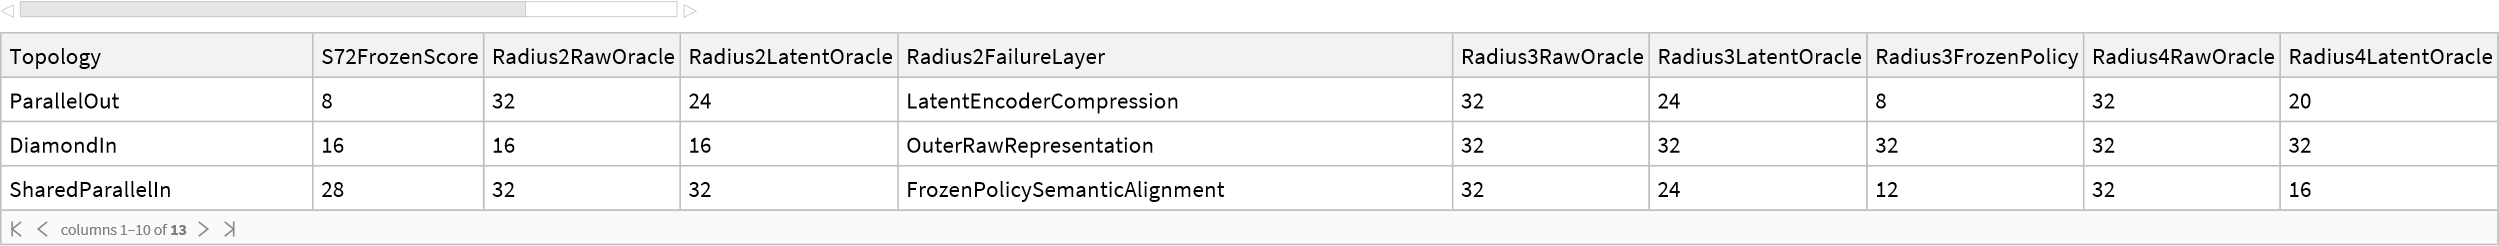

In [433]:
ClearAll[MinimalPerfectRadius74];

MinimalPerfectRadius74[
topology_String,
scoreField_String
]:=Module[{matching},
matching=Select[
layerAuditRows74,
# ["Topology"]===topology&&# [scoreField]===32&
];
If[
Length[matching]>0,
Min[Lookup[matching,"Radius"]],
Missing["NotPerfectThroughRadius4"]
]
];

attributionSummary74=Map[
Function[topology,
Module[{radius2,radius3,radius4},
radius2=SelectFirst[
layerAuditRows74,
# ["Topology"]===topology&&# ["Radius"]===2&
];
radius3=SelectFirst[
layerAuditRows74,
# ["Topology"]===topology&&# ["Radius"]===3&
];
radius4=SelectFirst[
layerAuditRows74,
# ["Topology"]===topology&&# ["Radius"]===4&
];
<|
"Topology"->topology,
"S72FrozenScore"->radius2["FrozenPolicyScore"],
"Radius2RawOracle"->radius2["RawOracleScore"],
"Radius2LatentOracle"->radius2["LatentOracleScore"],
"Radius2FailureLayer"->radius2["FirstFailureLayer"],
"Radius3RawOracle"->radius3["RawOracleScore"],
"Radius3LatentOracle"->radius3["LatentOracleScore"],
"Radius3FrozenPolicy"->radius3["FrozenPolicyScore"],
"Radius4RawOracle"->radius4["RawOracleScore"],
"Radius4LatentOracle"->radius4["LatentOracleScore"],
"Radius4FrozenPolicy"->radius4["FrozenPolicyScore"],
"MinimalRawPerfectRadius"->MinimalPerfectRadius74[
topology,
"RawOracleScore"
],
"MinimalLatentPerfectRadius"->MinimalPerfectRadius74[
topology,
"LatentOracleScore"
]
|>
]
],
topologies72
];

Dataset[attributionSummary74]

In [437]:
radiusScoreSummary74=Map[
Function[topology,
Module[{sub},
sub=Select[
layerAuditRows74,
# ["Topology"]===topology&
];
<|
"Topology"->topology,
"RawOracleByRadius"->AssociationThread[
Lookup[sub,"Radius"],
Lookup[sub,"RawOracleScore"]
],
"LatentOracleByRadius"->AssociationThread[
Lookup[sub,"Radius"],
Lookup[sub,"LatentOracleScore"]
],
"FrozenPolicyByRadius"->AssociationThread[
Lookup[sub,"Radius"],
Lookup[sub,"FrozenPolicyScore"]
],
"FailureLayerByRadius"->AssociationThread[
Lookup[sub,"Radius"],
Lookup[sub,"FirstFailureLayer"]
]
|>
]
],
topologies72
];

Dataset[radiusScoreSummary74]

Dataset[{<|Topology -> ParallelOut, RawOracleByRadius -> <|2 -> 32, 3 -> 32, 4 -> 32|>, 
 
>     LatentOracleByRadius -> <|2 -> 24, 3 -> 24, 4 -> 20|>, 
 
>     FrozenPolicyByRadius -> <|2 -> 8, 3 -> 8, 4 -> 8|>, 
 
>     FailureLayerByRadius -> 
 
>      <|2 -> LatentEncoderCompression, 3 -> LatentEncoderCompression, 
 
>       4 -> LatentEncoderCompression|>|>, 
 
>    <|Topology -> DiamondIn, RawOracleByRadius -> <|2 -> 16, 3 -> 32, 4 -> 32|>, 
 
>     LatentOracleByRadius -> <|2 -> 16, 3 -> 32, 4 -> 32|>, 
 
>     FrozenPolicyByRadius -> <|2 -> 16, 3 -> 32, 4 -> 24|>, 
 
>     FailureLayerByRadius -> 
 
>      <|2 -> OuterRawRepresentation, 3 -> None, 4 -> FrozenPolicySemanticAlignment|>|>, 
 
>    <|Topology -> SharedParallelIn, RawOracleByRadius -> <|2 -> 32, 3 -> 32, 4 -> 32|>, 
 
>     LatentOracleByRadius -> <|2 -> 32, 3 -> 24, 4 -> 16|>, 
 
>     FrozenPolicyByRadius -> <|2 -> 28, 3 -> 12, 4 -> 4|>, 
 
>     FailureLayerByRadius -> 
 
>      <|2 -> FrozenPolicySemanticAlignment, 3 -> LatentEncoderCompression, 
 
>       4 -> LatentEncoderCompression|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, RawOracleByRadius, 
 
>      LatentOracleByRadius, FrozenPolicyByRadius, FailureLayerByRadius}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Assoc[TypeSystem`Atom[Integer], 
 
>       TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`AnyType, 3]}], 3], <||>]

Dataset[{<|Stage -> S74, Name -> LayerAttributionAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, ModelChanged -> False, RetuningAllowed -> False, 
 
>     PreflightPassed -> True, FrozenModel -> 
 
>      <|Params -> {0, -1, 1, -1, -1, 0}, K -> 5, Policy -> {1, 4}|>, 
 
>     RadiiAudited -> {2, 3, 4}, HigherRadiusScoresAreDiagnosticOnly -> True, 
 
>     CasesPerTopologyPerRadius -> 32, 
 
>     AttributionSummary -> 
 
>      <|ParallelOut -> 
 
>        <|S72FrozenScore -> 8, Radius2RawOracle -> 32, Radius2LatentOracle -> 24, 
 
>         Radius2FailureLayer -> LatentEncoderCompression, Radius3RawOracle -> 32, 
 
>         Radius3LatentOracle -> 24, Radius3FrozenPolicy -> 8, Radius4RawOracle -> 32, 
 
>         Radius4LatentOracle -> 20, Radius4FrozenPolicy -> 8, 
 
>         MinimalRawPerfectRadius -> 2, 
 
>         MinimalLatentPerfectRadius -> Missing[NotPerfectThroughRadius4]|>, 
 
>       DiamondIn -> 
 
>        <|S72FrozenScore -> 16, Radius2RawOracle -> 16, Radius2LatentOracle -> 16, 
 
>         Radius2FailureLayer -> OuterRawRepresentation, Radius3RawOracle -> 32, 
 
>         Radius3LatentOracle -> 32, Radius3FrozenPolicy -> 32, Radius4RawOracle -> 32, 
 
>         Radius4LatentOracle -> 32, Radius4FrozenPolicy -> 24, 
 
>         MinimalRawPerfectRadius -> 3, MinimalLatentPerfectRadius -> 3|>, 
 
>       SharedParallelIn -> 
 
>        <|S72FrozenScore -> 28, Radius2RawOracle -> 32, Radius2LatentOracle -> 32, 
 
>         Radius2FailureLayer -> FrozenPolicySemanticAlignment, Radius3RawOracle -> 32, 
 
>         Radius3LatentOracle -> 24, Radius3FrozenPolicy -> 12, Radius4RawOracle -> 32, 
 
>         Radius4LatentOracle -> 16, Radius4FrozenPolicy -> 4, 
 
>         MinimalRawPerfectRadius -> 2, MinimalLatentPerfectRadius -> 2|>|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, CoreTCCTChanged, 
 
>      ModelChanged, RetuningAllowed, PreflightPassed, FrozenModel, RadiiAudited, 
 
>      HigherRadiusScoresAreDiagnosticOnly, CasesPerTopologyPerRadius, 
 
>      AttributionSummary}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Struct[{Params, K, Policy}, 
 
>       {TypeSystem`Vector[TypeSystem`Atom[Integer], 6], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Vector[TypeSystem`Atom[Integer], 2]}], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 3], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], 
 
>       TypeSystem`Struct[{S72FrozenScore, Radius2RawOracle, Radius2LatentOracle, 
 
>         Radius2FailureLayer, Radius3RawOracle, Radius3LatentOracle, 
 
>         Radius3FrozenPolicy, Radius4RawOracle, Radius4LatentOracle, 
 
>         Radius4FrozenPolicy, MinimalRawPerfectRadius, MinimalLatentPerfectRadius}, 
 
>        {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}]\
 
>        , 3]}], 1], <||>]
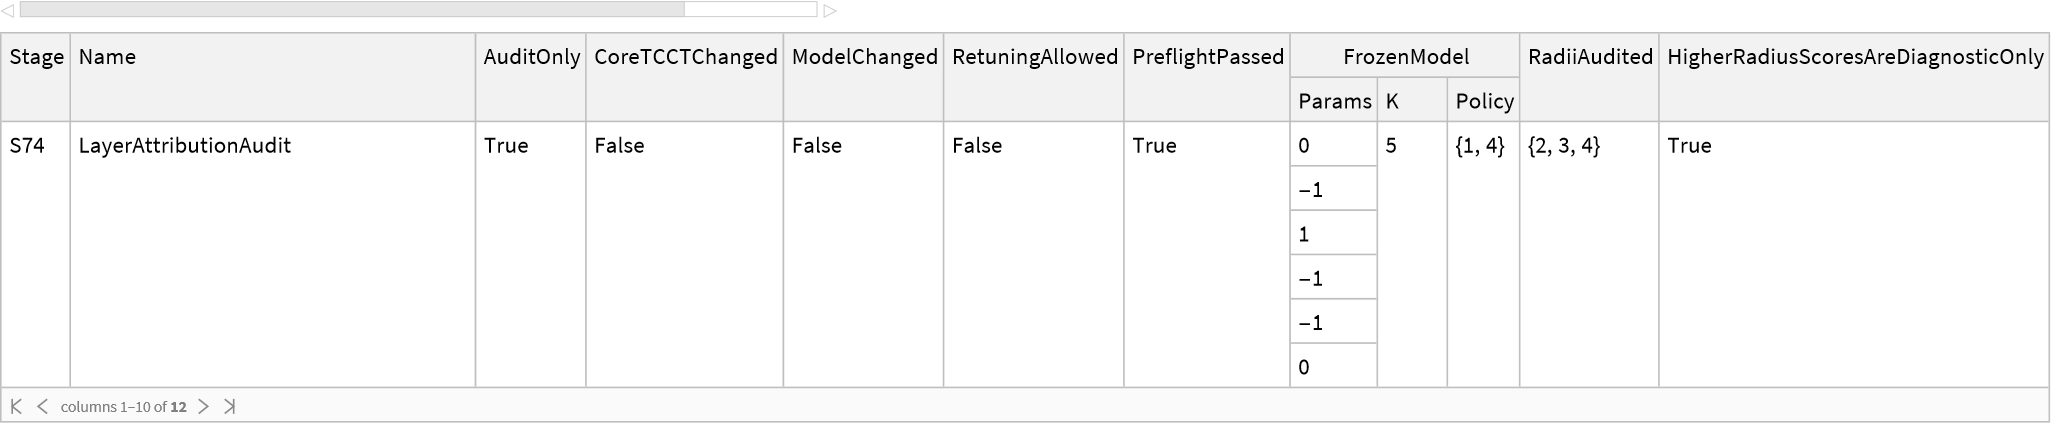

In [439]:
cert74=<|
"Stage"->"S74",
"Name"->"LayerAttributionAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"ModelChanged"->False,
"RetuningAllowed"->False,
"PreflightPassed"->preflightPass74,
"FrozenModel"->frozenModel74,
"RadiiAudited"->radii74,
"HigherRadiusScoresAreDiagnosticOnly"->True,
"CasesPerTopologyPerRadius"->32,
"AttributionSummary"->AssociationThread[
topologies72,
KeyDrop[attributionSummary74,"Topology"]
]
|>;

Dataset[{cert74}]

# S75 — Multiscale Semantic-Preserving Encoder

S75 is a new representation branch. It does not alter the frozen S71–S74 checkpoints or the TCCT propagation mechanism. It pairs radius-2 and radius-3 codes and adds parent/child cardinality terms.

## Selection protocol

The policy is derived only from S59 + ChainIn training cases at depths 2 and 5. Held depths, legacy topologies, and the already-observed S72 battery are used for validation and ranking. S75 is not a blind test. No S76 topology is evaluated here.

Dataset[{<|Stage -> S75, Name -> MultiscaleSemanticEncoder, CoreTCCTChanged -> False, 
 
>     OriginalFrozenModelChanged -> False, NewRepresentationBranch -> True, 
 
>     Representation -> PairedRadius2Radius3WithParentChildCardinality, Radii -> {2, 3}, 
 
>     K -> 5, ParameterCount -> 8, ParameterAlphabet -> {-1, 0, 1}, 
 
>     ParameterCandidates -> 6561, PolicyDerivedFromTrainingOnly -> True, 
 
>     TrainingGrammars -> {S59, ChainIn}, TrainingDepths -> {2, 5}, 
 
>     HeldoutDepths -> {9, 15}, LegacyValidation -> {SharedMerge, ParallelIn}, 
 
>     S72UsedAsValidation -> True, S75IsBlindTest -> False, 
 
>     RetuningOriginalModel -> False, S76ReservedForFutureBlindTest -> True, 
 
>     OriginalModelMatchesS71ThroughS74 -> True, S74ResultMatches -> True, 
 
>     PreflightPassed -> True, ProtocolHash -> 
 
>      0831799824137abacf8d196fc08689f6eacc325a5c4a04643c6051bbd71ea366|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 24], 
 
>    1], <||>]
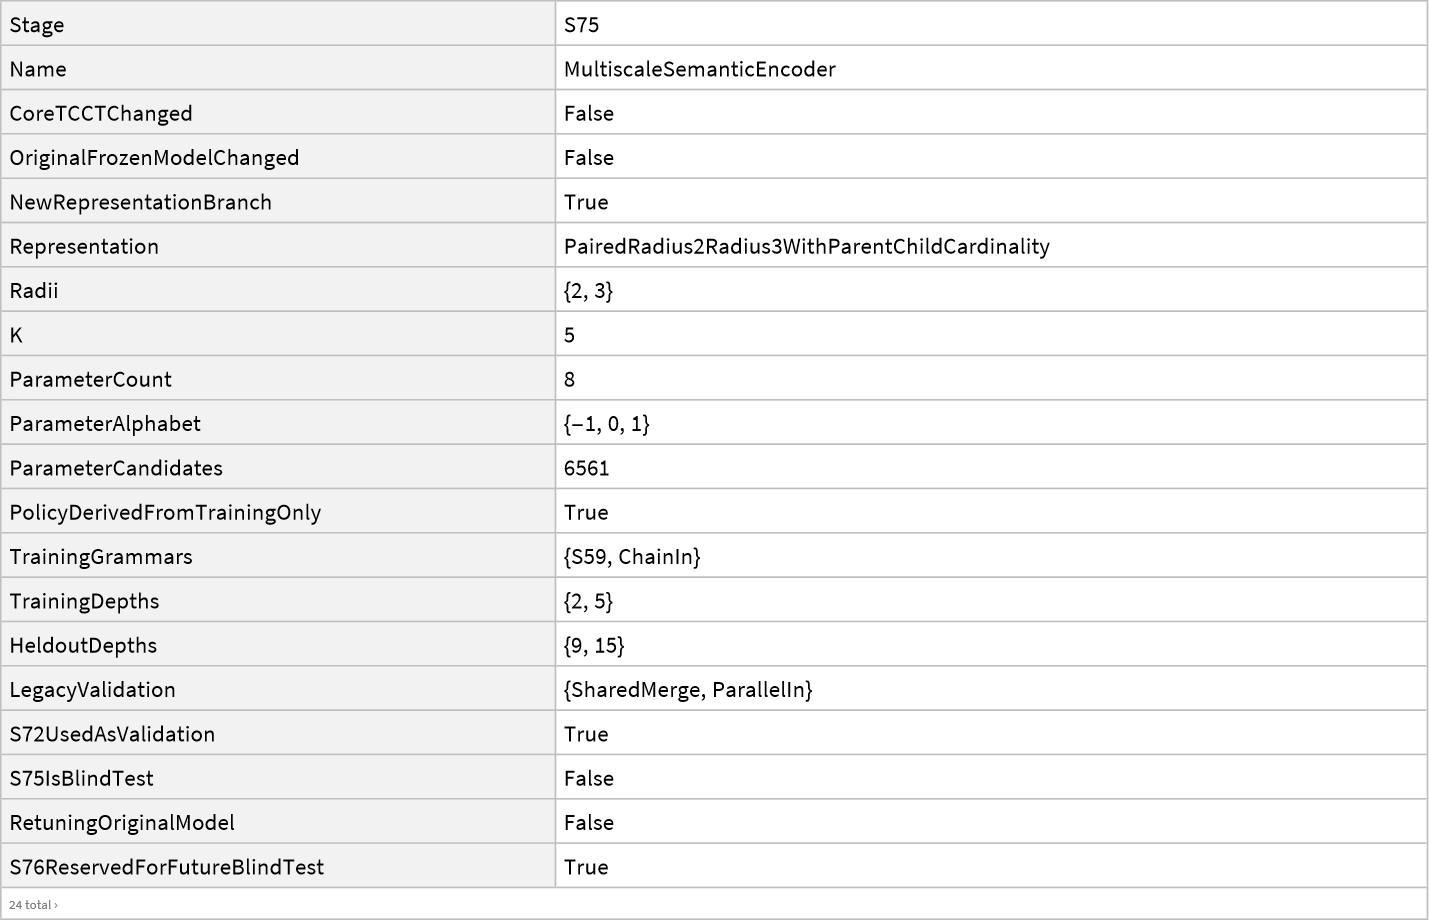

In [449]:
ClearAll["Global`*75"];

originalFrozenModel75=<|
"Params"->{0,-1,1,-1,-1,0},
"K"->5,
"Policy"->{1,4}
|>;

originalModelLock75=SameQ[
originalFrozenModel75,
frozenModel74,
frozenModel73,
frozenModel72,
frozen71
];

s74ResultLock75=And[
TrueQ[preflightPass74],
TrueQ[cert74["PreflightPassed"]],
SameQ[cert74["CasesPerTopologyPerRadius"],32]
];

preflightPass75=And[
originalModelLock75,
s74ResultLock75
];

protocol75=<|
"Stage"->"S75",
"Name"->"MultiscaleSemanticEncoder",
"CoreTCCTChanged"->False,
"OriginalFrozenModelChanged"->False,
"NewRepresentationBranch"->True,
"Representation"->"PairedRadius2Radius3WithParentChildCardinality",
"Radii"->{2,3},
"K"->5,
"ParameterCount"->8,
"ParameterAlphabet"->{-1,0,1},
"ParameterCandidates"->6561,
"PolicyDerivedFromTrainingOnly"->True,
"TrainingGrammars"->{"S59","ChainIn"},
"TrainingDepths"->{2,5},
"HeldoutDepths"->{9,15},
"LegacyValidation"->{"SharedMerge","ParallelIn"},
"S72UsedAsValidation"->True,
"S75IsBlindTest"->False,
"RetuningOriginalModel"->False,
"S76ReservedForFutureBlindTest"->True
|>;

protocolHash75=Hash[
Normal[protocol75],
"SHA256",
"HexString"
];

Dataset[{
Join[
protocol75,
<|
"OriginalModelMatchesS71ThroughS74"->originalModelLock75,
"S74ResultMatches"->s74ResultLock75,
"PreflightPassed"->preflightPass75,
"ProtocolHash"->protocolHash75
|>
]
}]

In [457]:
ClearAll[
DecisionStatePairs75,
CaseByGrammar75,
BuildRows75
];

DecisionStatePairs75[c_List]:=Module[
{rej,levels,nodes},
rej=Reject61[c];
If[
Length[rej]==0,
Return[{}]
];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

CaseByGrammar75[
grammar_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
grammar,
"S59",
Case59[depth,answer,target],
"ChainIn",
Case63["ChainIn",depth,answer,target],
"SharedMerge",
Case63["SharedMerge",depth,answer,target],
"ParallelIn",
Case71[depth,answer,target],
"ParallelOut"|"DiamondIn"|"SharedParallelIn",
Case72[grammar,depth,answer,target],
_,
$Failed
];

BuildRows75[
grammars_List,
depthSet_List
]:=Flatten[
Table[
<|
"Grammar"->grammar,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"StatePairs"->DecisionStatePairs75[
CaseByGrammar75[
grammar,
depth,
answer,
target
]
]
|>,
{grammar,grammars},
{depth,depthSet},
{answer,Range[4]},
{target,{"Continue","Stop"}}
],
3
];

trainRows75=BuildRows75[
{"S59","ChainIn"},
{2,5}
];

heldRows75=BuildRows75[
{"S59","ChainIn"},
{9,15}
];

legacyValidationRows75=BuildRows75[
{"SharedMerge","ParallelIn"},
{2,5,9,15}
];

s72ValidationRows75=BuildRows75[
{"ParallelOut","DiamondIn","SharedParallelIn"},
{2,5,9,15}
];

dataCert75=<|
"TrainingCases"->Length[trainRows75],
"HeldoutCases"->Length[heldRows75],
"LegacyValidationCases"->Length[legacyValidationRows75],
"S72ValidationCases"->Length[s72ValidationRows75],
"TrainingTargets"->Counts[Lookup[trainRows75,"Target"]],
"EmptyTrainingStatePairs"->Count[
Lookup[trainRows75,"StatePairs"],
{}
]
|>;

Dataset[{dataCert75}]

Dataset[{<|TrainingCases -> 32, HeldoutCases -> 32, LegacyValidationCases -> 64, 
 
>     S72ValidationCases -> 96, TrainingTargets -> <|Continue -> 16, Stop -> 16|>, 
 
>     EmptyTrainingStatePairs -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{TrainingCases, HeldoutCases, 
 
>      LegacyValidationCases, S72ValidationCases, TrainingTargets, 
 
>      EmptyTrainingStatePairs}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[Continue, Stop]], 
 
>       TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer]}], 1], <||>]

In [467]:
ClearAll[
EncodeRows75,
TrainingPolicy75,
ScoreEncoded75,
EvaluateCandidate75,
SearchChunk75,
ChunkSummary75
];

EncodeRows75[
data_List,
p_List,
k_Integer
]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[
s[[1]]+2 s[[2]],
k
],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[
row,
{"Grammar","Depth","Answer","Target"}
],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,
{
rec[pair[[1]]],
rec[pair[[2]]]
}
],
row["StatePairs"]
]
]
|>
]
],
data
]
];

TrainingPolicy75[encodedTraining_List]:=Module[
{continueRows,stopRows,continueCodes,stopCodes},
continueRows=Select[
encodedTraining,
# ["Target"]==="Continue"&
];
stopRows=Select[
encodedTraining,
# ["Target"]==="Stop"&
];
continueCodes=Union@@Lookup[continueRows,"Codes"];
stopCodes=Union@@Lookup[stopRows,"Codes"];
Complement[
continueCodes,
stopCodes
]
];

ScoreEncoded75[
encodedRows_List,
policy_List
]:=Total[
Map[
Function[row,
Module[{prediction,truth},
prediction=AnyTrue[
row["Codes"],
MemberQ[policy,#]&
];
truth=row["Target"]==="Continue";
Boole[SameQ[prediction,truth]]
]
],
encodedRows
]
];

EvaluateCandidate75[
p_List,
k_Integer
]:=Module[
{trainEncoded,policy,trainScore,heldScore,
legacyScore,s72Score},
trainEncoded=EncodeRows75[trainRows75,p,k];
policy=TrainingPolicy75[trainEncoded];
trainScore=ScoreEncoded75[
trainEncoded,
policy
];
If[
trainScore<Length[trainRows75],
Return[$Failed]
];
heldScore=ScoreEncoded75[
EncodeRows75[heldRows75,p,k],
policy
];
legacyScore=ScoreEncoded75[
EncodeRows75[legacyValidationRows75,p,k],
policy
];
s72Score=ScoreEncoded75[
EncodeRows75[s72ValidationRows75,p,k],
policy
];
<|
"Params"->p,
"K"->k,
"Policy"->policy,
"PolicyLength"->Length[policy],
"L1"->Total[Abs[p]],
"TrainScore"->trainScore,
"HeldScore"->heldScore,
"LegacyScore"->legacyScore,
"S72Score"->s72Score,
"SeenTotal"->heldScore+legacyScore+s72Score,
"AllSeenPerfect"->And[
heldScore==Length[heldRows75],
legacyScore==Length[legacyValidationRows75],
s72Score==Length[s72ValidationRows75]
]
|>
];

SearchChunk75[
parameterChunk_List,
k_Integer
]:=DeleteCases[
EvaluateCandidate75[#,k]&/@parameterChunk,
$Failed
];

ChunkSummary75[
rows_List,
chunkID_Integer
]:=<|
"Chunk"->chunkID,
"TrainingPerfectCandidates"->Length[rows],
"BestHeldScore"->If[
Length[rows]>0,
Max[Lookup[rows,"HeldScore"]],
Missing["NoTrainingPerfectCandidate"]
],
"BestLegacyScore"->If[
Length[rows]>0,
Max[Lookup[rows,"LegacyScore"]],
Missing["NoTrainingPerfectCandidate"]
],
"BestS72Score"->If[
Length[rows]>0,
Max[Lookup[rows,"S72Score"]],
Missing["NoTrainingPerfectCandidate"]
]
|>;

In [474]:
params75=Tuples[
{-1,0,1},
8
];

chunks75=Partition[
params75,
UpTo[2187]
];

gridCert75=<|
"ParameterCandidates"->Length[params75],
"Chunks"->Length[chunks75],
"ChunkSizes"->Length/@chunks75,
"K"->5
|>;

Dataset[{gridCert75}]

Dataset[{<|ParameterCandidates -> 6561, Chunks -> 3, ChunkSizes -> {2187, 2187, 2187}, 
 
>     K -> 5|>}, TypeSystem`Vector[TypeSystem`Struct[{ParameterCandidates, Chunks, 
 
>      ChunkSizes, K}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 3], TypeSystem`Atom[Integer]}], 1], 
 
>   <||>]

In [478]:
r75A=SearchChunk75[
chunks75[[1]],
5
];

Dataset[{ChunkSummary75[r75A,1]}]

Dataset[{<|Chunk -> 1, TrainingPerfectCandidates -> 600, BestHeldScore -> 32, 
 
>     BestLegacyScore -> 64, BestS72Score -> 96|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>       BestHeldScore, BestLegacyScore, BestS72Score, Chunk, TrainingPerfectCandidates]]\
 
>      , TypeSystem`Atom[Integer], 5], 1], <||>]

In [480]:
r75B=SearchChunk75[
chunks75[[2]],
5
];

Dataset[{ChunkSummary75[r75B,2]}]

Dataset[{<|Chunk -> 2, TrainingPerfectCandidates -> 594, BestHeldScore -> 32, 
 
>     BestLegacyScore -> 64, BestS72Score -> 92|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>       BestHeldScore, BestLegacyScore, BestS72Score, Chunk, TrainingPerfectCandidates]]\
 
>      , TypeSystem`Atom[Integer], 5], 1], <||>]

In [482]:
r75C=SearchChunk75[
chunks75[[3]],
5
];

Dataset[{ChunkSummary75[r75C,3]}]

Dataset[{<|Chunk -> 3, TrainingPerfectCandidates -> 601, BestHeldScore -> 32, 
 
>     BestLegacyScore -> 64, BestS72Score -> 84|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>       BestHeldScore, BestLegacyScore, BestS72Score, Chunk, TrainingPerfectCandidates]]\
 
>      , TypeSystem`Atom[Integer], 5], 1], <||>]

Dataset[{<|TrainingPerfectCandidates -> 1795, AllSeenPerfectCandidates -> 0, 
 
>     BestHeldScore -> 32, BestLegacyScore -> 64, BestS72Score -> 96, 
 
>     Selected -> 
 
>      <|Params -> {-1, 0, -1, -1, -1, 0, 1, -1}, K -> 5, 
 
>       Policy -> {{3, 1}, {3, 3}, {4, 3}}, PolicyLength -> 3, L1 -> 6, 
 
>       TrainScore -> 32, HeldScore -> 32, LegacyScore -> 64, S72Score -> 64, 
 
>       SeenTotal -> 160, AllSeenPerfect -> False|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{TrainingPerfectCandidates, 
 
>      AllSeenPerfectCandidates, BestHeldScore, BestLegacyScore, BestS72Score, Selected}\
 
>      , {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Struct[{Params, K, Policy, PolicyLength, L1, TrainScore, HeldScore, 
 
>        LegacyScore, S72Score, SeenTotal, AllSeenPerfect}, 
 
>       {TypeSystem`Vector[TypeSystem`Atom[Integer], 8], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 3], 
 
>        TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean]}]}], 1], <||>]
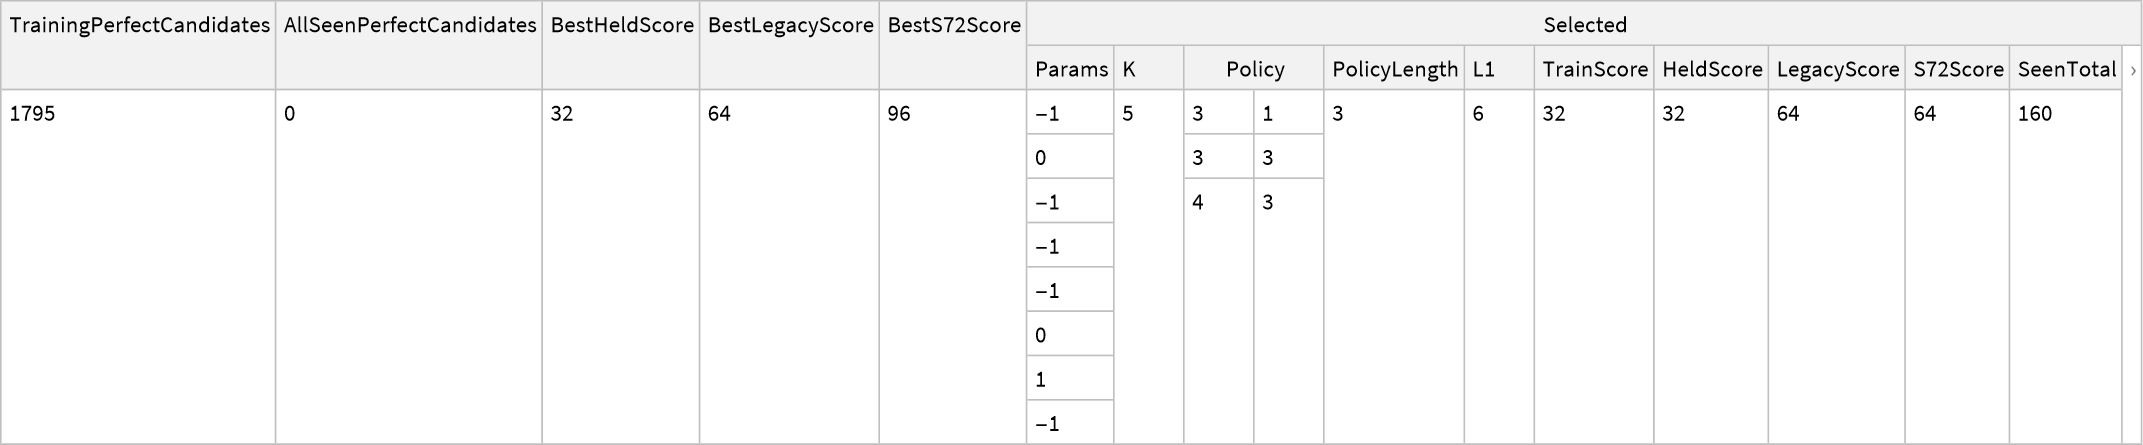

In [484]:
candidates75=Join[
r75A,
r75B,
r75C
];

rankedCandidates75=SortBy[
candidates75,
Function[m,
{
-m["HeldScore"],
-m["LegacyScore"],
-m["S72Score"],
m["L1"],
m["PolicyLength"],
m["Params"],
m["Policy"]
}
]
];

selected75=If[
Length[rankedCandidates75]>0,
First[rankedCandidates75],
$Failed
];

selectionSummary75=<|
"TrainingPerfectCandidates"->Length[candidates75],
"AllSeenPerfectCandidates"->Count[
candidates75,
x_/;TrueQ[x["AllSeenPerfect"]]
],
"BestHeldScore"->If[
Length[candidates75]>0,
Max[Lookup[candidates75,"HeldScore"]],
Missing["None"]
],
"BestLegacyScore"->If[
Length[candidates75]>0,
Max[Lookup[candidates75,"LegacyScore"]],
Missing["None"]
],
"BestS72Score"->If[
Length[candidates75]>0,
Max[Lookup[candidates75,"S72Score"]],
Missing["None"]
],
"Selected"->selected75
|>;

Dataset[{selectionSummary75}]

Dataset[{<|Stage -> S75, Name -> MultiscaleSemanticEncoder, CoreTCCTChanged -> False, 
 
>     OriginalFrozenModelChanged -> False, RepresentationChangedInNewBranch -> True, 
 
>     ProtocolHash -> 0831799824137abacf8d196fc08689f6eacc325a5c4a04643c6051bbd71ea366, 
 
>     PolicyDerivedFromTrainingOnly -> True, S72UsedAsValidation -> True, 
 
>     S75IsBlindTest -> False, ParameterCandidates -> 6561, 
 
>     TrainingPerfectCandidates -> 1795, AllSeenPerfectCandidates -> 0, 
 
>     FrozenCandidate -> 
 
>      <|Representation -> PairedRadius2Radius3WithParentChildCardinality, 
 
>       Params -> {-1, 0, -1, -1, -1, 0, 1, -1}, K -> 5, 
 
>       Policy -> {{3, 1}, {3, 3}, {4, 3}}|>, 
 
>     ScoresByGrammar -> 
 
>      <|S59 -> 32, ChainIn -> 32, SharedMerge -> 32, ParallelIn -> 32, 
 
>       ParallelOut -> 16, DiamondIn -> 16, SharedParallelIn -> 32|>, 
 
>     AllSeenGrammarsPerfect -> False, S76ReservedForFutureBlindTest -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CoreTCCTChanged, 
 
>      OriginalFrozenModelChanged, RepresentationChangedInNewBranch, ProtocolHash, 
 
>      PolicyDerivedFromTrainingOnly, S72UsedAsValidation, S75IsBlindTest, 
 
>      ParameterCandidates, TrainingPerfectCandidates, AllSeenPerfectCandidates, 
 
>      FrozenCandidate, ScoresByGrammar, AllSeenGrammarsPerfect, 
 
>      S76ReservedForFutureBlindTest}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Struct[{Representation, Params, K, Policy}, 
 
>       {TypeSystem`Atom[String], TypeSystem`Vector[TypeSystem`Atom[Integer], 8], 
 
>        TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[
 
>           Integer], 2], 3]}], TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>         ChainIn, DiamondIn, ParallelIn, ParallelOut, S59, SharedMerge, 
 
>         SharedParallelIn]], TypeSystem`Atom[Integer], 7], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
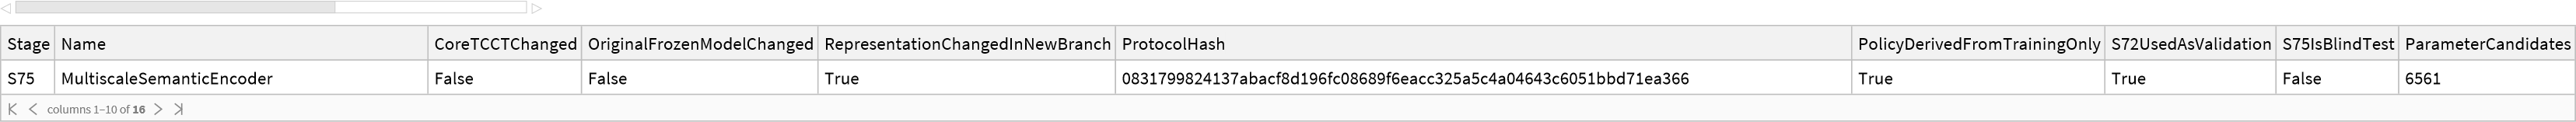

In [489]:
grammarList75={
"S59",
"ChainIn",
"SharedMerge",
"ParallelIn",
"ParallelOut",
"DiamondIn",
"SharedParallelIn"
};

fullRowsByGrammar75=AssociationMap[
BuildRows75[{#},{2,5,9,15}]&,
grammarList75
];

grammarScores75=If[
AssociationQ[selected75],
AssociationMap[
Function[grammar,
ScoreEncoded75[
EncodeRows75[
fullRowsByGrammar75[grammar],
selected75["Params"],
selected75["K"]
],
selected75["Policy"]
]
],
grammarList75
],
<||>
];

frozen75=If[
AssociationQ[selected75],
<|
"Representation"->"PairedRadius2Radius3WithParentChildCardinality",
"Params"->selected75["Params"],
"K"->selected75["K"],
"Policy"->selected75["Policy"]
|>,
$Failed
];

cert75=<|
"Stage"->"S75",
"Name"->"MultiscaleSemanticEncoder",
"CoreTCCTChanged"->False,
"OriginalFrozenModelChanged"->False,
"RepresentationChangedInNewBranch"->True,
"ProtocolHash"->protocolHash75,
"PolicyDerivedFromTrainingOnly"->True,
"S72UsedAsValidation"->True,
"S75IsBlindTest"->False,
"ParameterCandidates"->Length[params75],
"TrainingPerfectCandidates"->Length[candidates75],
"AllSeenPerfectCandidates"->Count[
candidates75,
x_/;TrueQ[x["AllSeenPerfect"]]
],
"FrozenCandidate"->frozen75,
"ScoresByGrammar"->grammarScores75,
"AllSeenGrammarsPerfect"->And@@Map[
SameQ[#,32]&,
Lookup[grammarScores75,grammarList75]
],
"S76ReservedForFutureBlindTest"->True
|>;

Dataset[{cert75}]

Dataset[{<|Params -> {-1, 0, -1, -1, -1, 0, 1, -1}, K -> 5, PolicyLength -> 3, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 64, S72Score -> 64, 
 
>     SeenTotal -> 160, AllSeenPerfect -> False|>, 
 
>    <|Params -> {1, 0, -1, -1, 1, 0, 1, -1}, K -> 5, PolicyLength -> 7, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 64, S72Score -> 60, 
 
>     SeenTotal -> 156, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, -1, -1, 1, 1, -1, -1, 0}, K -> 5, PolicyLength -> 3, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 64, S72Score -> 44, 
 
>     SeenTotal -> 140, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, 1, 1, 0, 1, -1, 0, 0}, K -> 5, PolicyLength -> 3, L1 -> 5, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 64, S72Score -> 36, 
 
>     SeenTotal -> 132, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, 1, -1, 0, -1, -1, 1, 0}, K -> 5, PolicyLength -> 5, L1 -> 5, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 64, S72Score -> 4, 
 
>     SeenTotal -> 100, AllSeenPerfect -> False|>, 
 
>    <|Params -> {1, 1, -1, 1, 1, 0, -1, 1}, K -> 5, PolicyLength -> 4, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 56, S72Score -> 60, 
 
>     SeenTotal -> 148, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, 1, -1, 1, -1, -1, 0, 0}, K -> 5, PolicyLength -> 3, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 56, S72Score -> 48, 
 
>     SeenTotal -> 136, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, 1, 1, 0, -1, 1, 1, 1}, K -> 5, PolicyLength -> 5, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 56, S72Score -> 40, 
 
>     SeenTotal -> 128, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, 1, -1, 1, 1, 1, -1, 1}, K -> 5, PolicyLength -> 4, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 56, S72Score -> 36, 
 
>     SeenTotal -> 124, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, -1, -1, 1, 1, 0, 1, 1}, K -> 5, PolicyLength -> 5, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 52, 
 
>     SeenTotal -> 136, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, 0, 1, 0, 0, -1, 1, 1}, K -> 5, PolicyLength -> 6, L1 -> 5, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 48, 
 
>     SeenTotal -> 132, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, 1, -1, -1, 1, 0, 1, 1}, K -> 5, PolicyLength -> 6, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 48, 
 
>     SeenTotal -> 132, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, -1, -1, 1, 1, 0, -1, -1}, K -> 5, PolicyLength -> 5, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 40, 
 
>     SeenTotal -> 124, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, -1, 1, -1, -1, 1, 1, 0}, K -> 5, PolicyLength -> 5, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 36, 
 
>     SeenTotal -> 120, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, 1, -1, 1, -1, 0, -1, -1}, K -> 5, PolicyLength -> 5, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 36, 
 
>     SeenTotal -> 120, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, -1, 1, 1, -1, 0, -1, 0}, K -> 5, PolicyLength -> 5, L1 -> 5, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 32, 
 
>     SeenTotal -> 116, AllSeenPerfect -> False|>, 
 
>    <|Params -> {1, -1, 1, 1, -1, 0, -1, -1}, K -> 5, PolicyLength -> 5, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 28, 
 
>     SeenTotal -> 112, AllSeenPerfect -> False|>, 
 
>    <|Params -> {-1, -1, -1, -1, 1, 0, 0, 0}, K -> 5, PolicyLength -> 7, L1 -> 5, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 52, S72Score -> 12, 
 
>     SeenTotal -> 96, AllSeenPerfect -> False|>, 
 
>    <|Params -> {0, 0, -1, 0, -1, 1, 1, 1}, K -> 5, PolicyLength -> 2
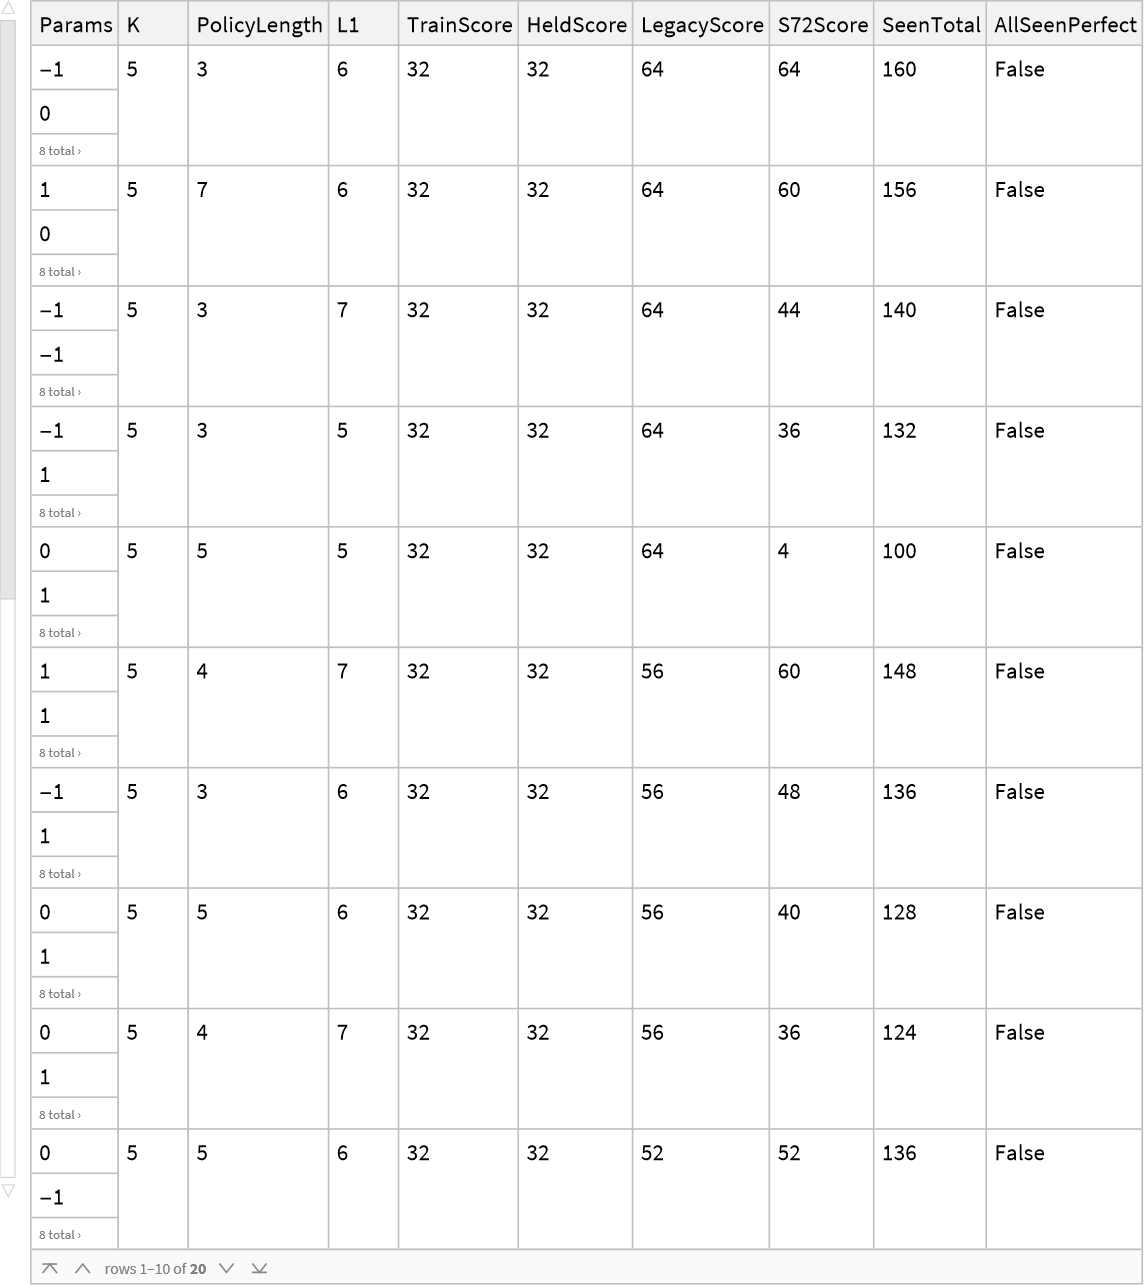

In [495]:
Dataset[
Map[
KeyTake[
#,
{
"Params",
"K",
"PolicyLength",
"L1",
"TrainScore",
"HeldScore",
"LegacyScore",
"S72Score",
"SeenTotal",
"AllSeenPerfect"
}
]&,
Take[
rankedCandidates75,
UpTo[20]
]
]
]

# S75A — Tradeoff and Mechanism Audit

This is a read-only audit of the completed S75 candidate population. It does not change the TCCT core, the original frozen model, the S75 selection rule, or the selected S75 candidate.

## Diagnostic protocol

The audit compares the frozen protocol selection, the most compatible S72-perfect candidate, and the highest-total-score candidate. It reports the Pareto frontier, per-topology failure layers, per-depth failures, and radius/degree-feature ablations. All oracle and ablation results are diagnostic only and are not used to retune or select a model.

Dataset[{<|Stage -> S75A, Name -> TradeoffMechanismAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, OriginalFrozenModelChanged -> False, 
 
>     S75SelectionChanged -> False, CandidateSearchRepeated -> False, 
 
>     UsesExistingTrainingPerfectCandidates -> True, 
 
>     RepresentativeRoles -> 
 
>      {FrozenProtocolSelection, BestCompatibleS72Perfect, HighestSeenTotal}, 
 
>     MechanismLayers -> 
 
>      {RawPairObservation, LatentEncoderCompression, TrainingPolicyAlignment}, 
 
>     Ablations -> 
 
>      {FullPair, Radius2Only, Radius3Only, DegreeTermsZeroed, DegreeTermsOnly}, 
 
>     S75ResultLockPassed -> True, PreflightPassed -> True, 
 
>     S75ProtocolHash -> 
 
>      0831799824137abacf8d196fc08689f6eacc325a5c4a04643c6051bbd71ea366, 
 
>     S75AProtocolHash -> 
 
>      eeed82845625ea4f0a533ca5850eb3b236df58835dbb670ebcb973b7a0b311af|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, CoreTCCTChanged, 
 
>      OriginalFrozenModelChanged, S75SelectionChanged, CandidateSearchRepeated, 
 
>      UsesExistingTrainingPerfectCandidates, RepresentativeRoles, MechanismLayers, 
 
>      Ablations, S75ResultLockPassed, PreflightPassed, S75ProtocolHash, 
 
>      S75AProtocolHash}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 5], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String]}], 1], <||>]
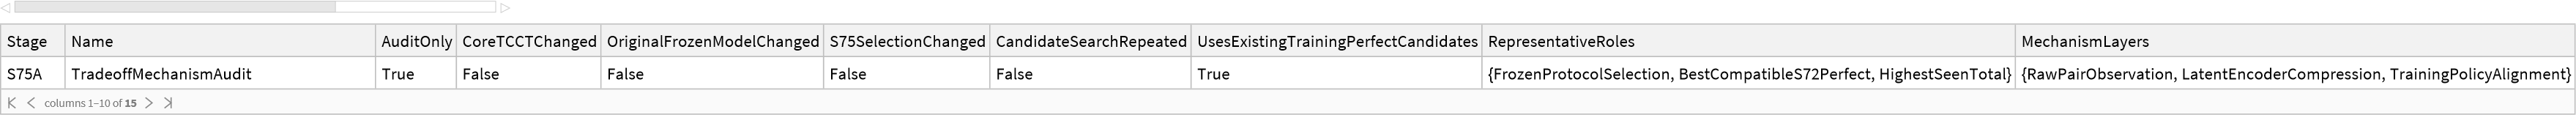

In [504]:
ClearAll["Global`*75A"];

expectedFrozen75A=<|
"Representation"->"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"Policy"->{{3,1},{3,3},{4,3}}
|>;

expectedGrammarScores75A={32,32,32,32,16,16,32};

s75ResultLock75A=And[
TrueQ[preflightPass75],
SameQ[
protocolHash75,
"0831799824137abacf8d196fc08689f6eacc325a5c4a04643c6051bbd71ea366"
],
SameQ[Length[candidates75],1795],
SameQ[
selectionSummary75["AllSeenPerfectCandidates"],
0
],
SameQ[frozen75,expectedFrozen75A],
SameQ[
Lookup[grammarScores75,grammarList75],
expectedGrammarScores75A
]
];

protocol75A=<|
"Stage"->"S75A",
"Name"->"TradeoffMechanismAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"OriginalFrozenModelChanged"->False,
"S75SelectionChanged"->False,
"CandidateSearchRepeated"->False,
"UsesExistingTrainingPerfectCandidates"->True,
"RepresentativeRoles"->{
"FrozenProtocolSelection",
"BestCompatibleS72Perfect",
"HighestSeenTotal"
},
"MechanismLayers"->{
"RawPairObservation",
"LatentEncoderCompression",
"TrainingPolicyAlignment"
},
"Ablations"->{
"FullPair",
"Radius2Only",
"Radius3Only",
"DegreeTermsZeroed",
"DegreeTermsOnly"
},
"S75ResultLockPassed"->s75ResultLock75A
|>;

protocolHash75A=Hash[
Normal[protocol75A],
"SHA256",
"HexString"
];

preflightPass75A=And[
TrueQ[preflightPass75],
TrueQ[s75ResultLock75A]
];

Dataset[{
Join[
protocol75A,
<|
"PreflightPassed"->preflightPass75A,
"S75ProtocolHash"->protocolHash75,
"S75AProtocolHash"->protocolHash75A
|>
]
}]

Dataset[{<|TrainingPerfectCandidates -> 1795, S72PerfectCandidateCount -> 1, 
 
>     HeldAndLegacyPerfectCandidateCount -> 5, BestS72UnderHeldAndLegacyPerfect -> 64, 
 
>     MaximumSeenTotal -> 164, AllSeenPerfectCandidates -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[
 
>       AllSeenPerfectCandidates, BestS72UnderHeldAndLegacyPerfect, 
 
>       HeldAndLegacyPerfectCandidateCount, MaximumSeenTotal, S72PerfectCandidateCount, 
 
>       TrainingPerfectCandidates]], TypeSystem`Atom[Integer], 6], 1], <||>]
Dataset[{<|CandidateRole -> FrozenProtocolSelection, 
 
>     Params -> {-1, 0, -1, -1, -1, 0, 1, -1}, K -> 5, 
 
>     Policy -> {{3, 1}, {3, 3}, {4, 3}}, PolicyLength -> 3, L1 -> 6, TrainScore -> 32, 
 
>     HeldScore -> 32, LegacyScore -> 64, S72Score -> 64, SeenTotal -> 160, 
 
>     AllSeenPerfect -> False|>, <|CandidateRole -> BestCompatibleS72Perfect, 
 
>     Params -> {-1, 0, -1, 1, -1, -1, 1, 0}, K -> 5, 
 
>     Policy -> {{1, 2}, {1, 3}, {1, 5}, {3, 1}}, PolicyLength -> 4, L1 -> 6, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 28, S72Score -> 96, 
 
>     SeenTotal -> 156, AllSeenPerfect -> False|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Params -> {0, -1, -1, 1, -1, 1, -1, 1}, 
 
>     K -> 5, Policy -> {{1, 2}, {1, 3}, {2, 3}, {2, 5}}, PolicyLength -> 4, L1 -> 7, 
 
>     TrainScore -> 32, HeldScore -> 32, LegacyScore -> 40, S72Score -> 92, 
 
>     SeenTotal -> 164, AllSeenPerfect -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CandidateRole, Params, K, Policy, PolicyLength, 
 
>      L1, TrainScore, HeldScore, LegacyScore, S72Score, SeenTotal, AllSeenPerfect}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Vector[TypeSystem`Atom[Integer], 8], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[
 
>         Integer], 2], TypeSystem`AnyLength], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 3], <||>]
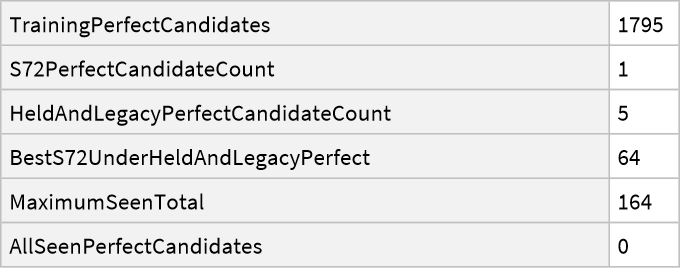
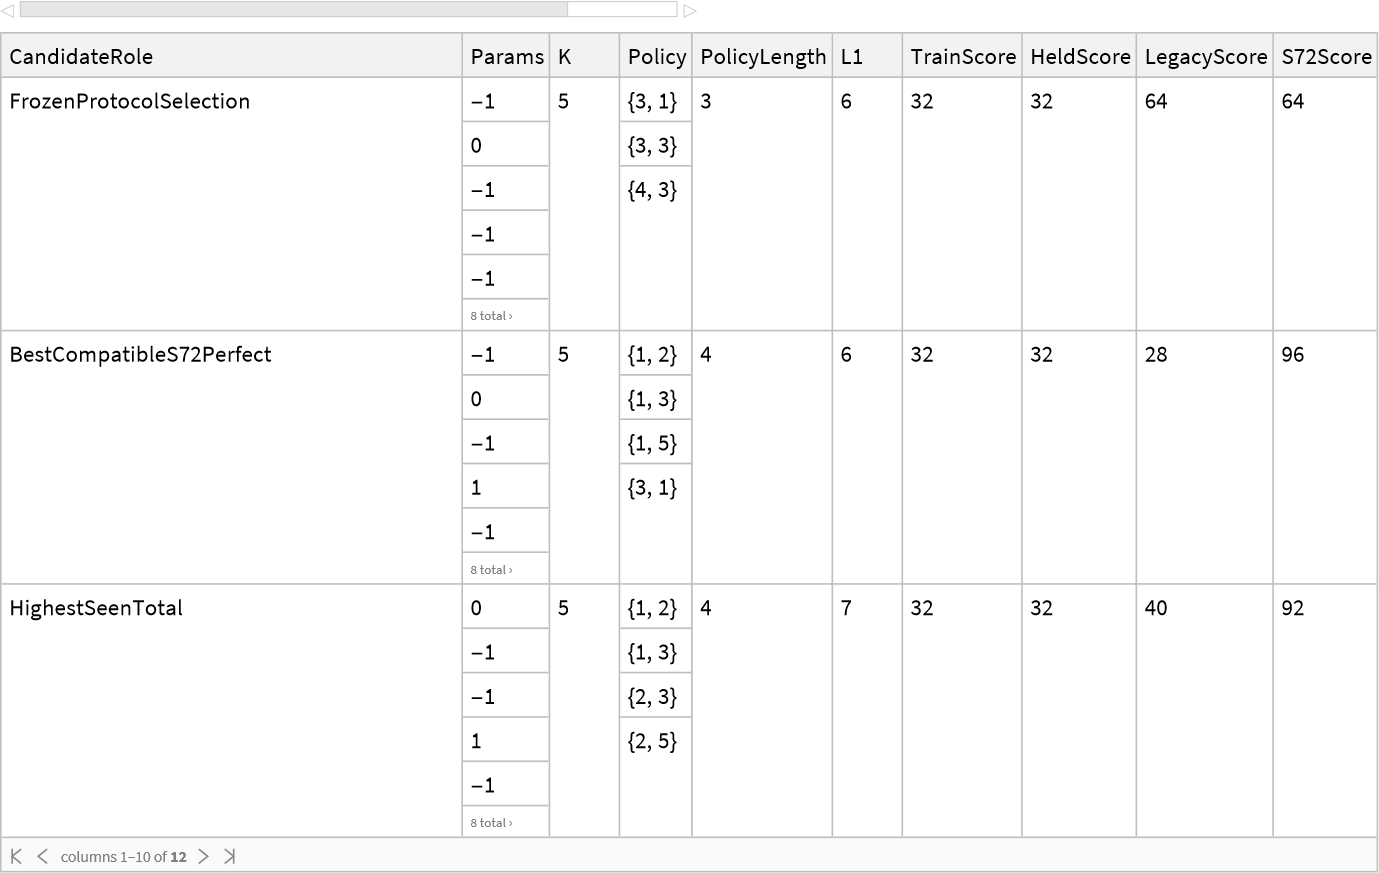

In [512]:
ClearAll[
CandidateCompatibilityKey75A,
CandidateTotalKey75A,
ScoreTriple75A,
ParetoDominates75A
];

CandidateCompatibilityKey75A[m_Association]:={
-m["SeenTotal"],
-m["HeldScore"],
-m["LegacyScore"],
m["L1"],
m["PolicyLength"],
m["Params"],
m["Policy"]
};

CandidateTotalKey75A[m_Association]:={
-m["SeenTotal"],
-m["HeldScore"],
-m["LegacyScore"],
-m["S72Score"],
m["L1"],
m["PolicyLength"],
m["Params"],
m["Policy"]
};

ScoreTriple75A[m_Association]:=Lookup[
m,
{"HeldScore","LegacyScore","S72Score"}
];

ParetoDominates75A[a_List,b_List]:=And[
And@@MapThread[GreaterEqual,{a,b}],
Or@@MapThread[Greater,{a,b}]
];

s72PerfectPool75A=Select[
candidates75,
# ["S72Score"]==Length[s72ValidationRows75]&
];

heldLegacyPerfectPool75A=Select[
candidates75,
And[
# ["HeldScore"]==Length[heldRows75],
# ["LegacyScore"]==Length[legacyValidationRows75]
]&
];

bestCompatibleS72Perfect75A=If[
Length[s72PerfectPool75A]>0,
First@SortBy[
s72PerfectPool75A,
CandidateCompatibilityKey75A
],
$Failed
];

highestSeenTotal75A=If[
Length[candidates75]>0,
First@SortBy[
candidates75,
CandidateTotalKey75A
],
$Failed
];

bestStrictCompatibility75A=If[
Length[heldLegacyPerfectPool75A]>0,
First@SortBy[
heldLegacyPerfectPool75A,
Function[m,
{
-m["S72Score"],
m["L1"],
m["PolicyLength"],
m["Params"],
m["Policy"]
}
]
],
$Failed
];

representativeSpecs75A={
<|
"CandidateRole"->"FrozenProtocolSelection",
"Candidate"->selected75
|>,
<|
"CandidateRole"->"BestCompatibleS72Perfect",
"Candidate"->bestCompatibleS72Perfect75A
|>,
<|
"CandidateRole"->"HighestSeenTotal",
"Candidate"->highestSeenTotal75A
|>
};

candidatePoolSummary75A=<|
"TrainingPerfectCandidates"->Length[candidates75],
"S72PerfectCandidateCount"->Length[s72PerfectPool75A],
"HeldAndLegacyPerfectCandidateCount"->Length[
heldLegacyPerfectPool75A
],
"BestS72UnderHeldAndLegacyPerfect"->If[
Length[heldLegacyPerfectPool75A]>0,
Max[Lookup[heldLegacyPerfectPool75A,"S72Score"]],
Missing["NoCompatibleCandidate"]
],
"MaximumSeenTotal"->If[
Length[candidates75]>0,
Max[Lookup[candidates75,"SeenTotal"]],
Missing["NoCandidate"]
],
"AllSeenPerfectCandidates"->Count[
candidates75,
x_/;TrueQ[x["AllSeenPerfect"]]
]
|>;

Dataset[{candidatePoolSummary75A}]

Dataset[
Map[
Function[spec,
Join[
<|"CandidateRole"->spec["CandidateRole"]|>,
KeyTake[
spec["Candidate"],
{
"Params","K","Policy","PolicyLength","L1",
"TrainScore","HeldScore","LegacyScore","S72Score",
"SeenTotal","AllSeenPerfect"
}
]
]
],
representativeSpecs75A
]
]

In [526]:
allScoreTriples75A=ScoreTriple75A/@candidates75;
uniqueScoreTriples75A=DeleteDuplicates[allScoreTriples75A];

paretoTriples75A=Select[
uniqueScoreTriples75A,
Function[triple,
Not@AnyTrue[
uniqueScoreTriples75A,
ParetoDominates75A[#,triple]&
]
]
];

paretoRows75A=SortBy[
Map[
Function[triple,
<|
"HeldScore"->triple[[1]],
"LegacyScore"->triple[[2]],
"S72Score"->triple[[3]],
"SeenTotal"->Total[triple],
"CandidateCount"->Count[allScoreTriples75A,triple]
|>
],
paretoTriples75A
],
Function[row,
{
-row["SeenTotal"],
-row["HeldScore"],
-row["LegacyScore"],
-row["S72Score"]
}
]
];

paretoSummary75A=<|
"DistinctScoreTriples"->Length[uniqueScoreTriples75A],
"ParetoScoreTriples"->Length[paretoTriples75A],
"ParetoCandidates"->Total[Lookup[paretoRows75A,"CandidateCount"]]
|>;

Dataset[{paretoSummary75A}]
Dataset[paretoRows75A]

Dataset[{<|DistinctScoreTriples -> 195, ParetoScoreTriples -> 4, 
 
>     ParetoCandidates -> 4|>}, TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[
 
>      TypeSystem`Enumeration[DistinctScoreTriples, ParetoCandidates, 
 
>       ParetoScoreTriples]], TypeSystem`Atom[Integer], 3], 1], <||>]
Dataset[{<|HeldScore -> 32, LegacyScore -> 40, S72Score -> 92, SeenTotal -> 164, 
 
>     CandidateCount -> 1|>, <|HeldScore -> 32, LegacyScore -> 64, S72Score -> 64, 
 
>     SeenTotal -> 160, CandidateCount -> 1|>, 
 
>    <|HeldScore -> 32, LegacyScore -> 48, S72Score -> 80, SeenTotal -> 160, 
 
>     CandidateCount -> 1|>, <|HeldScore -> 32, LegacyScore -> 28, S72Score -> 96, 
 
>     SeenTotal -> 156, CandidateCount -> 1|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{HeldScore, LegacyScore, S72Score, SeenTotal, 
 
>      CandidateCount}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 4]
 
>    , <||>]

In [533]:
coefficientNames75A={
"Bias",
"SelfCode",
"ParentSum",
"ChildSum",
"ParentSquare",
"ChildSquare",
"ParentCount",
"ChildCount"
};

coefficientRows75A=Map[
Function[spec,
Join[
<|"CandidateRole"->spec["CandidateRole"]|>,
AssociationThread[
coefficientNames75A,
spec["Candidate"]["Params"]
],
<|
"Policy"->spec["Candidate"]["Policy"],
"PolicyLength"->spec["Candidate"]["PolicyLength"]
|>
]
],
representativeSpecs75A
];

Dataset[coefficientRows75A]

Dataset[{<|CandidateRole -> FrozenProtocolSelection, Bias -> -1, SelfCode -> 0, 
 
>     ParentSum -> -1, ChildSum -> -1, ParentSquare -> -1, ChildSquare -> 0, 
 
>     ParentCount -> 1, ChildCount -> -1, Policy -> {{3, 1}, {3, 3}, {4, 3}}, 
 
>     PolicyLength -> 3|>, <|CandidateRole -> BestCompatibleS72Perfect, Bias -> -1, 
 
>     SelfCode -> 0, ParentSum -> -1, ChildSum -> 1, ParentSquare -> -1, 
 
>     ChildSquare -> -1, ParentCount -> 1, ChildCount -> 0, 
 
>     Policy -> {{1, 2}, {1, 3}, {1, 5}, {3, 1}}, PolicyLength -> 4|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Bias -> 0, SelfCode -> -1, ParentSum -> -1, 
 
>     ChildSum -> 1, ParentSquare -> -1, ChildSquare -> 1, ParentCount -> -1, 
 
>     ChildCount -> 1, Policy -> {{1, 2}, {1, 3}, {2, 3}, {2, 5}}, PolicyLength -> 4|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CandidateRole, Bias, SelfCode, ParentSum, 
 
>      ChildSum, ParentSquare, ChildSquare, ParentCount, ChildCount, Policy, 
 
>      PolicyLength}, {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[
 
>         Integer], 2], TypeSystem`AnyLength], TypeSystem`Atom[Integer]}], 3], <||>]

In [536]:
ClearAll[
RawEncodedRows75A,
SemanticOracleStats75A,
Prediction75A,
PolicyErrorCounts75A,
MechanismAudit75A
];

RawEncodedRows75A[data_List]:=Map[
Function[row,
Join[
KeyTake[
row,
{"Grammar","Depth","Answer","Target"}
],
<|
"Codes"->DeleteDuplicates[row["StatePairs"]]
|>
]
],
data
];

SemanticOracleStats75A[encodedRows_List]:=Module[
{
continueRows,stopRows,continueTokens,stopTokens,
sharedTokens,oraclePolicy,oracleScore
},
continueRows=Select[
encodedRows,
# ["Target"]==="Continue"&
];
stopRows=Select[
encodedRows,
# ["Target"]==="Stop"&
];
continueTokens=Union@@Lookup[continueRows,"Codes"];
stopTokens=Union@@Lookup[stopRows,"Codes"];
sharedTokens=Intersection[continueTokens,stopTokens];
oraclePolicy=Complement[continueTokens,stopTokens];
oracleScore=ScoreEncoded75[
encodedRows,
oraclePolicy
];
<|
"DistinctTokens"->Length[Union[continueTokens,stopTokens]],
"SharedTokens"->Length[sharedTokens],
"ContinueOnlyTokens"->Length[oraclePolicy],
"OraclePolicy"->oraclePolicy,
"ContinueTokens"->continueTokens,
"StopTokens"->stopTokens,
"OracleScore"->oracleScore
|>
];

Prediction75A[row_Association,policy_List]:=AnyTrue[
row["Codes"],
MemberQ[policy,#]&
];

PolicyErrorCounts75A[
encodedRows_List,
policy_List
]:=Module[{missedContinue,triggeredStop},
missedContinue=Count[
encodedRows,
row_/;And[
row["Target"]==="Continue",
Not@TrueQ[Prediction75A[row,policy]]
]
];
triggeredStop=Count[
encodedRows,
row_/;And[
row["Target"]==="Stop",
TrueQ[Prediction75A[row,policy]]
]
];
<|
"MissedContinueCases"->missedContinue,
"TriggeredStopCases"->triggeredStop
|>
];

MechanismAudit75A[
spec_Association,
grammar_String,
depthSet_List
]:=Module[
{
candidate,rows,rawRows,latentRows,rawStats,latentStats,
policyErrors,frozenScore,firstFailure
},
candidate=spec["Candidate"];
rows=BuildRows75[{grammar},depthSet];
rawRows=RawEncodedRows75A[rows];
latentRows=EncodeRows75[
rows,
candidate["Params"],
candidate["K"]
];
rawStats=SemanticOracleStats75A[rawRows];
latentStats=SemanticOracleStats75A[latentRows];
frozenScore=ScoreEncoded75[
latentRows,
candidate["Policy"]
];
policyErrors=PolicyErrorCounts75A[
latentRows,
candidate["Policy"]
];
firstFailure=Which[
rawStats["OracleScore"]<Length[rows],
"RawPairObservationCollapse",
latentStats["OracleScore"]<Length[rows],
"LatentEncoderCompression",
frozenScore<Length[rows],
"TrainingPolicyAlignment",
True,
"None"
];
Join[
<|
"CandidateRole"->spec["CandidateRole"],
"Grammar"->grammar,
"DepthSet"->depthSet,
"Cases"->Length[rows],
"RawDistinctTokens"->rawStats["DistinctTokens"],
"RawSharedTokens"->rawStats["SharedTokens"],
"RawOracleScore"->rawStats["OracleScore"],
"LatentDistinctTokens"->latentStats["DistinctTokens"],
"LatentSharedTokens"->latentStats["SharedTokens"],
"LatentOracleScore"->latentStats["OracleScore"],
"FrozenPolicyScore"->frozenScore,
"PolicyStopTokenOverlap"->Length@Intersection[
candidate["Policy"],
latentStats["StopTokens"]
],
"EvaluationContinueTokensMissingFromPolicy"->Length@Complement[
latentStats["OraclePolicy"],
candidate["Policy"]
],
"FirstFailureLayer"->firstFailure
|>,
policyErrors
]
];

mechanismRows75A=Flatten[
Table[
MechanismAudit75A[
spec,
grammar,
{2,5,9,15}
],
{spec,representativeSpecs75A},
{grammar,grammarList75}
],
1
];

Dataset[mechanismRows75A]

Dataset[{<|CandidateRole -> FrozenProtocolSelection, Grammar -> S59, 
 
>     DepthSet -> {2, 5, 9, 15}, Cases -> 32, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 32, LatentDistinctTokens -> 4, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 32, FrozenPolicyScore -> 32, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 0, 
 
>     FirstFailureLayer -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Grammar -> ChainIn, 
 
>     DepthSet -> {2, 5, 9, 15}, Cases -> 32, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 32, LatentDistinctTokens -> 4, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 32, FrozenPolicyScore -> 32, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 0, 
 
>     FirstFailureLayer -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Grammar -> SharedMerge, 
 
>     DepthSet -> {2, 5, 9, 15}, Cases -> 32, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 32, LatentDistinctTokens -> 2, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 32, FrozenPolicyScore -> 32, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 0, 
 
>     FirstFailureLayer -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Grammar -> ParallelIn, 
 
>     DepthSet -> {2, 5, 9, 15}, Cases -> 32, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 32, LatentDistinctTokens -> 2, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 32, FrozenPolicyScore -> 32, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 0, 
 
>     FirstFailureLayer -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Grammar -> ParallelOut, 
 
>     DepthSet -> {2, 5, 9, 15}, Cases -> 32, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 32, LatentDistinctTokens -> 4, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 32, FrozenPolicyScore -> 16, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 2, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 16, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> DiamondIn, DepthSet -> {2, 5, 9, 15}, Cases -> 32, 
 
>     RawDistinctTokens -> 2, RawSharedTokens -> 0, RawOracleScore -> 32, 
 
>     LatentDistinctTokens -> 2, LatentSharedTokens -> 0, LatentOracleScore -> 32, 
 
>     FrozenPolicyScore -> 16, PolicyStopTokenOverlap -> 0, 
 
>     EvaluationContinueTokensMissingFromPolicy -> 1, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 16, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> SharedParallelIn, DepthSet -> {2, 5, 9, 15}, Cases -> 32, 
 
>     RawDistinctTokens -> 12, RawSharedTokens -> 0, RawOracleScore -> 32, 
 
>     LatentDistinctTokens -> 3, LatentSharedTokens -> 0, LatentOracleScore -> 32, 
 
>     FrozenPolicyScore -> 32, PolicyStopTokenOverlap -> 0, 
 
>     EvaluationContinueTokensMissingFromPolicy -> 0, FirstFailureLayer -> None, 
 
>     MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Grammar -> S59, 
 
>     DepthSet -> {2, 5, 9, 15}, Cases -> 32, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 32, LatentDistinctTokens -> 6, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 32, FrozenPolicyScore -> 32, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 0, 
 
>     FirstFailureLayer -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect

In [544]:
depthMechanismRows75A=Flatten[
Table[
MechanismAudit75A[
spec,
grammar,
{depth}
],
{spec,representativeSpecs75A},
{grammar,grammarList75},
{depth,{2,5,9,15}}
],
2
];

failingDepthRows75A=Select[
depthMechanismRows75A,
# ["FrozenPolicyScore"]<# ["Cases"]&
];

Dataset[failingDepthRows75A]

Dataset[{<|CandidateRole -> FrozenProtocolSelection, Grammar -> ParallelOut, 
 
>     DepthSet -> {2}, Cases -> 8, RawDistinctTokens -> 8, RawSharedTokens -> 0, 
 
>     RawOracleScore -> 8, LatentDistinctTokens -> 4, LatentSharedTokens -> 0, 
 
>     LatentOracleScore -> 8, FrozenPolicyScore -> 4, PolicyStopTokenOverlap -> 0, 
 
>     EvaluationContinueTokensMissingFromPolicy -> 2, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> ParallelOut, DepthSet -> {5}, Cases -> 8, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 4, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 2, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> ParallelOut, DepthSet -> {9}, Cases -> 8, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 4, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 2, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> ParallelOut, DepthSet -> {15}, Cases -> 8, RawDistinctTokens -> 8, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 4, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 2, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> DiamondIn, DepthSet -> {2}, Cases -> 8, RawDistinctTokens -> 2, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 2, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 1, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> DiamondIn, DepthSet -> {5}, Cases -> 8, RawDistinctTokens -> 2, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 2, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 1, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> DiamondIn, DepthSet -> {9}, Cases -> 8, RawDistinctTokens -> 2, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 2, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 1, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     Grammar -> DiamondIn, DepthSet -> {15}, Cases -> 8, RawDistinctTokens -> 2, 
 
>     RawSharedTokens -> 0, RawOracleScore -> 8, LatentDistinctTokens -> 2, 
 
>     LatentSharedTokens -> 0, LatentOracleScore -> 8, FrozenPolicyScore -> 4, 
 
>     PolicyStopTokenOverlap -> 0, EvaluationContinueTokensMissingFromPolicy -> 1, 
 
>     FirstFailureLayer -> TrainingPolicyAlignment, MissedContinueCases -> 4, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> BestCompatibleS72Perfect, 

Dataset[{<|CandidateRole -> FrozenProtocolSelection, Ablation -> FullPair, 
 
>     PolicyLength -> 3, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 64, S72Score -> 64, SeenTotal -> 160|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> Radius2Only, 
 
>     PolicyLength -> 1, TrainScore -> 28, TrainPerfect -> False, HeldScore -> 28, 
 
>     LegacyScore -> 64, S72Score -> 72, SeenTotal -> 164|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> Radius3Only, 
 
>     PolicyLength -> 2, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 64, S72Score -> 64, SeenTotal -> 160|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> DegreeTermsZeroed, 
 
>     PolicyLength -> 3, TrainScore -> 28, TrainPerfect -> False, HeldScore -> 28, 
 
>     LegacyScore -> 32, S72Score -> 52, SeenTotal -> 112|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> DegreeTermsOnly, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, SeenTotal -> 96|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> FullPair, 
 
>     PolicyLength -> 4, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 28, S72Score -> 96, SeenTotal -> 156|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> Radius2Only, 
 
>     PolicyLength -> 2, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 44, S72Score -> 80, SeenTotal -> 156|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> Radius3Only, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, SeenTotal -> 96|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> DegreeTermsZeroed, 
 
>     PolicyLength -> 4, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 32, S72Score -> 32, SeenTotal -> 96|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> DegreeTermsOnly, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, SeenTotal -> 96|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Ablation -> FullPair, PolicyLength -> 4, 
 
>     TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, LegacyScore -> 40, 
 
>     S72Score -> 92, SeenTotal -> 164|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Ablation -> Radius2Only, PolicyLength -> 1, 
 
>     TrainScore -> 28, TrainPerfect -> False, HeldScore -> 28, LegacyScore -> 32, 
 
>     S72Score -> 64, SeenTotal -> 124|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Ablation -> Radius3Only, PolicyLength -> 2, 
 
>     TrainScore -> 26, TrainPerfect -> False, HeldScore -> 26, LegacyScore -> 28, 
 
>     S72Score -> 48, SeenTotal -> 102|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Ablation -> DegreeTermsZeroed, 
 
>     PolicyLength -> 4, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 40, S72Score -> 60, SeenTotal -> 132|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Ablation -> DegreeTermsOnly, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, SeenTotal -> 96|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CandidateRole, Ablation, PolicyLength, 
 
>      TrainScore, TrainPerfect, HeldScore, LegacyScore, S72Score, SeenTotal}, 
 
>     {TypeSystem`Atom[TypeSystem`Enumeration[BestCompatibleS72Perfect, 
 
>        FrozenProtocolSelection, HighestSeenTotal]], 
 
>      TypeSystem`Atom[TypeSystem`Enumeration[DegreeTermsOnly, DegreeTermsZeroed, 
 
>        FullPair, Radius2Only, Radius3Only]], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integ
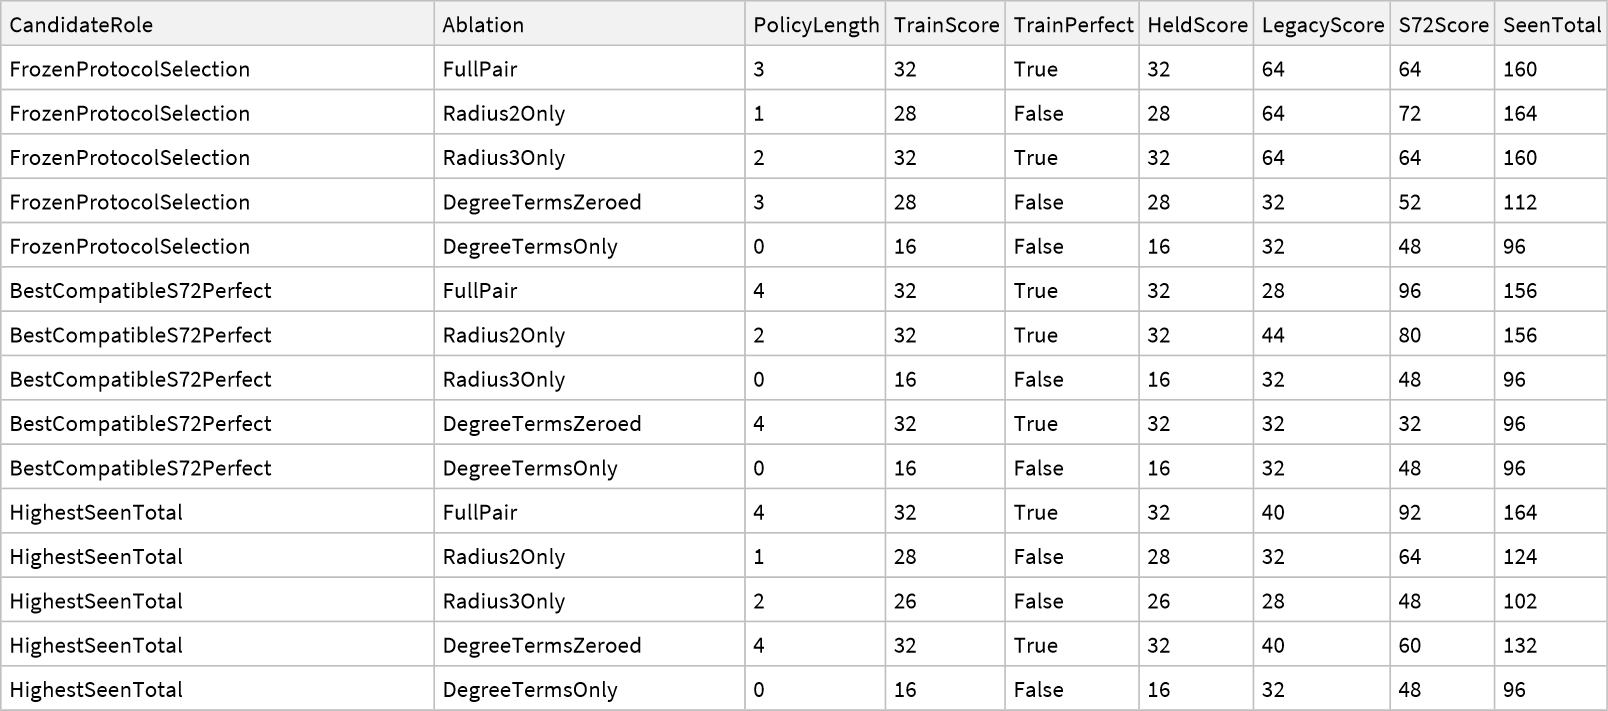

In [547]:
ClearAll[
ProjectEncodedRows75A,
EncodeMode75A,
AblationAudit75A
];

ProjectEncodedRows75A[
encodedRows_List,
projection_String
]:=Map[
Function[row,
Join[
KeyDrop[row,{"Codes"}],
<|
"Codes"->Switch[
projection,
"Radius2Only",
DeleteDuplicates[First/@row["Codes"]],
"Radius3Only",
DeleteDuplicates[Last/@row["Codes"]],
_,
row["Codes"]
]
|>
]
],
encodedRows
];

EncodeMode75A[
data_List,
candidate_Association,
mode_String
]:=Module[{params,encoded},
params=Switch[
mode,
"DegreeTermsZeroed",
ReplacePart[
candidate["Params"],
{7->0,8->0}
],
"DegreeTermsOnly",
Join[
ConstantArray[0,6],
candidate["Params"][[7;;8]]
],
_,
candidate["Params"]
];
encoded=EncodeRows75[
data,
params,
candidate["K"]
];
Switch[
mode,
"Radius2Only",
ProjectEncodedRows75A[encoded,"Radius2Only"],
"Radius3Only",
ProjectEncodedRows75A[encoded,"Radius3Only"],
_,
encoded
]
];

AblationAudit75A[
spec_Association,
mode_String
]:=Module[
{
candidate,trainEncoded,policy,trainScore,heldScore,
legacyScore,s72Score
},
candidate=spec["Candidate"];
trainEncoded=EncodeMode75A[
trainRows75,
candidate,
mode
];
policy=TrainingPolicy75[trainEncoded];
trainScore=ScoreEncoded75[
trainEncoded,
policy
];
heldScore=ScoreEncoded75[
EncodeMode75A[heldRows75,candidate,mode],
policy
];
legacyScore=ScoreEncoded75[
EncodeMode75A[legacyValidationRows75,candidate,mode],
policy
];
s72Score=ScoreEncoded75[
EncodeMode75A[s72ValidationRows75,candidate,mode],
policy
];
<|
"CandidateRole"->spec["CandidateRole"],
"Ablation"->mode,
"PolicyLength"->Length[policy],
"TrainScore"->trainScore,
"TrainPerfect"->SameQ[trainScore,Length[trainRows75]],
"HeldScore"->heldScore,
"LegacyScore"->legacyScore,
"S72Score"->s72Score,
"SeenTotal"->heldScore+legacyScore+s72Score
|>
];

ablationModes75A={
"FullPair",
"Radius2Only",
"Radius3Only",
"DegreeTermsZeroed",
"DegreeTermsOnly"
};

ablationRows75A=Flatten[
Table[
AblationAudit75A[spec,mode],
{spec,representativeSpecs75A},
{mode,ablationModes75A}
],
1
];

Dataset[ablationRows75A]

Dataset[{<|Stage -> S75A, Name -> TradeoffMechanismAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, OriginalFrozenModelChanged -> False, 
 
>     S75SelectionChanged -> False, S75ResultLockPassed -> True, 
 
>     PreflightPassed -> True, S75ProtocolHash -> 
 
>      0831799824137abacf8d196fc08689f6eacc325a5c4a04643c6051bbd71ea366, 
 
>     S75AProtocolHash -> 
 
>      eeed82845625ea4f0a533ca5850eb3b236df58835dbb670ebcb973b7a0b311af, 
 
>     CandidatePoolSummary -> 
 
>      <|TrainingPerfectCandidates -> 1795, S72PerfectCandidateCount -> 1, 
 
>       HeldAndLegacyPerfectCandidateCount -> 5, BestS72UnderHeldAndLegacyPerfect -> 64, 
 
>       MaximumSeenTotal -> 164, AllSeenPerfectCandidates -> 0|>, 
 
>     RepresentativeCandidates -> 
 
>      {<|CandidateRole -> FrozenProtocolSelection, 
 
>        Params -> {-1, 0, -1, -1, -1, 0, 1, -1}, K -> 5, 
 
>        Policy -> {{3, 1}, {3, 3}, {4, 3}}, HeldScore -> 32, LegacyScore -> 64, 
 
>        S72Score -> 64, SeenTotal -> 160|>, 
 
>       <|CandidateRole -> BestCompatibleS72Perfect, 
 
>        Params -> {-1, 0, -1, 1, -1, -1, 1, 0}, K -> 5, 
 
>        Policy -> {{1, 2}, {1, 3}, {1, 5}, {3, 1}}, HeldScore -> 32, LegacyScore -> 28, 
 
>        S72Score -> 96, SeenTotal -> 156|>, 
 
>       <|CandidateRole -> HighestSeenTotal, Params -> {0, -1, -1, 1, -1, 1, -1, 1}, 
 
>        K -> 5, Policy -> {{1, 2}, {1, 3}, {2, 3}, {2, 5}}, HeldScore -> 32, 
 
>        LegacyScore -> 40, S72Score -> 92, SeenTotal -> 164|>}, 
 
>     ParetoScoreTriples -> 4, FailureCountsByRole -> 
 
>      {<|CandidateRole -> FrozenProtocolSelection, 
 
>        FailureLayerCounts -> <|None -> 5, TrainingPolicyAlignment -> 2|>|>, 
 
>       <|CandidateRole -> BestCompatibleS72Perfect, 
 
>        FailureLayerCounts -> <|None -> 5, TrainingPolicyAlignment -> 2|>|>, 
 
>       <|CandidateRole -> HighestSeenTotal, 
 
>        FailureLayerCounts -> <|None -> 4, TrainingPolicyAlignment -> 3|>|>}, 
 
>     AblationsAreDiagnosticOnly -> True, S76BlindTestRun -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, CoreTCCTChanged, 
 
>      OriginalFrozenModelChanged, S75SelectionChanged, S75ResultLockPassed, 
 
>      PreflightPassed, S75ProtocolHash, S75AProtocolHash, CandidatePoolSummary, 
 
>      RepresentativeCandidates, ParetoScoreTriples, FailureCountsByRole, 
 
>      AblationsAreDiagnosticOnly, S76BlindTestRun}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[AllSeenPerfectCandidates, 
 
>         BestS72UnderHeldAndLegacyPerfect, HeldAndLegacyPerfectCandidateCount, 
 
>         MaximumSeenTotal, S72PerfectCandidateCount, TrainingPerfectCandidates]], 
 
>       TypeSystem`Atom[Integer], 6], 
 
>      TypeSystem`Vector[TypeSystem`Struct[{CandidateRole, Params, K, Policy, HeldScore, 
 
>         LegacyScore, S72Score, SeenTotal}, 
 
>        {TypeSystem`Atom[String], TypeSystem`Vector[TypeSystem`Atom[Integer], 8], 
 
>         TypeSystem`Atom[Integer], 
 
>         TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>          TypeSystem`AnyLength], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>         TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 3], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Struct[{CandidateRole, 
 
>         FailureLayerCounts}, {TypeSystem`Atom[String], 
 
>         TypeSystem`Struct[{None, TrainingPolicyAlignment}, 
 
>          {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}]}], 3], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
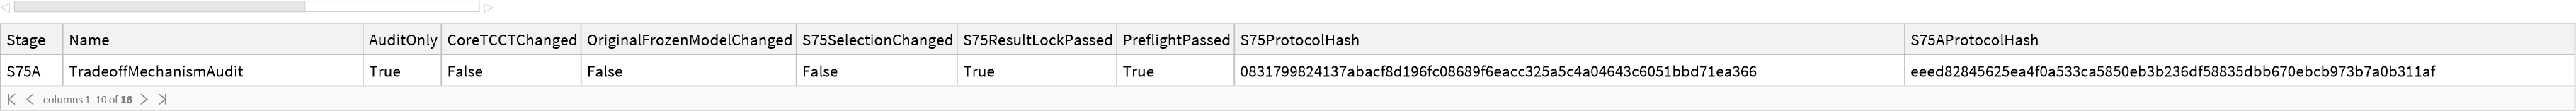

In [554]:
failureCountsByRole75A=Map[
Function[spec,
<|
"CandidateRole"->spec["CandidateRole"],
"FailureLayerCounts"->Counts@Lookup[
Select[
mechanismRows75A,
# ["CandidateRole"]===spec["CandidateRole"]&
],
"FirstFailureLayer"
]
|>
],
representativeSpecs75A
];

cert75A=<|
"Stage"->"S75A",
"Name"->"TradeoffMechanismAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"OriginalFrozenModelChanged"->False,
"S75SelectionChanged"->False,
"S75ResultLockPassed"->s75ResultLock75A,
"PreflightPassed"->preflightPass75A,
"S75ProtocolHash"->protocolHash75,
"S75AProtocolHash"->protocolHash75A,
"CandidatePoolSummary"->candidatePoolSummary75A,
"RepresentativeCandidates"->Map[
Function[spec,
Join[
<|"CandidateRole"->spec["CandidateRole"]|>,
KeyTake[
spec["Candidate"],
{
"Params","K","Policy","HeldScore","LegacyScore",
"S72Score","SeenTotal"
}
]
]
],
representativeSpecs75A
],
"ParetoScoreTriples"->Length[paretoTriples75A],
"FailureCountsByRole"->failureCountsByRole75A,
"AblationsAreDiagnosticOnly"->True,
"S76BlindTestRun"->False
|>;

Dataset[{cert75A}]

# S75B — Cross-Topology Semantic Audit

S75B corrects the per-topology attribution limitation found in S75A. It jointly audits training, heldout, legacy, and S72 token meanings without changing the TCCT core, frozen models, candidate ranking, or S75 selection.

## Corrected interpretation protocol

The audit distinguishes unseen validation codes from semantic flips between training and new topologies. It also tests whether one pure code-membership policy can be perfect on each combined scope. Ablation totals are considered protocol-eligible only when the ablated representation remains training-perfect.

Dataset[{<|Stage -> S75B, Name -> CrossTopologySemanticAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, OriginalFrozenModelChanged -> False, 
 
>     S75SelectionChanged -> False, S75AResultChanged -> False, 
 
>     AuditIntroducesNewCandidateSearch -> False, 
 
>     S75SearchReexecutedForStateReconstruction -> True, 
 
>     JointSemanticScopes -> 
 
>      {TrainingPlusHeldout, TrainingPlusLegacy, TrainingPlusS72, AllSeen}, 
 
>     Distinguishes -> 
 
>      {TrainingCoverageGap, TrainContinueToValidationStop, 
 
>       TrainStopToValidationContinue, RawCrossTopologyObservationConflict, 
 
>       LatentCrossTopologySemanticConflict, TrainingPolicyAlignment}, 
 
>     AblationTotalsRequireTrainingPerfect -> True, S75AResultLockPassed -> True, 
 
>     PreflightPassed -> True, S75AProtocolHash -> 
 
>      eeed82845625ea4f0a533ca5850eb3b236df58835dbb670ebcb973b7a0b311af, 
 
>     S75BProtocolHash -> 
 
>      eb3bc37f8c9ee9fb2932f2fc2c9f66301866c9f367cbb49fb4397c1dbf42e9bd|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, AuditOnly, CoreTCCTChanged, 
 
>      OriginalFrozenModelChanged, S75SelectionChanged, S75AResultChanged, 
 
>      AuditIntroducesNewCandidateSearch, S75SearchReexecutedForStateReconstruction, 
 
>      JointSemanticScopes, Distinguishes, AblationTotalsRequireTrainingPerfect, 
 
>      S75AResultLockPassed, PreflightPassed, S75AProtocolHash, S75BProtocolHash}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 4], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 6], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String]}], 1], <||>]
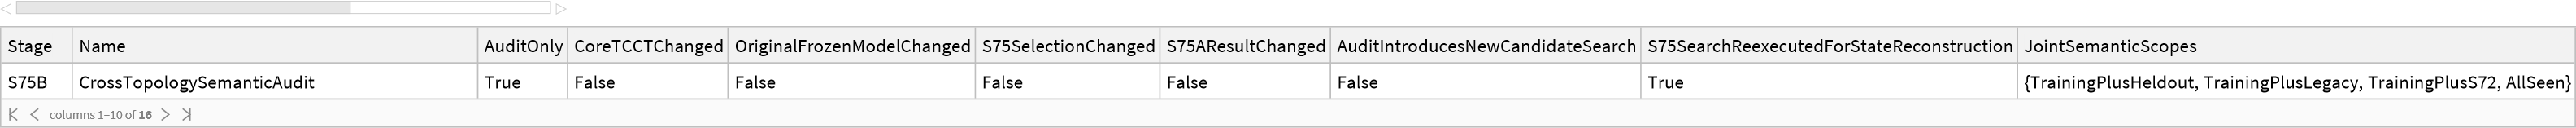

In [565]:
ClearAll["Global`*75B"];

expectedS75AProtocolHash75B=
"eeed82845625ea4f0a533ca5850eb3b236df58835dbb670ebcb973b7a0b311af";

expectedCandidatePool75B={1795,1,5,64,164,0};

s75AResultLock75B=And[
TrueQ[preflightPass75A],
TrueQ[cert75A["PreflightPassed"]],
TrueQ[cert75A["S75ResultLockPassed"]],
SameQ[protocolHash75A,expectedS75AProtocolHash75B],
SameQ[
Lookup[
cert75A["CandidatePoolSummary"],
{
"TrainingPerfectCandidates",
"S72PerfectCandidateCount",
"HeldAndLegacyPerfectCandidateCount",
"BestS72UnderHeldAndLegacyPerfect",
"MaximumSeenTotal",
"AllSeenPerfectCandidates"
}
],
expectedCandidatePool75B
],
SameQ[
Lookup[
cert75A["RepresentativeCandidates"],
"CandidateRole"
],
{
"FrozenProtocolSelection",
"BestCompatibleS72Perfect",
"HighestSeenTotal"
}
]
];

protocol75B=<|
"Stage"->"S75B",
"Name"->"CrossTopologySemanticAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"OriginalFrozenModelChanged"->False,
"S75SelectionChanged"->False,
"S75AResultChanged"->False,
"AuditIntroducesNewCandidateSearch"->False,
"S75SearchReexecutedForStateReconstruction"->True,
"JointSemanticScopes"->{
"TrainingPlusHeldout",
"TrainingPlusLegacy",
"TrainingPlusS72",
"AllSeen"
},
"Distinguishes"->{
"TrainingCoverageGap",
"TrainContinueToValidationStop",
"TrainStopToValidationContinue",
"RawCrossTopologyObservationConflict",
"LatentCrossTopologySemanticConflict",
"TrainingPolicyAlignment"
},
"AblationTotalsRequireTrainingPerfect"->True,
"S75AResultLockPassed"->s75AResultLock75B
|>;

protocolHash75B=Hash[
Normal[protocol75B],
"SHA256",
"HexString"
];

preflightPass75B=And[
TrueQ[preflightPass75A],
TrueQ[s75AResultLock75B]
];

Dataset[{
Join[
protocol75B,
<|
"PreflightPassed"->preflightPass75B,
"S75AProtocolHash"->protocolHash75A,
"S75BProtocolHash"->protocolHash75B
|>
]
}]

In [573]:
validationRows75B=Join[
heldRows75,
legacyValidationRows75,
s72ValidationRows75
];

allSeenRows75B=Join[
trainRows75,
validationRows75B
];

evaluationGroups75B=<|
"Heldout"->heldRows75,
"Legacy"->legacyValidationRows75,
"S72"->s72ValidationRows75,
"AllValidation"->validationRows75B
|>;

evaluationRowsByGrammar75B=AssociationMap[
Function[grammar,
Switch[
grammar,
"S59"|"ChainIn",
Select[
heldRows75,
# ["Grammar"]===grammar&
],
"SharedMerge"|"ParallelIn",
Select[
legacyValidationRows75,
# ["Grammar"]===grammar&
],
_,
Select[
s72ValidationRows75,
# ["Grammar"]===grammar&
]
]
],
grammarList75
];

dataCert75B=<|
"TrainingCases"->Length[trainRows75],
"HeldoutCases"->Length[heldRows75],
"LegacyCases"->Length[legacyValidationRows75],
"S72Cases"->Length[s72ValidationRows75],
"ValidationCases"->Length[validationRows75B],
"AllSeenCases"->Length[allSeenRows75B],
"CasesByGrammar"->Counts[Lookup[allSeenRows75B,"Grammar"]],
"TargetsByScope"->Association@KeyValueMap[
Function[{scope,rows},
scope->Counts[Lookup[rows,"Target"]]
],
Join[
<|"Training"->trainRows75|>,
evaluationGroups75B,
<|"AllSeen"->allSeenRows75B|>
]
]
|>;

Dataset[{dataCert75B}]

Dataset[{<|TrainingCases -> 32, HeldoutCases -> 32, LegacyCases -> 64, S72Cases -> 96, 
 
>     ValidationCases -> 192, AllSeenCases -> 224, 
 
>     CasesByGrammar -> 
 
>      <|S59 -> 32, ChainIn -> 32, SharedMerge -> 32, ParallelIn -> 32, 
 
>       ParallelOut -> 32, DiamondIn -> 32, SharedParallelIn -> 32|>, 
 
>     TargetsByScope -> 
 
>      <|Training -> <|Continue -> 16, Stop -> 16|>, 
 
>       Heldout -> <|Continue -> 16, Stop -> 16|>, 
 
>       Legacy -> <|Continue -> 32, Stop -> 32|>, S72 -> <|Continue -> 48, Stop -> 48|>, 
 
>       AllValidation -> <|Continue -> 96, Stop -> 96|>, 
 
>       AllSeen -> <|Continue -> 112, Stop -> 112|>|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{TrainingCases, HeldoutCases, LegacyCases, 
 
>      S72Cases, ValidationCases, AllSeenCases, CasesByGrammar, TargetsByScope}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[ChainIn, DiamondIn, 
 
>         ParallelIn, ParallelOut, S59, SharedMerge, SharedParallelIn]], 
 
>       TypeSystem`Atom[Integer], 7], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], 
 
>       TypeSystem`Struct[{Continue, Stop}, 
 
>        {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 6]}], 1], <||>]

In [579]:
ClearAll[
RawEncodedRows75B,
TokenSets75B,
TokenMeaning75B,
SemanticFeasibility75B,
PolicyErrorCounts75B,
CombinedAudit75B
];

RawEncodedRows75B[data_List]:=Map[
Function[row,
Join[
KeyTake[
row,
{"Grammar","Depth","Answer","Target"}
],
<|"Codes"->DeleteDuplicates[row["StatePairs"]]|>
]
],
data
];

TokenSets75B[encodedRows_List]:=Module[
{continueRows,stopRows,continueTokens,stopTokens},
continueRows=Select[
encodedRows,
# ["Target"]==="Continue"&
];
stopRows=Select[
encodedRows,
# ["Target"]==="Stop"&
];
continueTokens=If[
Length[continueRows]>0,
Union@@Lookup[continueRows,"Codes"],
{}
];
stopTokens=If[
Length[stopRows]>0,
Union@@Lookup[stopRows,"Codes"],
{}
];
<|
"Continue"->continueTokens,
"Stop"->stopTokens,
"ContinueOnly"->Complement[continueTokens,stopTokens],
"StopOnly"->Complement[stopTokens,continueTokens],
"Shared"->Intersection[continueTokens,stopTokens],
"All"->Union[continueTokens,stopTokens]
|>
];

TokenMeaning75B[
token_,
sets_Association
]:=Switch[
{
MemberQ[sets["Continue"],token],
MemberQ[sets["Stop"],token]
},
{True,False},"Continue",
{False,True},"Stop",
{True,True},"Mixed",
_,"Absent"
];

SemanticFeasibility75B[
encodedRows_List
]:=Module[{sets,safePolicy,safeScore},
sets=TokenSets75B[encodedRows];
safePolicy=sets["ContinueOnly"];
safeScore=ScoreEncoded75[
encodedRows,
safePolicy
];
<|
"Cases"->Length[encodedRows],
"DistinctTokens"->Length[sets["All"]],
"SharedTokens"->Length[sets["Shared"]],
"SafePolicy"->safePolicy,
"SafeSemanticPolicyScore"->safeScore,
"PerfectPurePolicyFeasible"->SameQ[
safeScore,
Length[encodedRows]
]
|>
];

PolicyErrorCounts75B[
encodedRows_List,
policy_List
]:=Module[{missedContinue,triggeredStop},
missedContinue=Count[
encodedRows,
row_/;And[
row["Target"]==="Continue",
Not@AnyTrue[
row["Codes"],
MemberQ[policy,#]&
]
]
];
triggeredStop=Count[
encodedRows,
row_/;And[
row["Target"]==="Stop",
AnyTrue[
row["Codes"],
MemberQ[policy,#]&
]
]
];
<|
"MissedContinueCases"->missedContinue,
"TriggeredStopCases"->triggeredStop
|>
];

CombinedAudit75B[
spec_Association,
evaluationLabel_String,
evaluationRows_List
]:=Module[
{
candidate,trainLatent,evaluationLatent,combinedLatent,
combinedRaw,trainSets,evaluationSets,combinedSets,
rawFeasibility,latentFeasibility,policyScoreEvaluation,
policyScoreCombined,policyErrors,continueToStop,stopToContinue,
unseenContinue,unseenStop,blockedContinue,rootCause
},
candidate=spec["Candidate"];
trainLatent=EncodeRows75[
trainRows75,
candidate["Params"],
candidate["K"]
];
evaluationLatent=EncodeRows75[
evaluationRows,
candidate["Params"],
candidate["K"]
];
combinedLatent=Join[
trainLatent,
evaluationLatent
];
combinedRaw=RawEncodedRows75B[
Join[trainRows75,evaluationRows]
];
trainSets=TokenSets75B[trainLatent];
evaluationSets=TokenSets75B[evaluationLatent];
combinedSets=TokenSets75B[combinedLatent];
rawFeasibility=SemanticFeasibility75B[combinedRaw];
latentFeasibility=SemanticFeasibility75B[combinedLatent];
policyScoreEvaluation=ScoreEncoded75[
evaluationLatent,
candidate["Policy"]
];
policyScoreCombined=ScoreEncoded75[
combinedLatent,
candidate["Policy"]
];
policyErrors=PolicyErrorCounts75B[
evaluationLatent,
candidate["Policy"]
];
continueToStop=Intersection[
trainSets["ContinueOnly"],
evaluationSets["Stop"]
];
stopToContinue=Intersection[
trainSets["Stop"],
evaluationSets["Continue"]
];
unseenContinue=Complement[
evaluationSets["Continue"],
trainSets["All"]
];
unseenStop=Complement[
evaluationSets["Stop"],
trainSets["All"]
];
blockedContinue=Intersection[
evaluationSets["Continue"],
trainSets["Stop"]
];
rootCause=Which[
Not@TrueQ[rawFeasibility["PerfectPurePolicyFeasible"]],
"RawCrossTopologyObservationConflict",
Not@TrueQ[latentFeasibility["PerfectPurePolicyFeasible"]],
"LatentCrossTopologySemanticConflict",
policyScoreCombined==Length[combinedLatent],
"None",
And[
Length[continueToStop]>0,
Length[unseenContinue]>0
],
"PolicySemanticFlipAndCoverageGap",
Length[continueToStop]>0,
"TrainingContinueToValidationStopFlip",
Length[blockedContinue]>0,
"TrainingStopToValidationContinueFlip",
Length[unseenContinue]>0,
"TrainingCoverageGap",
True,
"TrainingPolicyAlignmentOther"
];
Join[
<|
"CandidateRole"->spec["CandidateRole"],
"EvaluationScope"->evaluationLabel,
"EvaluationCases"->Length[evaluationRows],
"CombinedCases"->Length[combinedLatent],
"RawSharedTokensCombined"->rawFeasibility["SharedTokens"],
"RawSafePolicyScoreCombined"->rawFeasibility[
"SafeSemanticPolicyScore"
],
"RawPerfectPolicyFeasible"->rawFeasibility[
"PerfectPurePolicyFeasible"
],
"LatentSharedTokensCombined"->latentFeasibility["SharedTokens"],
"LatentSafePolicyScoreCombined"->latentFeasibility[
"SafeSemanticPolicyScore"
],
"LatentPerfectPolicyFeasible"->latentFeasibility[
"PerfectPurePolicyFeasible"
],
"TrainingPolicyScoreEvaluation"->policyScoreEvaluation,
"TrainingPolicyScoreCombined"->policyScoreCombined,
"TrainContinueToEvaluationStopTokens"->Length[continueToStop],
"TrainStopToEvaluationContinueTokens"->Length[stopToContinue],
"EvaluationContinueTokensBlockedByTrainStop"->Length[
blockedContinue
],
"UnseenEvaluationContinueTokens"->Length[unseenContinue],
"UnseenEvaluationStopTokens"->Length[unseenStop],
"RootCause"->rootCause
|>,
policyErrors
]
];

Dataset[{<|CandidateRole -> FrozenProtocolSelection, EvaluationScope -> Heldout, 
 
>     EvaluationCases -> 32, CombinedCases -> 64, RawSharedTokensCombined -> 0, 
 
>     RawSafePolicyScoreCombined -> 64, RawPerfectPolicyFeasible -> True, 
 
>     LatentSharedTokensCombined -> 0, LatentSafePolicyScoreCombined -> 64, 
 
>     LatentPerfectPolicyFeasible -> True, TrainingPolicyScoreEvaluation -> 32, 
 
>     TrainingPolicyScoreCombined -> 64, TrainContinueToEvaluationStopTokens -> 0, 
 
>     TrainStopToEvaluationContinueTokens -> 0, 
 
>     EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>     UnseenEvaluationContinueTokens -> 0, UnseenEvaluationStopTokens -> 0, 
 
>     RootCause -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, EvaluationScope -> Legacy, 
 
>     EvaluationCases -> 64, CombinedCases -> 96, RawSharedTokensCombined -> 0, 
 
>     RawSafePolicyScoreCombined -> 96, RawPerfectPolicyFeasible -> True, 
 
>     LatentSharedTokensCombined -> 0, LatentSafePolicyScoreCombined -> 96, 
 
>     LatentPerfectPolicyFeasible -> True, TrainingPolicyScoreEvaluation -> 64, 
 
>     TrainingPolicyScoreCombined -> 96, TrainContinueToEvaluationStopTokens -> 0, 
 
>     TrainStopToEvaluationContinueTokens -> 0, 
 
>     EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>     UnseenEvaluationContinueTokens -> 0, UnseenEvaluationStopTokens -> 1, 
 
>     RootCause -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, EvaluationScope -> S72, 
 
>     EvaluationCases -> 96, CombinedCases -> 128, RawSharedTokensCombined -> 0, 
 
>     RawSafePolicyScoreCombined -> 128, RawPerfectPolicyFeasible -> True, 
 
>     LatentSharedTokensCombined -> 0, LatentSafePolicyScoreCombined -> 128, 
 
>     LatentPerfectPolicyFeasible -> True, TrainingPolicyScoreEvaluation -> 64, 
 
>     TrainingPolicyScoreCombined -> 96, TrainContinueToEvaluationStopTokens -> 0, 
 
>     TrainStopToEvaluationContinueTokens -> 0, 
 
>     EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>     UnseenEvaluationContinueTokens -> 3, UnseenEvaluationStopTokens -> 3, 
 
>     RootCause -> TrainingCoverageGap, MissedContinueCases -> 32, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> FrozenProtocolSelection, 
 
>     EvaluationScope -> AllValidation, EvaluationCases -> 192, CombinedCases -> 224, 
 
>     RawSharedTokensCombined -> 0, RawSafePolicyScoreCombined -> 224, 
 
>     RawPerfectPolicyFeasible -> True, LatentSharedTokensCombined -> 0, 
 
>     LatentSafePolicyScoreCombined -> 224, LatentPerfectPolicyFeasible -> True, 
 
>     TrainingPolicyScoreEvaluation -> 160, TrainingPolicyScoreCombined -> 192, 
 
>     TrainContinueToEvaluationStopTokens -> 0, 
 
>     TrainStopToEvaluationContinueTokens -> 0, 
 
>     EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>     UnseenEvaluationContinueTokens -> 3, UnseenEvaluationStopTokens -> 4, 
 
>     RootCause -> TrainingCoverageGap, MissedContinueCases -> 32, 
 
>     TriggeredStopCases -> 0|>, <|CandidateRole -> BestCompatibleS72Perfect, 
 
>     EvaluationScope -> Heldout, EvaluationCases -> 32, CombinedCases -> 64, 
 
>     RawSharedTokensCombined -> 0, RawSafePolicyScoreCombined -> 64, 
 
>     RawPerfectPolicyFeasible -> True, LatentSharedTokensCombined -> 0, 
 
>     LatentSafePolicyScoreCombined -> 64, LatentPerfectPolicyFeasible -> True, 
 
>     TrainingPolicyScoreEvaluation -> 32, TrainingPolicyScoreCombined -> 64, 
 
>     TrainContinueToEvaluationStopTokens -> 0, 
 
>     TrainStopToEvaluationContinueTokens -> 0, 
 
>     EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>     UnseenEvaluationContinueTokens -> 0, UnseenEvaluationStopTokens -> 0, 
 
>     RootCause -> None, MissedContinueCases -> 0, TriggeredStopCases -> 0|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, EvaluationScope -> Legacy, 
 
>     EvaluationCases -> 64, CombinedCases -> 96, RawSharedTokensCom
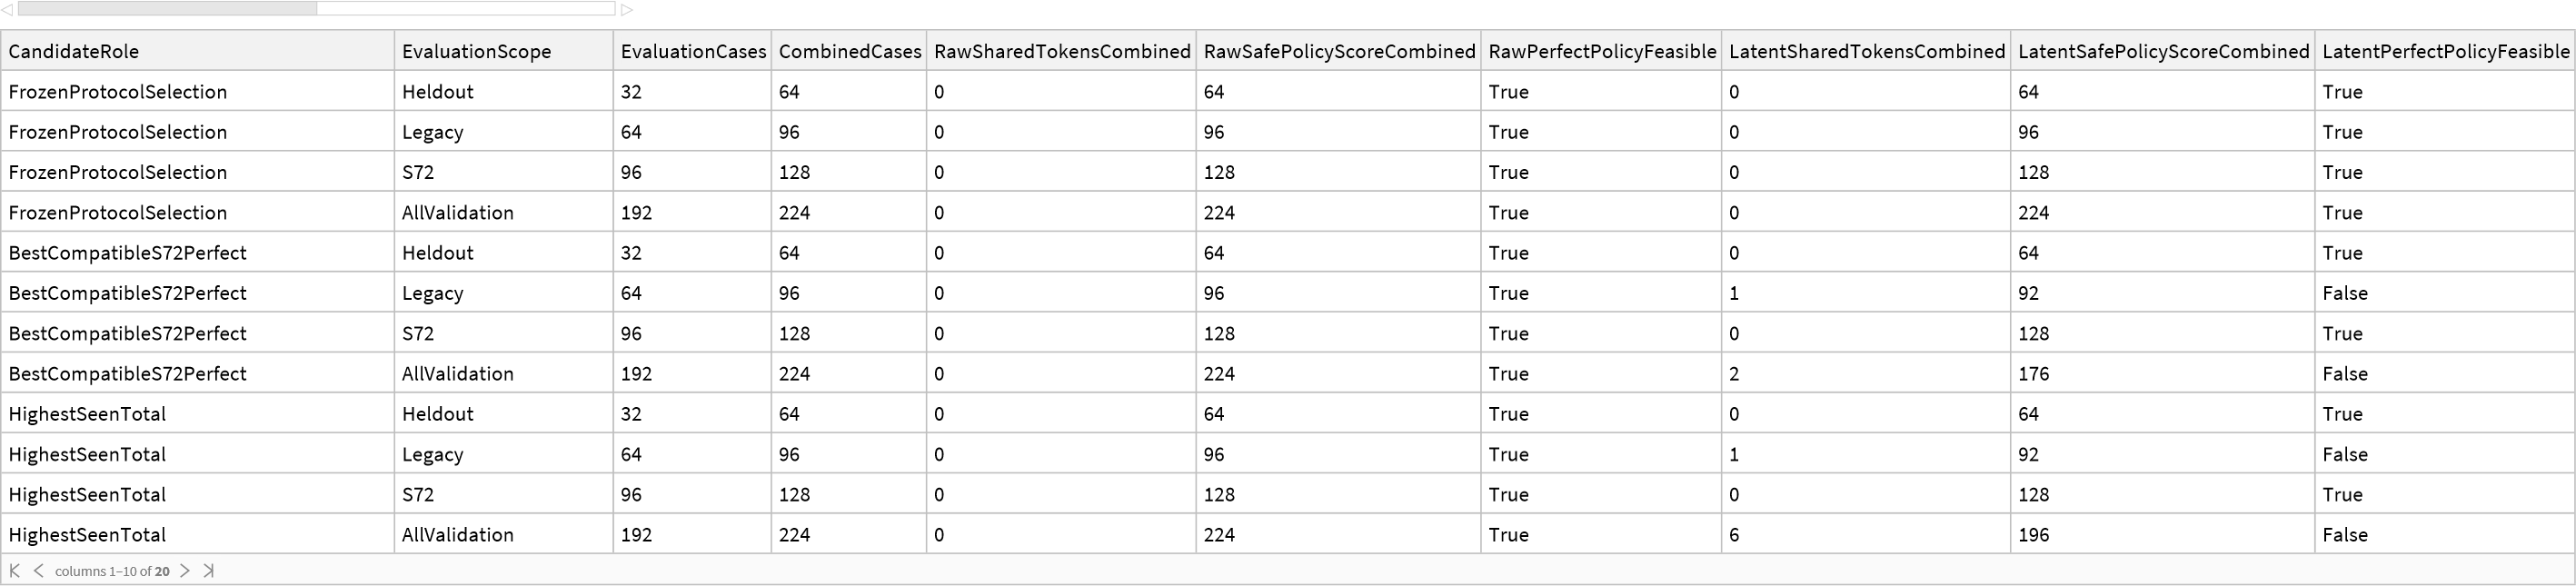
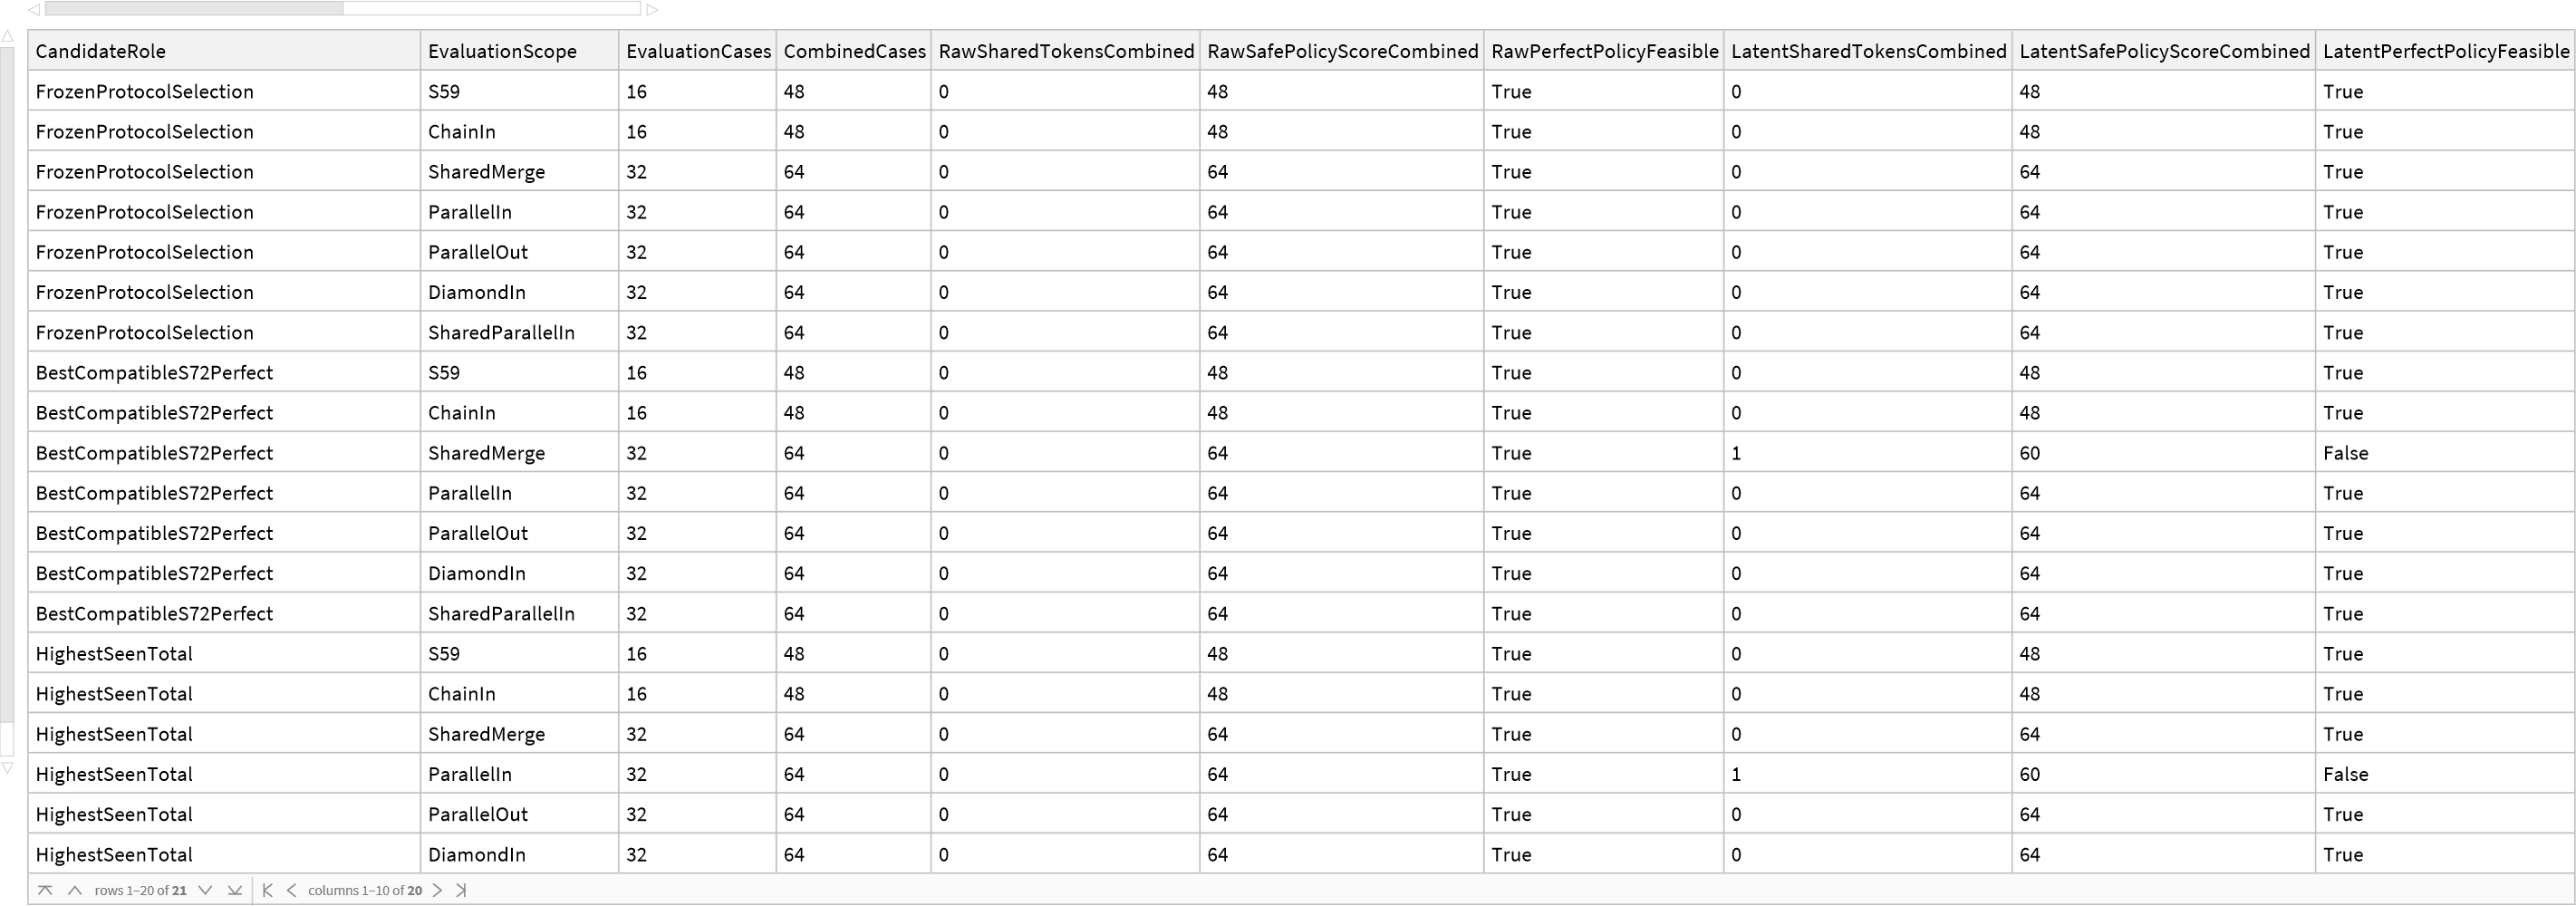

In [586]:
combinedAuditRows75B=Flatten[
Table[
KeyValueMap[
Function[{label,rows},
CombinedAudit75B[spec,label,rows]
],
evaluationGroups75B
],
{spec,representativeSpecs75A}
],
1
];

Dataset[combinedAuditRows75B]

grammarCrossAuditRows75B=Flatten[
Table[
Map[
Function[grammar,
CombinedAudit75B[
spec,
grammar,
evaluationRowsByGrammar75B[grammar]
]
],
grammarList75
],
{spec,representativeSpecs75A}
],
1
];

Dataset[grammarCrossAuditRows75B]

Dataset[{<|CandidateRole -> FrozenProtocolSelection, Token -> {1, 2}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Absent, S72Meaning -> Stop, 
 
>     ValidationMeaning -> Stop, AllSeenMeaning -> Stop, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Absent, ParallelIn -> Absent, 
 
>       ParallelOut -> Absent, DiamondIn -> Stop, SharedParallelIn -> Absent|>, 
 
>     IssueLabels -> {UnseenValidationStop}|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Token -> {1, 3}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Absent, S72Meaning -> Continue, 
 
>     ValidationMeaning -> Continue, AllSeenMeaning -> Continue, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Absent, ParallelIn -> Absent, 
 
>       ParallelOut -> Absent, DiamondIn -> Continue, SharedParallelIn -> Absent|>, 
 
>     IssueLabels -> {UnseenValidationContinue}|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Token -> {2, 2}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Absent, S72Meaning -> Continue, 
 
>     ValidationMeaning -> Continue, AllSeenMeaning -> Continue, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Absent, ParallelIn -> Absent, 
 
>       ParallelOut -> Continue, DiamondIn -> Absent, SharedParallelIn -> Absent|>, 
 
>     IssueLabels -> {UnseenValidationContinue}|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Token -> {2, 4}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Stop, S72Meaning -> Absent, 
 
>     ValidationMeaning -> Stop, AllSeenMeaning -> Stop, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Stop, ParallelIn -> Stop, 
 
>       ParallelOut -> Absent, DiamondIn -> Absent, SharedParallelIn -> Absent|>, 
 
>     IssueLabels -> {UnseenValidationStop}|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Token -> {3, 2}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Absent, S72Meaning -> Continue, 
 
>     ValidationMeaning -> Continue, AllSeenMeaning -> Continue, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Absent, ParallelIn -> Absent, 
 
>       ParallelOut -> Continue, DiamondIn -> Absent, SharedParallelIn -> Absent|>, 
 
>     IssueLabels -> {UnseenValidationContinue}|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Token -> {4, 1}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Absent, S72Meaning -> Stop, 
 
>     ValidationMeaning -> Stop, AllSeenMeaning -> Stop, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Absent, ParallelIn -> Absent, 
 
>       ParallelOut -> Absent, DiamondIn -> Absent, SharedParallelIn -> Stop|>, 
 
>     IssueLabels -> {UnseenValidationStop}|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Token -> {5, 2}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Absent, S72Meaning -> Stop, 
 
>     ValidationMeaning -> Stop, AllSeenMeaning -> Stop, 
 
>     GrammarMeanings -> 
 
>      <|S59 -> Absent, ChainIn -> Absent, SharedMerge -> Absent, ParallelIn -> Absent, 
 
>       ParallelOut -> Stop, DiamondIn -> Absent, SharedParallelIn -> Absent|>, 
 
>     IssueLabels -> {UnseenValidationStop}|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Token -> {1, 1}, 
 
>     SelectedByTrainingPolicy -> False, TrainingMeaning -> Absent, 
 
>     HeldoutMeaning -> Absent, LegacyMeaning -> Continue, S72Meaning -> 
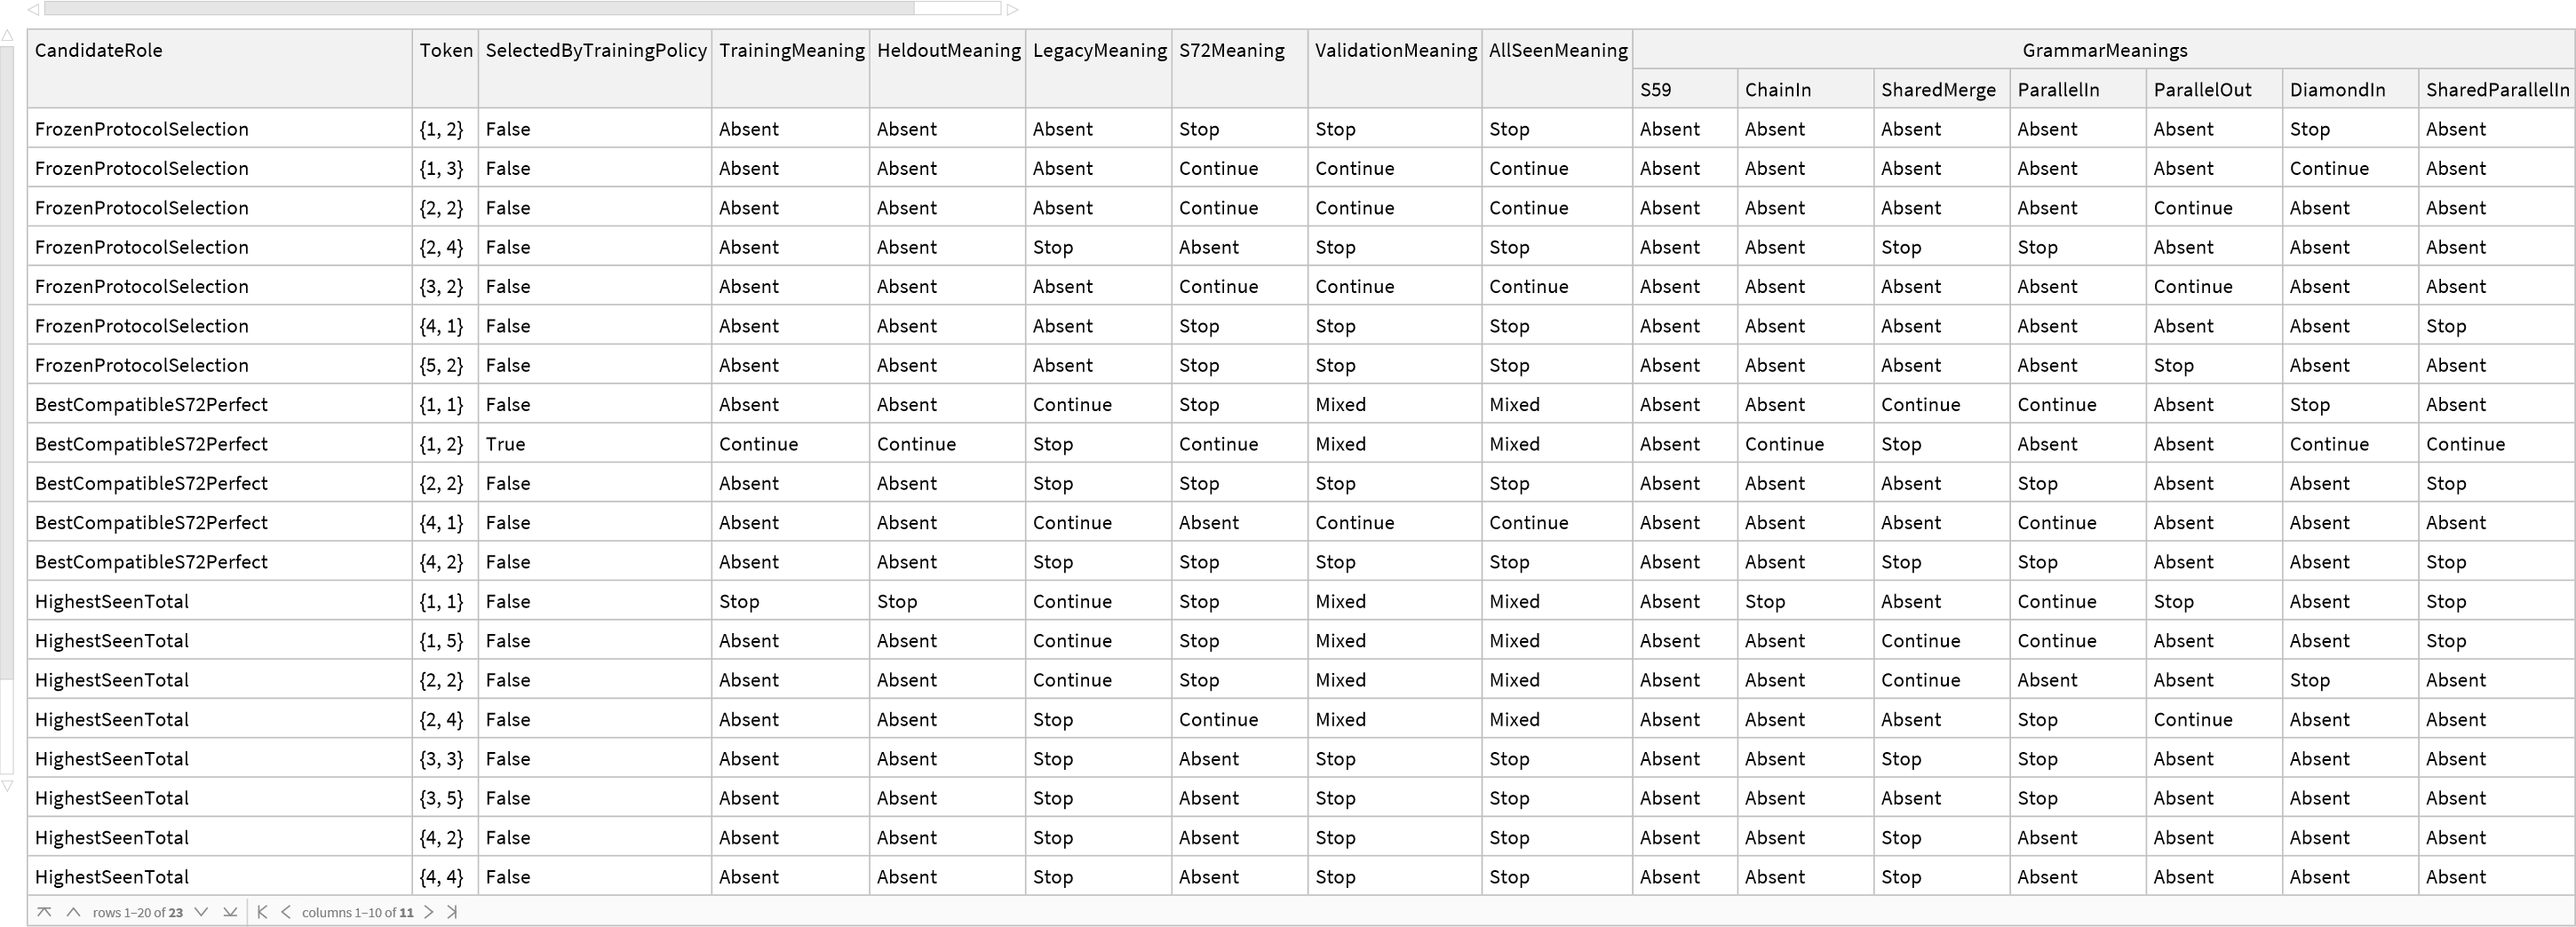

In [590]:
ClearAll[
TokenIssueLabels75B,
TokenProvenanceRows75B
];

TokenIssueLabels75B[
trainMeaning_String,
validationMeaning_String,
allSeenMeaning_String
]:=DeleteCases[
{
If[
And[
trainMeaning==="Continue",
MemberQ[{"Stop","Mixed"},validationMeaning]
],
"TrainContinueToValidationStop",
Nothing
],
If[
And[
trainMeaning==="Stop",
MemberQ[{"Continue","Mixed"},validationMeaning]
],
"TrainStopToValidationContinue",
Nothing
],
If[
And[
trainMeaning==="Absent",
MemberQ[{"Continue","Mixed"},validationMeaning]
],
"UnseenValidationContinue",
Nothing
],
If[
And[
trainMeaning==="Absent",
MemberQ[{"Stop","Mixed"},validationMeaning]
],
"UnseenValidationStop",
Nothing
],
If[
allSeenMeaning==="Mixed",
"GloballyMixedMeaning",
Nothing
]
},
Nothing
];

TokenProvenanceRows75B[
spec_Association
]:=Module[
{
candidate,trainEncoded,heldEncoded,legacyEncoded,s72Encoded,
validationEncoded,allSeenEncoded,trainSets,heldSets,legacySets,
s72Sets,validationSets,allSeenSets,grammarSets,observedTokens
},
candidate=spec["Candidate"];
trainEncoded=EncodeRows75[
trainRows75,candidate["Params"],candidate["K"]
];
heldEncoded=EncodeRows75[
heldRows75,candidate["Params"],candidate["K"]
];
legacyEncoded=EncodeRows75[
legacyValidationRows75,candidate["Params"],candidate["K"]
];
s72Encoded=EncodeRows75[
s72ValidationRows75,candidate["Params"],candidate["K"]
];
validationEncoded=Join[
heldEncoded,legacyEncoded,s72Encoded
];
allSeenEncoded=Join[
trainEncoded,validationEncoded
];
trainSets=TokenSets75B[trainEncoded];
heldSets=TokenSets75B[heldEncoded];
legacySets=TokenSets75B[legacyEncoded];
s72Sets=TokenSets75B[s72Encoded];
validationSets=TokenSets75B[validationEncoded];
allSeenSets=TokenSets75B[allSeenEncoded];
grammarSets=AssociationMap[
Function[grammar,
TokenSets75B@EncodeRows75[
fullRowsByGrammar75[grammar],
candidate["Params"],
candidate["K"]
]
],
grammarList75
];
observedTokens=allSeenSets["All"];
Map[
Function[token,
Module[
{trainMeaning,validationMeaning,allSeenMeaning},
trainMeaning=TokenMeaning75B[token,trainSets];
validationMeaning=TokenMeaning75B[token,validationSets];
allSeenMeaning=TokenMeaning75B[token,allSeenSets];
<|
"CandidateRole"->spec["CandidateRole"],
"Token"->token,
"SelectedByTrainingPolicy"->MemberQ[
candidate["Policy"],
token
],
"TrainingMeaning"->trainMeaning,
"HeldoutMeaning"->TokenMeaning75B[token,heldSets],
"LegacyMeaning"->TokenMeaning75B[token,legacySets],
"S72Meaning"->TokenMeaning75B[token,s72Sets],
"ValidationMeaning"->validationMeaning,
"AllSeenMeaning"->allSeenMeaning,
"GrammarMeanings"->AssociationMap[
TokenMeaning75B[token,grammarSets[#]]&,
grammarList75
],
"IssueLabels"->TokenIssueLabels75B[
trainMeaning,
validationMeaning,
allSeenMeaning
]
|>
]
],
observedTokens
]
];

allTokenProvenanceRows75B=Flatten[
TokenProvenanceRows75B/@representativeSpecs75A,
1
];

tokenIssueRows75B=Select[
allTokenProvenanceRows75B,
Length[# ["IssueLabels"]]>0&
];

Dataset[tokenIssueRows75B]

Dataset[{<|CandidateRole -> FrozenProtocolSelection, Ablation -> FullPair, 
 
>     PolicyLength -> 3, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 64, S72Score -> 64, ValidationTotal -> 160, 
 
>     ProtocolEligible -> True, EligibleValidationTotal -> 160, 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> Radius2Only, 
 
>     PolicyLength -> 1, TrainScore -> 28, TrainPerfect -> False, HeldScore -> 28, 
 
>     LegacyScore -> 64, S72Score -> 72, ValidationTotal -> 164, 
 
>     ProtocolEligible -> False, EligibleValidationTotal -> Missing[TrainingNotPerfect], 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> Radius3Only, 
 
>     PolicyLength -> 2, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 64, S72Score -> 64, ValidationTotal -> 160, 
 
>     ProtocolEligible -> True, EligibleValidationTotal -> 160, 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> DegreeTermsZeroed, 
 
>     PolicyLength -> 3, TrainScore -> 28, TrainPerfect -> False, HeldScore -> 28, 
 
>     LegacyScore -> 32, S72Score -> 52, ValidationTotal -> 112, 
 
>     ProtocolEligible -> False, EligibleValidationTotal -> Missing[TrainingNotPerfect], 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> FrozenProtocolSelection, Ablation -> DegreeTermsOnly, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, ValidationTotal -> 96, 
 
>     ProtocolEligible -> False, EligibleValidationTotal -> Missing[TrainingNotPerfect], 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> FullPair, 
 
>     PolicyLength -> 4, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 28, S72Score -> 96, ValidationTotal -> 156, 
 
>     ProtocolEligible -> True, EligibleValidationTotal -> 156, 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> Radius2Only, 
 
>     PolicyLength -> 2, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 44, S72Score -> 80, ValidationTotal -> 156, 
 
>     ProtocolEligible -> True, EligibleValidationTotal -> 156, 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> Radius3Only, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, ValidationTotal -> 96, 
 
>     ProtocolEligible -> False, EligibleValidationTotal -> Missing[TrainingNotPerfect], 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> DegreeTermsZeroed, 
 
>     PolicyLength -> 4, TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, 
 
>     LegacyScore -> 32, S72Score -> 32, ValidationTotal -> 96, 
 
>     ProtocolEligible -> True, EligibleValidationTotal -> 96, 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> BestCompatibleS72Perfect, Ablation -> DegreeTermsOnly, 
 
>     PolicyLength -> 0, TrainScore -> 16, TrainPerfect -> False, HeldScore -> 16, 
 
>     LegacyScore -> 32, S72Score -> 48, ValidationTotal -> 96, 
 
>     ProtocolEligible -> False, EligibleValidationTotal -> Missing[TrainingNotPerfect], 
 
>     AblationScope -> LocalFixedParameterDiagnostic|>, 
 
>    <|CandidateRole -> HighestSeenTotal, Ablation -> FullPair, PolicyLength -> 4, 
 
>     TrainScore -> 32, TrainPerfect -> True, HeldScore -> 32, LegacyScore -> 40, 
 
>     S72Score -> 92, ValidationTotal -> 164, ProtocolEligible -> True, 
 
>     EligibleValidationTotal -> 164, Ablation
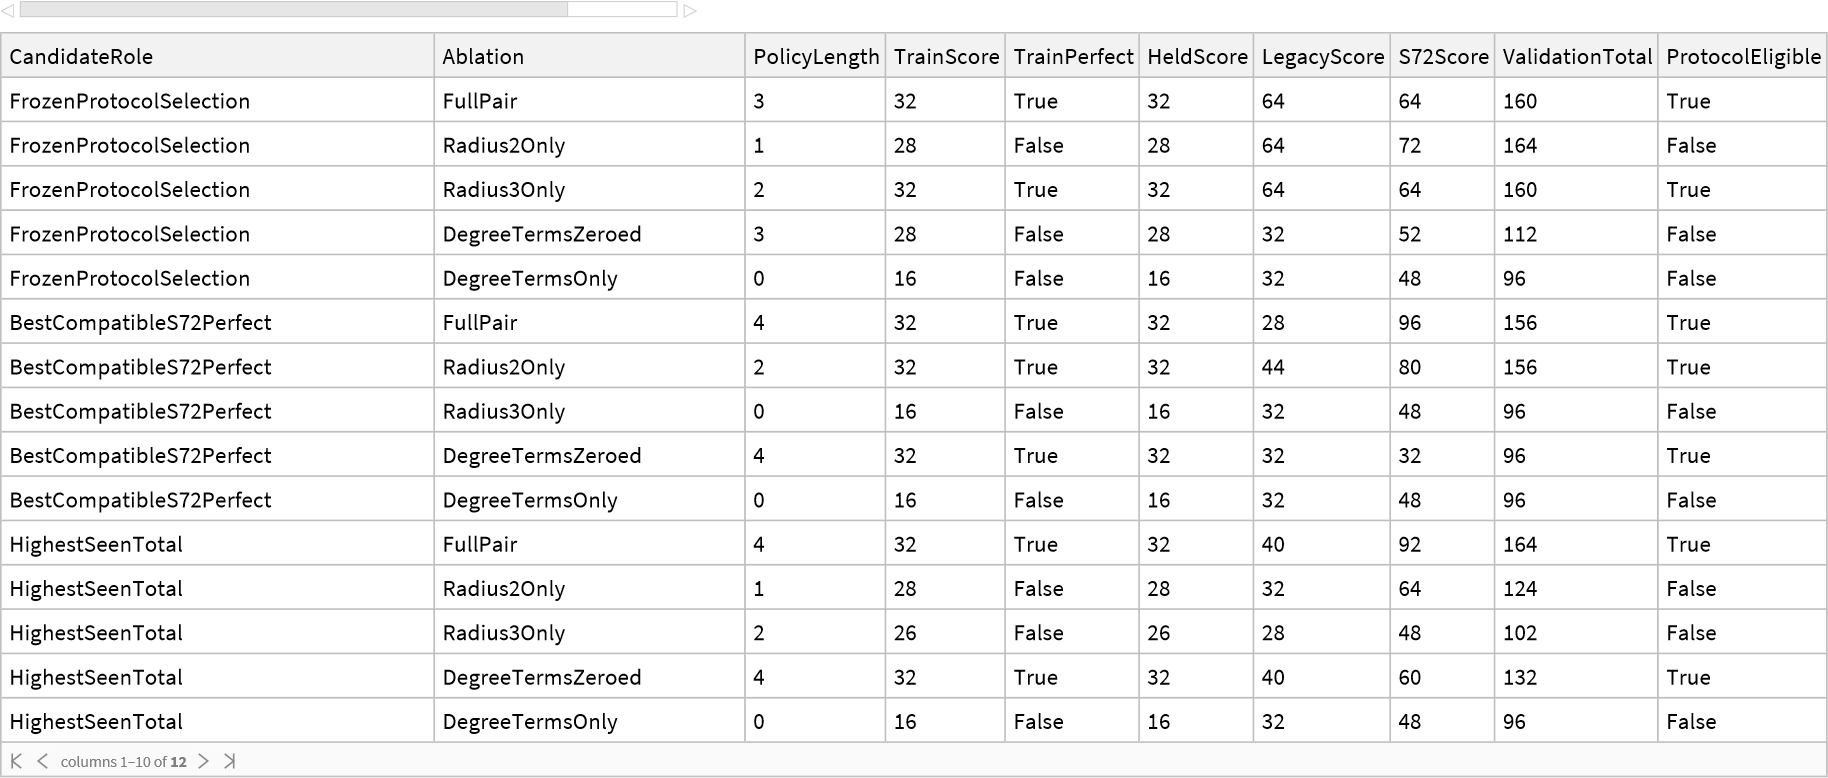
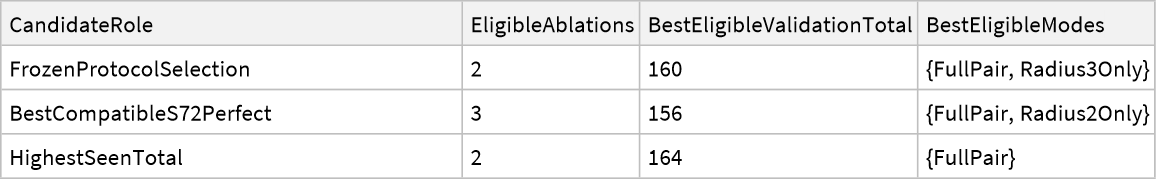

In [596]:
correctedAblationRows75B=Map[
Function[row,
Join[
KeyDrop[row,{"SeenTotal"}],
<|
"ValidationTotal"->row["SeenTotal"],
"ProtocolEligible"->TrueQ[row["TrainPerfect"]],
"EligibleValidationTotal"->If[
TrueQ[row["TrainPerfect"]],
row["SeenTotal"],
Missing["TrainingNotPerfect"]
],
"AblationScope"->"LocalFixedParameterDiagnostic"
|>
]
],
ablationRows75A
];

Dataset[correctedAblationRows75B]

eligibleAblationSummary75B=Map[
Function[role,
Module[{eligible,bestScore,bestRows},
eligible=Select[
correctedAblationRows75B,
And[
# ["CandidateRole"]===role,
TrueQ[# ["ProtocolEligible"]]
]&
];
bestScore=If[
Length[eligible]>0,
Max[Lookup[eligible,"EligibleValidationTotal"]],
Missing["NoEligibleAblation"]
];
bestRows=If[
MissingQ[bestScore],
{},
Select[
eligible,
# ["EligibleValidationTotal"]===bestScore&
]
];
<|
"CandidateRole"->role,
"EligibleAblations"->Length[eligible],
"BestEligibleValidationTotal"->bestScore,
"BestEligibleModes"->Lookup[bestRows,"Ablation"]
|>
]
],
Lookup[representativeSpecs75A,"CandidateRole"]
];

Dataset[eligibleAblationSummary75B]

Dataset[{<|Stage -> S75B, Name -> CrossTopologySemanticAudit, AuditOnly -> True, 
 
>     CoreTCCTChanged -> False, OriginalFrozenModelChanged -> False, 
 
>     S75SelectionChanged -> False, S75AResultChanged -> False, 
 
>     S75AResultLockPassed -> True, PreflightPassed -> True, 
 
>     S75AProtocolHash -> 
 
>      eeed82845625ea4f0a533ca5850eb3b236df58835dbb670ebcb973b7a0b311af, 
 
>     S75BProtocolHash -> 
 
>      eb3bc37f8c9ee9fb2932f2fc2c9f66301866c9f367cbb49fb4397c1dbf42e9bd, 
 
>     DataCertificate -> 
 
>      <|TrainingCases -> 32, HeldoutCases -> 32, LegacyCases -> 64, S72Cases -> 96, 
 
>       ValidationCases -> 192, AllSeenCases -> 224, 
 
>       CasesByGrammar -> 
 
>        <|S59 -> 32, ChainIn -> 32, SharedMerge -> 32, ParallelIn -> 32, 
 
>         ParallelOut -> 32, DiamondIn -> 32, SharedParallelIn -> 32|>, 
 
>       TargetsByScope -> 
 
>        <|Training -> <|Continue -> 16, Stop -> 16|>, 
 
>         Heldout -> <|Continue -> 16, Stop -> 16|>, 
 
>         Legacy -> <|Continue -> 32, Stop -> 32|>, 
 
>         S72 -> <|Continue -> 48, Stop -> 48|>, 
 
>         AllValidation -> <|Continue -> 96, Stop -> 96|>, 
 
>         AllSeen -> <|Continue -> 112, Stop -> 112|>|>|>, 
 
>     GlobalCrossTopologySummary -> 
 
>      {<|CandidateRole -> FrozenProtocolSelection, RawPerfectPolicyFeasible -> True, 
 
>        LatentPerfectPolicyFeasible -> True, RawSafePolicyScoreCombined -> 224, 
 
>        LatentSafePolicyScoreCombined -> 224, TrainingPolicyScoreCombined -> 192, 
 
>        TrainContinueToEvaluationStopTokens -> 0, 
 
>        TrainStopToEvaluationContinueTokens -> 0, 
 
>        EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>        UnseenEvaluationContinueTokens -> 3, UnseenEvaluationStopTokens -> 4, 
 
>        MissedContinueCases -> 32, TriggeredStopCases -> 0, 
 
>        RootCause -> TrainingCoverageGap|>, 
 
>       <|CandidateRole -> BestCompatibleS72Perfect, RawPerfectPolicyFeasible -> True, 
 
>        LatentPerfectPolicyFeasible -> False, RawSafePolicyScoreCombined -> 224, 
 
>        LatentSafePolicyScoreCombined -> 176, TrainingPolicyScoreCombined -> 188, 
 
>        TrainContinueToEvaluationStopTokens -> 1, 
 
>        TrainStopToEvaluationContinueTokens -> 0, 
 
>        EvaluationContinueTokensBlockedByTrainStop -> 0, 
 
>        UnseenEvaluationContinueTokens -> 2, UnseenEvaluationStopTokens -> 3, 
 
>        MissedContinueCases -> 24, TriggeredStopCases -> 12, 
 
>        RootCause -> LatentCrossTopologySemanticConflict|>, 
 
>       <|CandidateRole -> HighestSeenTotal, RawPerfectPolicyFeasible -> True, 
 
>        LatentPerfectPolicyFeasible -> False, RawSafePolicyScoreCombined -> 224, 
 
>        LatentSafePolicyScoreCombined -> 196, TrainingPolicyScoreCombined -> 196, 
 
>        TrainContinueToEvaluationStopTokens -> 0, 
 
>        TrainStopToEvaluationContinueTokens -> 1, 
 
>        EvaluationContinueTokensBlockedByTrainStop -> 1, 
 
>        UnseenEvaluationContinueTokens -> 5, UnseenEvaluationStopTokens -> 10, 
 
>        MissedContinueCases -> 28, TriggeredStopCases -> 0, 
 
>        RootCause -> LatentCrossTopologySemanticConflict|>}, 
 
>     TokenIssueCountsByRole -> 
 
>      {<|CandidateRole -> FrozenProtocolSelection, 
 
>        IssueCounts -> <|UnseenValidationStop -> 4, UnseenValidationContinue -> 3|>|>, 
 
>       <|CandidateRole -> BestCompatibleS72Perfect, 
 
>        IssueCounts -> 
 
>         <|UnseenValidationContinue -> 2, UnseenValidationStop -> 3, 
 
>          GloballyMixedMeaning -> 2, TrainContinueToValidationStop -> 1|>|>, 
 
>       <|CandidateRole -> HighestSeenTotal, 
 
>        IssueCounts -> 
 
>         <|TrainStopToValidationContinue -> 1, GloballyMixedMeaning -> 6, 
 
>          UnseenValidationContinue -> 5, UnseenValidationStop -> 10|>|>}, 
 
>     AblationComparisonCorrected -> True, 
 
>     AblationsAreLocalFixedParameterDiagnostics -> True, 
 
>     NewCandidateSearchIntroduced -> False, S76BlindTestRun -> False|>}, 
 
>   Typ
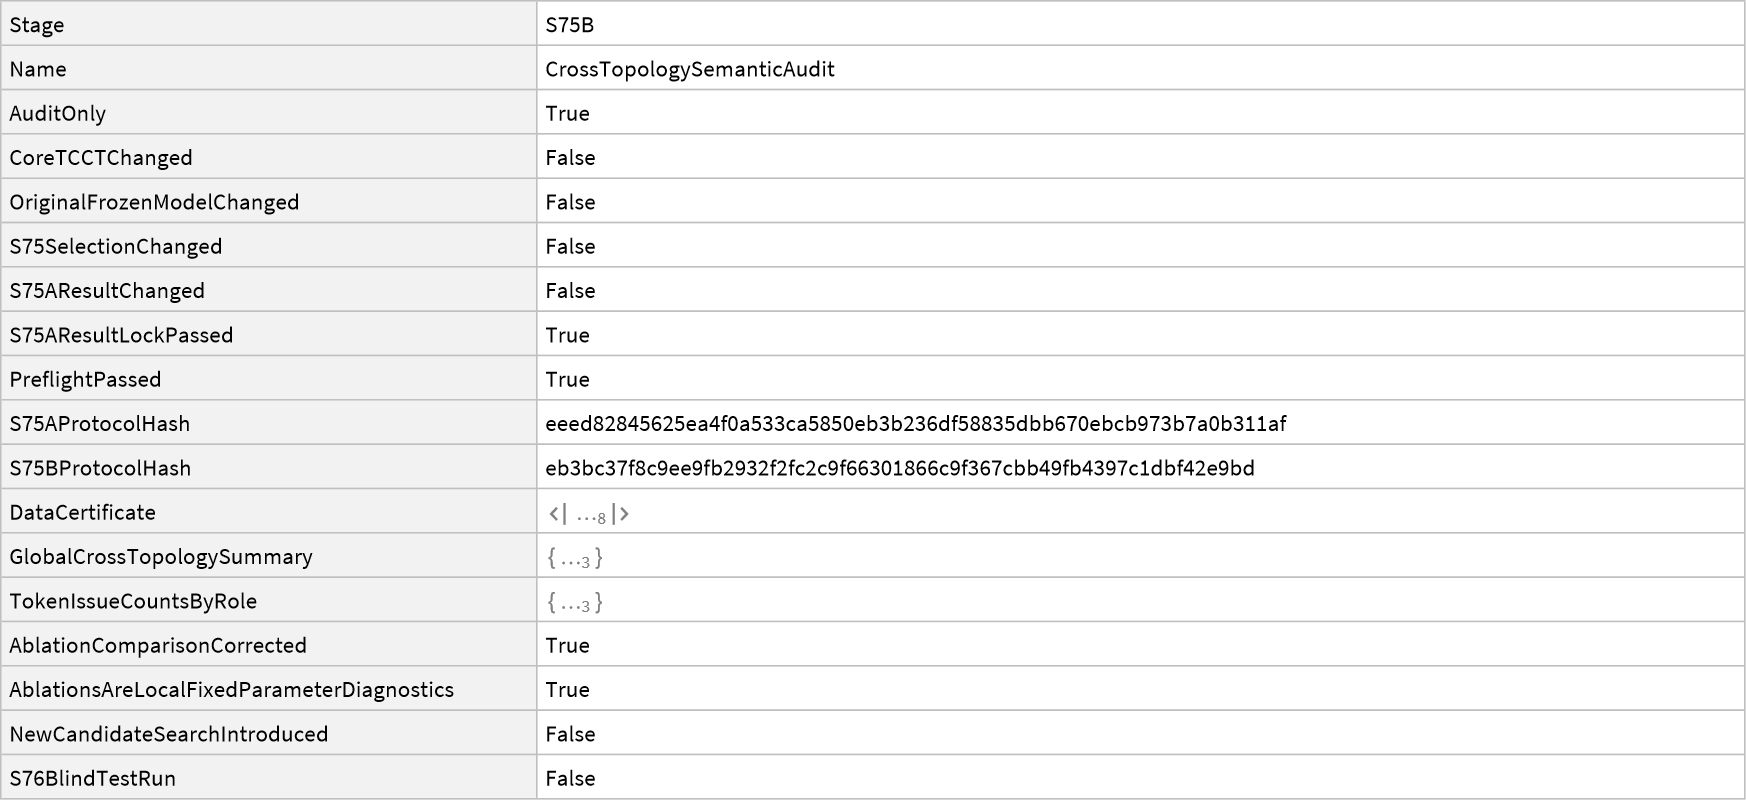

In [600]:
globalAuditRows75B=Select[
combinedAuditRows75B,
# ["EvaluationScope"]==="AllValidation"&
];

tokenIssueCountsByRole75B=Map[
Function[role,
<|
"CandidateRole"->role,
"IssueCounts"->Counts@Flatten@Lookup[
Select[
tokenIssueRows75B,
# ["CandidateRole"]===role&
],
"IssueLabels"
]
|>
],
Lookup[representativeSpecs75A,"CandidateRole"]
];

globalCrossTopologySummary75B=Map[
KeyTake[
#,
{
"CandidateRole",
"RawPerfectPolicyFeasible",
"LatentPerfectPolicyFeasible",
"RawSafePolicyScoreCombined",
"LatentSafePolicyScoreCombined",
"TrainingPolicyScoreCombined",
"TrainContinueToEvaluationStopTokens",
"TrainStopToEvaluationContinueTokens",
"EvaluationContinueTokensBlockedByTrainStop",
"UnseenEvaluationContinueTokens",
"UnseenEvaluationStopTokens",
"MissedContinueCases",
"TriggeredStopCases",
"RootCause"
}
]&,
globalAuditRows75B
];

cert75B=<|
"Stage"->"S75B",
"Name"->"CrossTopologySemanticAudit",
"AuditOnly"->True,
"CoreTCCTChanged"->False,
"OriginalFrozenModelChanged"->False,
"S75SelectionChanged"->False,
"S75AResultChanged"->False,
"S75AResultLockPassed"->s75AResultLock75B,
"PreflightPassed"->preflightPass75B,
"S75AProtocolHash"->protocolHash75A,
"S75BProtocolHash"->protocolHash75B,
"DataCertificate"->dataCert75B,
"GlobalCrossTopologySummary"->globalCrossTopologySummary75B,
"TokenIssueCountsByRole"->tokenIssueCountsByRole75B,
"AblationComparisonCorrected"->True,
"AblationsAreLocalFixedParameterDiagnostics"->True,
"NewCandidateSearchIntroduced"->False,
"S76BlindTestRun"->False
|>;

Dataset[{cert75B}]